# 🛒 온라인 채널 제품 판매량 예측 (PyTorch LSTM)
https://dacon.io/competitions/official/236129/data

> **모델 전략:** 전체 제품을 하나의 글로벌 LSTM으로 학습 (Global Time-Series Model)  
> **입력:** 과거 28일 시퀀스 → **출력:** 미래 21일 판매량 (Direct Multi-Step)

───────────────────────────────────────────────

## 📌 프로젝트 목적
과거의 제품 판매량, 브랜드 검색량(Keyword) 등의 시계열 데이터를 활용하여 향후 21일간의 제품별 판매량을 예측하는 딥러닝 모델 구축

> **예측 대상:** 약 15,890개 제품의 **미래 21일** 일별 판매 수량  
> **학습 데이터:** 2022-01-01 ~ 2023-04-04 (459일치)  
> **예측 기간:** 2023-04-05 ~ 2023-04-25 (21일) (DACON)

> **Train:  2022-01-01 ~ 2023-03-14  (438일, 학습)**   
> **Val:    2023-03-15 ~ 2023-04-04  (21일, 튜닝·조기종료)**   
> **제출(진짜 test):   2023-04-05 ~ 2023-04-25  (21일)**

───────────────────────────────────────────────

## 📋 전체 목차

| STEP | 내용 |
|------|------|
| **STEP 1** | 환경 설정 및 데이터 로드 |
| **STEP 2** | 탐색적 데이터 분석 (EDA) + 시각화 |
| **STEP 3** | 데이터 전처리 |
| **STEP 4** | 특성 공학 |
| **STEP 5** | 모델링 및 성능 비교
| **STEP 6** | 제출 파일 생성

---
## STEP 1 — 환경 설정 및 데이터 로드

In [1]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

Fri Mar 13 16:36:15 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.288.01             Driver Version: 560.94       CUDA Version: 12.6     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce GTX 1660 ...    On  | 00000000:29:00.0  On |                  N/A |
| 27%   34C    P8              20W / 125W |   1108MiB /  6144MiB |     11%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
import os
import sys
import gc
import warnings
import subprocess
import platform
from pathlib import Path

# ── 0. 파이토치 메모리 최적화 ───────────────────────────────────────────
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128,garbage_collection_threshold:0.6'

# ── 1. 라이브러리 자동 설치 및 임포트 ───────────────────────────────────
print("⏳ 필수 라이브러리 확인 중...")
REQUIRED_PKGS = ["holidays", "statsmodels"]
for pkg in REQUIRED_PKGS:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

print('✅ 라이브러리 준비 완료')

# ── 2. 한글 폰트 및 시각화 설정 ────────────────────────────────────────
from korean_font import set_korean_font
set_korean_font()

warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'jpeg'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 3. 시드 고정 — 누가 돌려도 같은 결과 ────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'🎲 시드 고정: {SEED}')

# ── 4. 경로 설정 ────────────────────────────────────────────────────────
HOME       = os.getcwd()
DATA_DIR   = os.path.join(HOME, 'data')
OUTPUT_DIR = os.path.join(HOME, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'📁 HOME: {HOME}')
print(f'📁 DATA: {DATA_DIR}')
print(f'📁 OUT : {OUTPUT_DIR}')

# ── 5. GPU 설정 (초기화는 데이터 로드 후로 지연) ────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🎯 DEVICE = {DEVICE}  (GPU 초기화는 데이터 로드 후에 함)')

⏳ 필수 라이브러리 확인 중...
✅ 라이브러리 준비 완료
한글 폰트 설정: NanumGothic (/home/bluelemon77/.local/share/fonts/NanumGothic.ttf)
🎲 시드 고정: 42
📁 HOME: /home/bluelemon77/project/Team
📁 DATA: /home/bluelemon77/project/Team/data
📁 OUT : /home/bluelemon77/project/Team/output
🎯 DEVICE = cuda  (GPU 초기화는 데이터 로드 후에 함)


In [3]:
# ── 6. 데이터 로드 및 칼럼(변수) 분리 ───────────────────────────────────
# 데이터를 불러오고, '정보(Meta)'와 '시계열 수치(Date)'를 미리 분리해 둡니다.
train      = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
sales      = pd.read_csv(os.path.join(DATA_DIR, 'sales.csv'))
product    = pd.read_csv(os.path.join(DATA_DIR, 'product_info.csv'))
keyword    = pd.read_csv(os.path.join(DATA_DIR, 'brand_keyword_cnt.csv'))
submission = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

# 나중에 데이터 다루기 편하도록 이름표(리스트) 미리 묶어두기
META_COLS  = ['ID', '제품', '대분류', '중분류', '소분류', '브랜드']
DATE_COLS  = [c for c in train.columns if c not in META_COLS]
KW_COLS    = [c for c in keyword.columns if c != '브랜드']
PRED_DATES = [c for c in submission.columns if c != 'ID']

print('=' * 55)
print(f'📊 train.csv   : {train.shape[0]:,}행 × {train.shape[1]}열')
print(f'📊 sales.csv   : {sales.shape[0]:,}행 × {sales.shape[1]}열')
print(f'📊 product.csv : {product.shape[0]:,}행 × {product.shape[1]}열')
print(f'📊 keyword.csv : {keyword.shape[0]:,}행 × {keyword.shape[1]}열')
print('=' * 55)
print(f'📅 학습 기간   : {DATE_COLS[0]}  ~  {DATE_COLS[-1]}  ({len(DATE_COLS)}일)')
print(f'🎯 예측 기간   : {PRED_DATES[0]}  ~  {PRED_DATES[-1]}  ({len(PRED_DATES)}일)')
print('=' * 55)

# ── 7. 데이터 메모리 다이어트 (Downcasting) ─────────────────────────────
# 64비트(큰 방)에 들어있는 데이터를 32비트(작은 방)로 옮겨서 RAM 용량을 확보합니다.
before_mb = sum(d.memory_usage(deep=True).sum() for d in [train, sales, keyword]) / 1024**2

for data in [train, sales, keyword, submission]:
    for col in data.columns:
        # 정수형 다이어트
        if data[col].dtype == 'int64':
            data[col] = data[col].astype('int32')
        # 실수형 다이어트
        elif data[col].dtype == 'float64':
            data[col] = data[col].astype('float32')

after_mb = sum(d.memory_usage(deep=True).sum() for d in [train, sales, keyword]) / 1024**2
print(f'💾 메모리 최적화: {before_mb:.1f}MB → {after_mb:.1f}MB ({(1-after_mb/before_mb)*100:.0f}% 절감)')

# 메모리 다이어트 과정에서 생긴 쓸데없는 찌꺼기(가비지) 청소!
gc.collect()

# 데이터가 잘 들어왔는지 메타 정보와 첫 3일치 데이터만 살짝 확인
train[META_COLS + DATE_COLS[:3]].head(3)

📊 train.csv   : 15,890행 × 465열
📊 sales.csv   : 15,890행 × 465열
📊 product.csv : 12,778행 × 2열
📊 keyword.csv : 3,170행 × 460열
📅 학습 기간   : 2022-01-01  ~  2023-04-04  (459일)
🎯 예측 기간   : 2023-04-05  ~  2023-04-25  (21일)
💾 메모리 최적화: 133.5MB → 72.2MB (46% 절감)


,ID,제품,대분류,중분류,소분류,브랜드,2022-01-01,2022-01-02,2022-01-03
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,0,0,0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0


In [4]:
# ── 8. GPU 최종 점검 및 초기화 ──────────────────────────────────────────
# 데이터를 다 불러오고 메모리 다이어트까지 끝낸 지금! 드디어 GPU 상태를 확인합니다.
# 본격적인 모델링에 들어가기 전에, GPU 캐시(임시 저장소)를 싹 비워 쾌적하게 만듭니다.
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
    props    = torch.cuda.get_device_properties(0)
    total_gb = props.total_memory / 1024**3
    print(f'✅ {props.name}  |  총 {total_gb:.1f}GB')
else:
    print('⚠️ CPU 모드')

✅ NVIDIA GeForce GTX 1660 SUPER  |  총 6.0GB


---
## STEP 2 — 탐색적 데이터 분석 (EDA) + 시각화

EDA의 목적은 단순히 데이터를 '보는' 것이 아닙니다.  
**"이 데이터를 어떻게 전처리하고, 어떤 피처를 만들 것인가"** 를 결정하기 위한 근거를 쌓는 과정입니다.

| # | 질문 | 전처리 영향 |
|---|------|-----------|
| 2-1 | 기본 통계: 제품 수, 카테고리 구조? | 임베딩 차원 설계 |
| 2-2 | 판매량 분포: 어떻게 퍼져 있나? | Log 변환 필요 여부 |
| 2-3 | 일별 트렌드: 이상 구간이 있나? | 급락 구간 처리 방법 결정 |
| 2-4 | 요일·월별 패턴: 특정 날에 더 많이 파나? | 날짜 피처 설계 |
| 2-5 | Spike(이상치): 극단값이 있나? | 클리핑 처리 여부 |
| 2-6 | 0의 종류: 모든 0이 같은 의미인가? | 구조적 0 제거 여부 |
| 2-7 | 브랜드 검색량: 판매 예측에 도움이 되나? | 검색량 피처 채택 여부 |
| 2-8~11 | 시계열 심화: ACF/PACF, CCF, STL, ADF | Lag 피처 설계, 차분 여부 |
| 2-12~13 | 시즌성 히트맵, 공휴일 | 이벤트 피처 설계 |

### 🔧 함수 선언 — `short_label()`

카테고리 코드(`B002-C001-0002`)는 길어서 그래프 x축이 겹칩니다.  
마지막 숫자만 추출해 `대2`, `중11`, `소38`처럼 짧게 만드는 함수입니다.  
이 함수는 **2-1 카테고리 시각화부터 2-12 히트맵까지** 공통으로 사용됩니다.

In [5]:
# ── short_label() : 카테고리 코드를 짧은 레이블로 변환 ────────────────────
# 예) 'B002-C001-0002' → '대2' / 'B002-C003-0038' → '소38'
def short_label(code_str, prefix):
    """카테고리 코드 마지막 숫자만 추출해 짧은 레이블 반환"""
    number = code_str.split('-')[-1].lstrip('0') or '0'
    return f'{prefix}{number}'

# ── 전역 레이블 딕셔너리 — 이후 모든 그래프에서 공용 사용  ────────────────────
cat_labels = {}
for col, prefix in [('대분류', '대'), ('중분류', '중'), ('소분류', '소')]:
    cat_labels[col] = {
        code_str: short_label(code_str, prefix)
        for code_str in train[col].unique()
    }

# ── 변환 결과 확인 ────────────────────
for col in ['대분류', '중분류', '소분류']:
    items  = list(cat_labels[col].items())[:3]
    sample = '  /  '.join(f'{k} → {v}' for k, v in items)
    print(f'[{col}] 예시: {sample}  ... (총 {len(cat_labels[col])}개)')

[대분류] 예시: B002-C001-0002 → 대2  /  B002-C001-0003 → 대3  /  B002-C001-0001 → 대1  ... (총 5개)
[중분류] 예시: B002-C002-0007 → 중7  /  B002-C002-0008 → 중8  /  B002-C002-0001 → 중1  ... (총 11개)
[소분류] 예시: B002-C003-0038 → 소38  /  B002-C003-0044 → 소44  /  B002-C003-0003 → 소3  ... (총 53개)


### 2-1. 기본 통계 + 카테고리 구조 시각화

In [6]:
# ── 기본 통계 수치 출력 ────────────────────────────────────────────────────
print('=' * 55)
print('📌 제품 카테고리 구조')
print('=' * 55)
print(f"  전체 제품(행) 수  : {train['제품'].nunique():>6,}개")
print(f"  브랜드 수         : {train['브랜드'].nunique():>6,}개")
print(f"  대분류 수         : {train['대분류'].nunique():>6}개")
print(f"  중분류 수         : {train['중분류'].nunique():>6}개")
print(f"  소분류 수         : {train['소분류'].nunique():>6}개")

qty_all = train[DATE_COLS].values.flatten()

print()
print('=' * 55)
print('📊 판매량(qty) 전체 통계')
print('=' * 55)
print(f'  전체 데이터 셀 수        : {len(qty_all):>12,}개')
print(f'  판매량 = 0인 셀 (비율)   : {(qty_all==0).sum():>12,}개 ({(qty_all==0).mean():.1%})')
print(f'  판매량 > 0인 셀 (비율)   : {(qty_all>0).sum():>12,}개 ({(qty_all>0).mean():.1%})')
print(f'  전체 중앙값              : {np.median(qty_all):>12.1f}')
print(f'  판매>0인 날 평균         : {qty_all[qty_all>0].mean():>12.1f}')
print(f'  판매>0인 날 중앙값       : {np.median(qty_all[qty_all>0]):>12.1f}')
print(f'  최대값                   : {qty_all.max():>12,}')

📌 제품 카테고리 구조
  전체 제품(행) 수  : 15,840개
  브랜드 수         :  3,170개
  대분류 수         :      5개
  중분류 수         :     11개
  소분류 수         :     53개

📊 판매량(qty) 전체 통계
  전체 데이터 셀 수        :    7,293,510개
  판매량 = 0인 셀 (비율)   :    4,652,860개 (63.8%)
  판매량 > 0인 셀 (비율)   :    2,640,650개 (36.2%)
  전체 중앙값              :          0.0
  판매>0인 날 평균         :         48.8
  판매>0인 날 중앙값       :          7.0
  최대값                   :      200,420


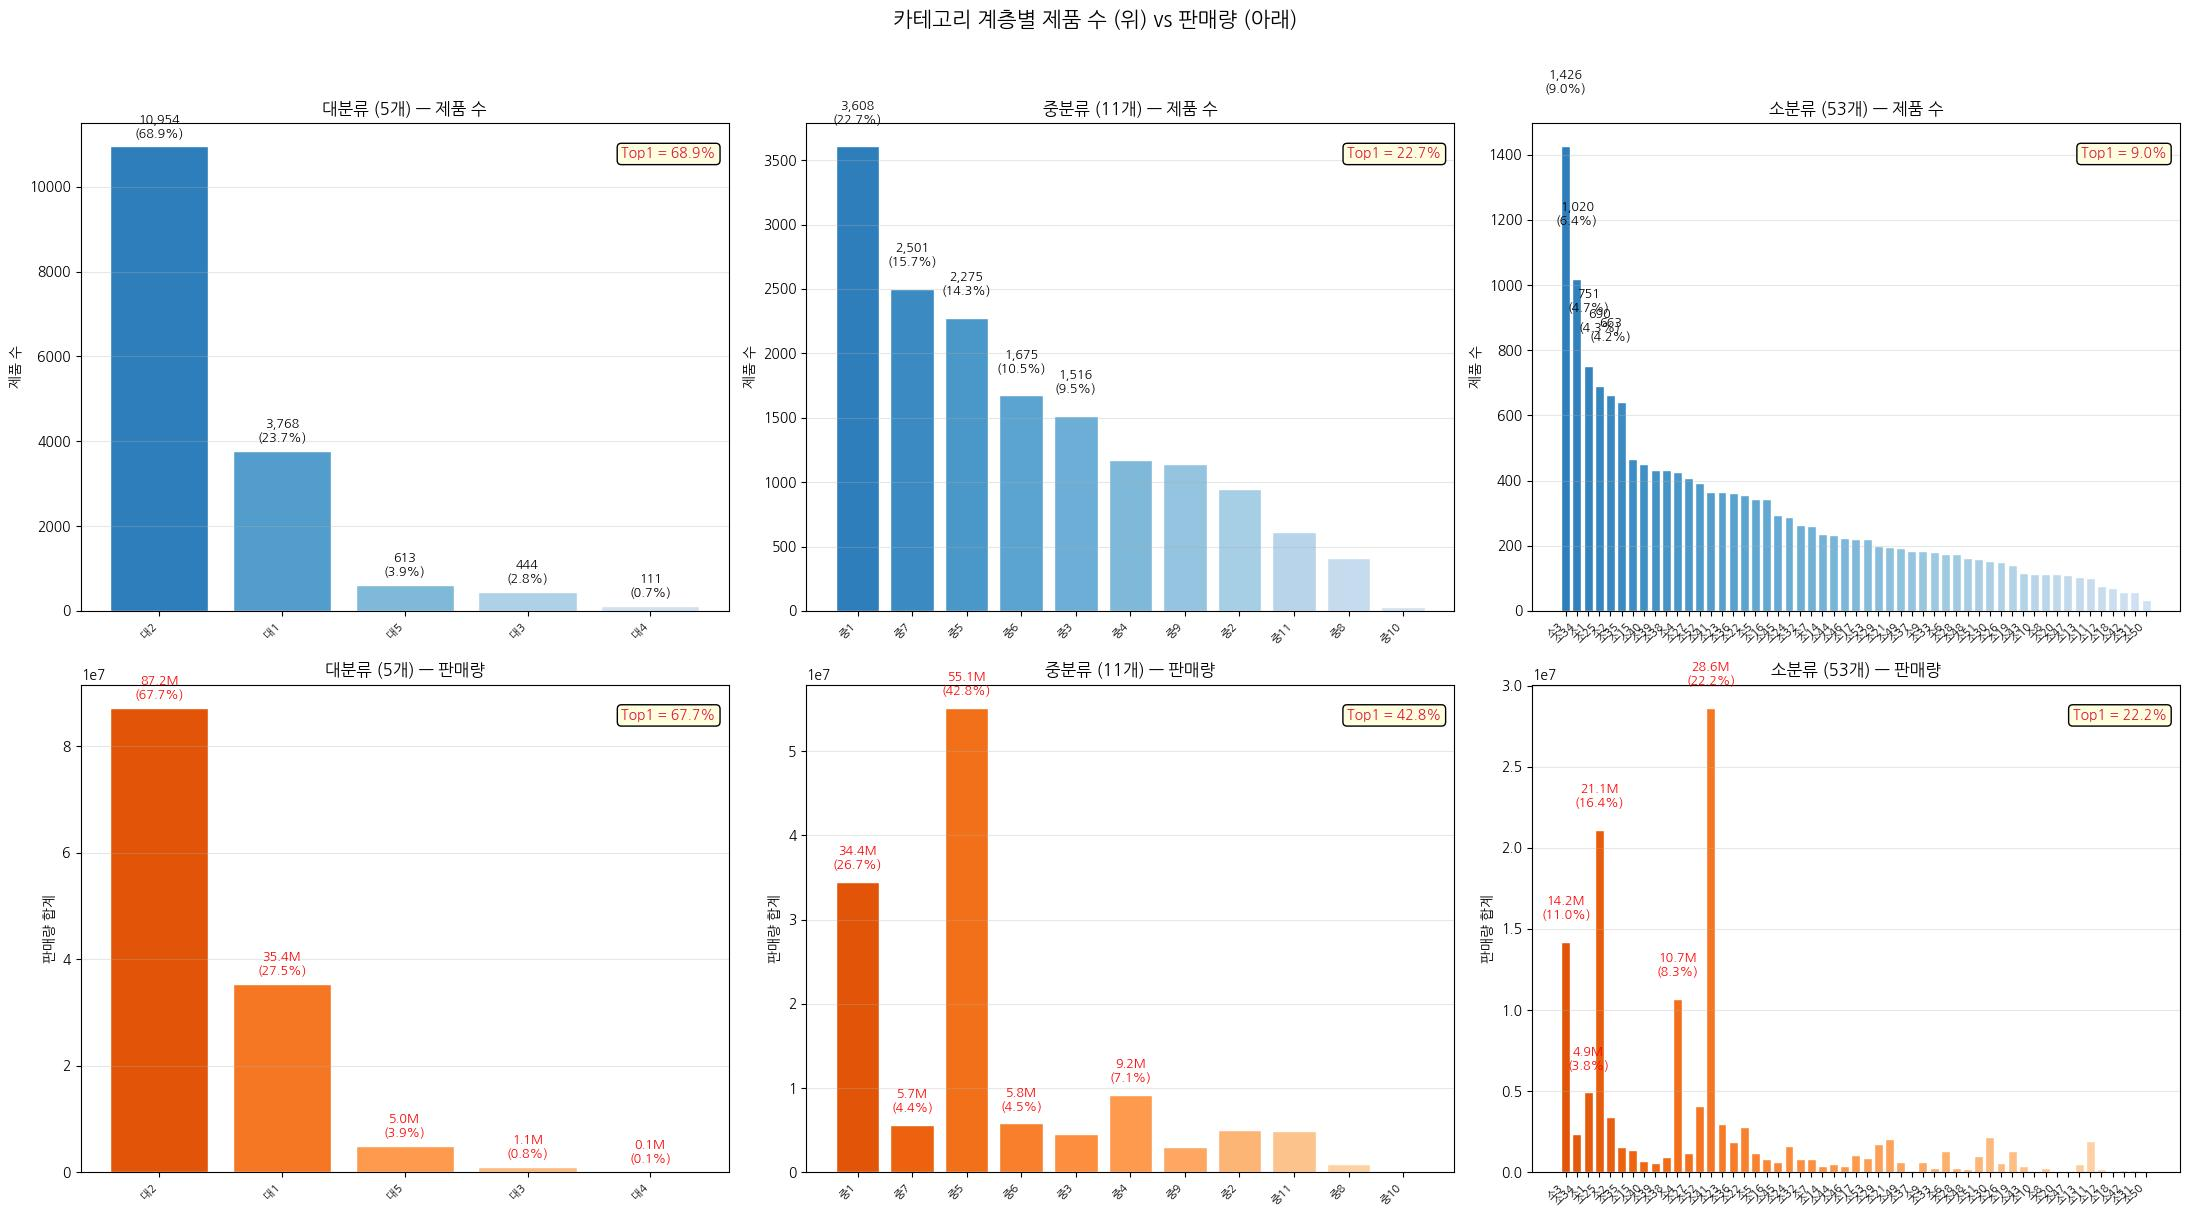

📌 카테고리별 제품 수 vs 판매량 비율 비교 — 상위 5개

[대분류]
      제품수  제품수비율(%)       판매량  판매비율(%)
대2  10954      68.9  87218401     67.7
대1   3768      23.7  35441662     27.5
대5    613       3.9   4961560      3.9
대3    444       2.8   1078827      0.8
대4    111       0.7     85411      0.1

[중분류]
     제품수  제품수비율(%)       판매량  판매비율(%)
중5  2275      14.3  55131807     42.8
중1  3608      22.7  34420592     26.7
중4  1168       7.4   9203982      7.1
중6  1675      10.5   5798762      4.5
중7  2501      15.7   5671077      4.4

[소분류]
      제품수  제품수비율(%)       판매량  판매비율(%)
소41   366       2.3  28636033     22.2
소25   690       4.3  21097753     16.4
소3   1426       9.0  14227803     11.0
소4    426       2.7  10673098      8.3
소1    751       4.7   4923380      3.8


In [7]:
# ── 카테고리별 제품 수(위) vs 판매량(아래) 2×3 시각화 ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('카테고리 계층별 제품 수 (위) vs 판매량 (아래)',
             fontsize=15, fontweight='bold', y=1.01)

cats = ['대분류', '중분류', '소분류']

for col_idx, col in enumerate(cats):
    ax_top    = axes[0][col_idx]
    ax_bottom = axes[1][col_idx]

    product_cnt   = train[col].value_counts().sort_values(ascending=False)
    sales_by_cat  = train.groupby(col)[DATE_COLS].sum().sum(axis=1).reindex(product_cnt.index)
    n             = len(product_cnt)
    total_product = product_cnt.sum()
    total_sales   = sales_by_cat.sum()
    xlabels       = [cat_labels[col].get(name, name) for name in product_cnt.index]

    # ── 위: 제품 수 ────────────────────────────────────────────────────────
    colors_top = plt.cm.Blues_r([0.3 + 0.5 * i / max(n - 1, 1) for i in range(n)])
    bars_top   = ax_top.bar(range(n), product_cnt.values, color=colors_top, edgecolor='white')
    
    for j, (bar, val) in enumerate(zip(bars_top, product_cnt.values)):
        if j < 5:  # 상위 5개까지만 텍스트 표시
            # 💡 [핵심 변경 포인트] 비율 계산 후 줄바꿈(\n)으로 추가
            pct = (val / total_product) * 100
            ax_top.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + total_product * 0.01,
                        f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
            
    top1_pct = product_cnt.values[0] / total_product * 100
    ax_top.text(0.98, 0.95, f'Top1 = {top1_pct:.1f}%',
                transform=ax_top.transAxes, ha='right', va='top', fontsize=10,
                color='crimson', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))
    ax_top.set_title(f'{col} ({n}개) — 제품 수', fontsize=12, fontweight='bold')
    ax_top.set_ylabel('제품 수')
    ax_top.set_xticks(range(n))
    ax_top.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax_top.grid(alpha=0.3, axis='y')
    
    # ── 아래: 판매량 ────────────────────────────────────────────────────────
    colors_bot = plt.cm.Oranges_r([0.3 + 0.5 * i / max(n - 1, 1) for i in range(n)])
    bars_bot   = ax_bottom.bar(range(n), sales_by_cat.values, color=colors_bot, edgecolor='white')
    
    # 💡 [핵심 변경 포인트 1] 판매량 기준으로 진짜 Top 5인 카테고리를 미리 뽑아둠!
    top5_sales_cats = sales_by_cat.sort_values(ascending=False).head(5).index

    for j, (bar, val) in enumerate(zip(bars_bot, sales_by_cat.values)):
        current_cat = sales_by_cat.index[j] # 지금 순서를 돌고 있는 막대의 카테고리 이름
        
        # 무조건 왼쪽 5개가 아니라, 현재 카테고리가 '판매량 Top 5' 안에 속할 때만 %를 달아라!
        if current_cat in top5_sales_cats: 
            pct = (val / total_sales) * 100
            ax_bottom.text(bar.get_x() + bar.get_width()/2,
                           bar.get_height() + total_sales * 0.01,
                           f'{val/1e6:.1f}M\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9,
                           color='red', fontweight='bold') # 👈 눈에 확 띄게 빨간색 굵은 글씨로 포인트!
                           
    # 💡 [핵심 변경 포인트 2] 무조건 0번 자리가 아니라, .max()를 써서 진짜 판매량 1등을 찾는다!
    real_top1_sales = sales_by_cat.max()
    top1_sales_pct = (real_top1_sales / total_sales) * 100
    
    ax_bottom.text(0.98, 0.95, f'Top1 = {top1_sales_pct:.1f}%',
                   transform=ax_bottom.transAxes, ha='right', va='top', fontsize=10,
                   color='crimson', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))
    ax_bottom.set_title(f'{col} ({n}개) — 판매량', fontsize=12, fontweight='bold')
    ax_bottom.set_ylabel('판매량 합계')
    ax_bottom.set_xticks(range(n))
    ax_bottom.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax_bottom.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── 수치 요약 ──────────────────────────────────────────────────────────────
print('=' * 60)
print('📌 카테고리별 제품 수 vs 판매량 비율 비교 — 상위 5개')
print('=' * 60)
for col in cats:
    print(f'\n[{col}]')
    product_cnt  = train[col].value_counts()
    sales_by_cat = train.groupby(col)[DATE_COLS].sum().sum(axis=1)
    summary = pd.DataFrame({
        '제품수'        : product_cnt,
        '제품수비율(%)' : (product_cnt / product_cnt.sum() * 100).round(1),
        '판매량'        : sales_by_cat,
        '판매비율(%)'   : (sales_by_cat / sales_by_cat.sum() * 100).round(1),
    }).sort_values('판매량', ascending=False).head(5)
    summary.index = [cat_labels[col].get(i, i) for i in summary.index]
    print(summary.to_string())

💬 2-1 해석 — 카테고리 불균형이 모델 설계에 미치는 영향

| 카테고리 | 제품수 비율 | 판매 비율 | 해석 |
|---------|-----------|---------|------|
| 대분류 대2 | ~69% | ~68% | 두 비율 유사 → 카테고리 간 불균형 적음 |
| 중분류 상위 | 낮음 | 높음 | 제품은 적은데 판매 압도적 → 핵심 카테고리 |
| 소분류 상위 | 매우 낮음 | 높음 | 소수 스타 카테고리 존재 |

**→ 모델링 활용:** 카테고리별 판매 편차가 크므로 임베딩 레이어로 카테고리 정보를 강하게 반영해야 함

### 2-2. 판매량 분포 — Long Tail + 로렌츠 곡선

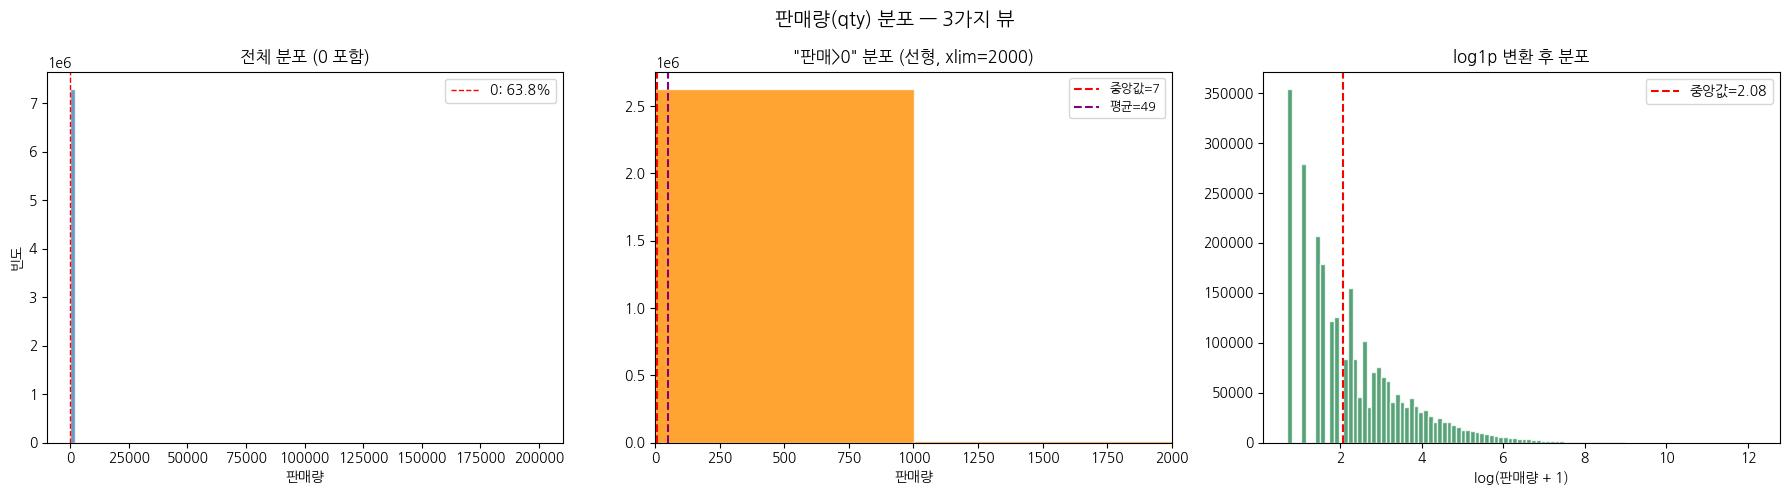


💡 스케일 압축: 원본 0~200,420 → log 변환 후 0~12.2
   압축 비율: 16417배 축소


In [8]:
# ── 판매량 분포 3가지 뷰 ──────────────────────────────────────────────────
# 뷰1: 전체 분포(0 포함) / 뷰2: 판매>0만 (선형) / 뷰3: log1p 변환 후
# → 세 뷰를 나란히 보면 "왜 log 변환이 필요한지" 눈으로 이해됨
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('판매량(qty) 분포 — 3가지 뷰', fontsize=14, fontweight='bold')

qty_nonzero = qty_all[qty_all > 0]

ax = axes[0]
ax.hist(qty_all, bins=100, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('전체 분포 (0 포함)')
ax.set_xlabel('판매량'); ax.set_ylabel('빈도')
ax.axvline(0, color='red', ls='--', lw=1, label=f'0: {(qty_all==0).mean():.1%}')
ax.legend()

ax = axes[1]
ax.hist(qty_nonzero, bins=200, color='darkorange', alpha=0.8, edgecolor='white')
ax.set_xlim(0, 2000)
ax.set_title('"판매>0" 분포 (선형, xlim=2000)')
ax.set_xlabel('판매량')
ax.axvline(np.median(qty_nonzero), color='red',    ls='--', lw=1.5,
           label=f'중앙값={np.median(qty_nonzero):.0f}')
ax.axvline(qty_nonzero.mean(),    color='purple', ls='--', lw=1.5,
           label=f'평균={qty_nonzero.mean():.0f}')
ax.legend(fontsize=9)

ax = axes[2]
qty_log = np.log1p(qty_nonzero)
ax.hist(qty_log, bins=100, color='seagreen', alpha=0.8, edgecolor='white')
ax.set_title('log1p 변환 후 분포')
ax.set_xlabel('log(판매량 + 1)')
ax.axvline(np.median(qty_log), color='red', ls='--', lw=1.5,
           label=f'중앙값={np.median(qty_log):.2f}')
ax.legend()

plt.tight_layout()
plt.show()
print(f'\n💡 스케일 압축: 원본 0~{qty_all.max():,} → log 변환 후 0~{np.log1p(qty_all.max()):.1f}')
print(f'   압축 비율: {qty_all.max() / np.log1p(qty_all.max()):.0f}배 축소')

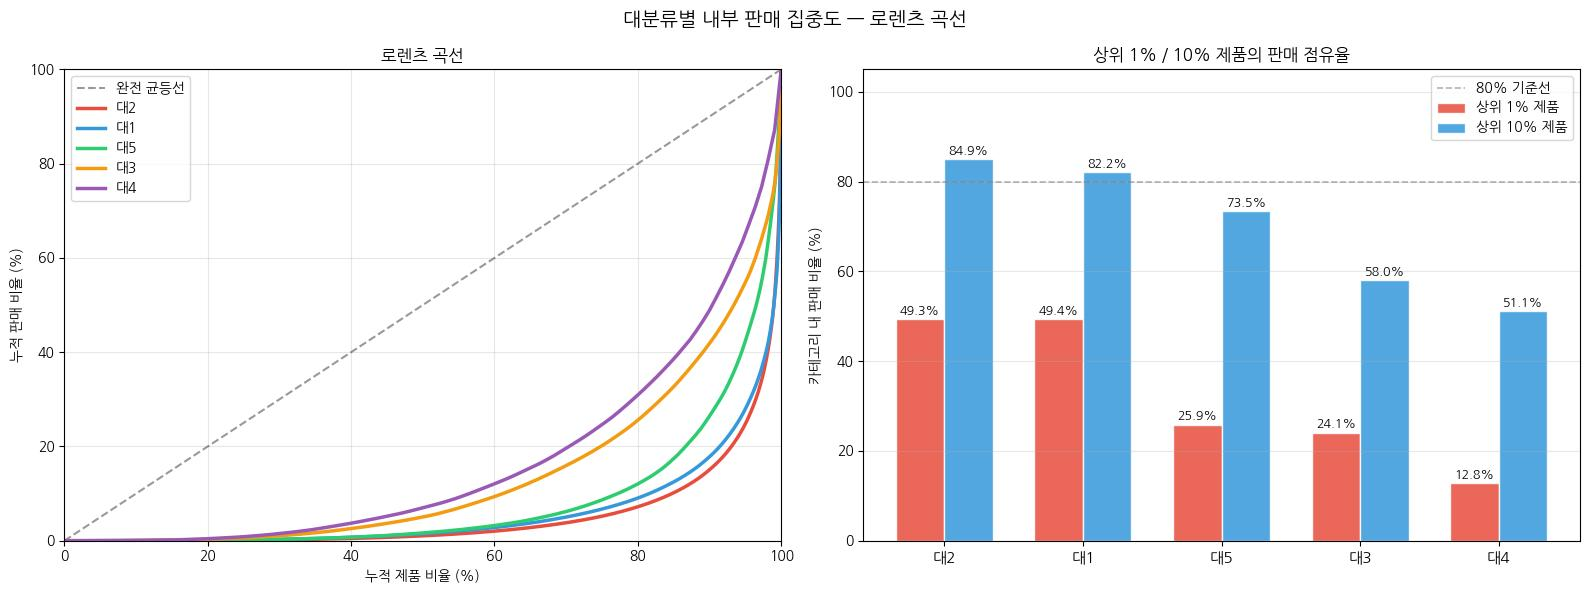

In [9]:
# ── 로렌츠 곡선 — 카테고리 내부도 Long Tail인지 확인 ─────────────────────
# X축=누적 제품 비율, Y축=누적 판매 비율
# 대각선에 가까울수록 균등, 아래로 처질수록 소수 제품이 판매를 독식함
train['total_sales'] = train[DATE_COLS].sum(axis=1)
cats_ordered = train.groupby('대분류')['total_sales'].sum().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('대분류별 내부 판매 집중도 — 로렌츠 곡선', fontsize=14, fontweight='bold')
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

ax = axes[0]
ax.plot([0, 100], [0, 100], 'k--', lw=1.5, alpha=0.4, label='완전 균등선')
for i, cat in enumerate(cats_ordered):
    subset = train[train['대분류'] == cat]['total_sales'].sort_values(ascending=True).values
    cumsum = np.cumsum(subset) / subset.sum() * 100
    x      = np.linspace(0, 100, len(cumsum))
    label  = cat_labels['대분류'].get(cat, cat)
    ax.plot(x, cumsum, color=colors[i], linewidth=2.5, label=label)
ax.set_xlabel('누적 제품 비율 (%)')
ax.set_ylabel('누적 판매 비율 (%)')
ax.set_title('로렌츠 곡선')
ax.legend(); ax.grid(alpha=0.3)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)

ax = axes[1]
labels_list = [cat_labels['대분류'].get(c, c) for c in cats_ordered]
top1_pcts, top10_pcts = [], []
for cat in cats_ordered:
    subset = train[train['대분류'] == cat]['total_sales'].sort_values(ascending=False)
    total  = subset.sum()
    top1_pcts.append(subset.iloc[:max(1, int(len(subset)*0.01))].sum() / total * 100)
    top10_pcts.append(subset.iloc[:max(1, int(len(subset)*0.1))].sum() / total * 100)
x = np.arange(len(labels_list)); width = 0.35
bars1 = ax.bar(x - width/2, top1_pcts,  width, label='상위 1% 제품',
               color='#e74c3c', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, top10_pcts, width, label='상위 10% 제품',
               color='#3498db', alpha=0.85, edgecolor='white')
for bar, val in zip(bars1, top1_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, top10_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(80, color='gray', linestyle='--', lw=1.2, alpha=0.6, label='80% 기준선')
ax.set_xticks(x); ax.set_xticklabels(labels_list, fontsize=11)
ax.set_ylabel('카테고리 내 판매 비율 (%)')
ax.set_title('상위 1% / 10% 제품의 판매 점유율')
ax.legend(); ax.grid(alpha=0.3, axis='y'); ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()
train.drop(columns=['total_sales'], inplace=True)

💬 2-2 해석

**Long Tail 구조 확인:**
- 전체의 63.8%가 0 → 왼쪽에 거대한 뭉치
- 판매>0인 날만 봐도 소수 인기 제품이 판매를 독식 (최대 20만 개 이상)
- log1p 변환 후 종 모양에 근접 → 모든 제품이 비슷한 영향력을 가질 수 있음

| 비교 | 변환 전 | 변환 후 |
|------|--------|--------|
| 범위 | 0 ~ 200,000+ | 0 ~ 12 |
| 인기 제품 영향력 | 학습 지배 | 균등화됨 |

> **역변환:** 예측 완료 후 `np.expm1(y)`로 원래 단위(개) 복원  
> **→ STEP 3 전처리에서 log1p 변환 적용 결정**

### 2-3. 일별 판매 트렌드 — 급락 구간 포함

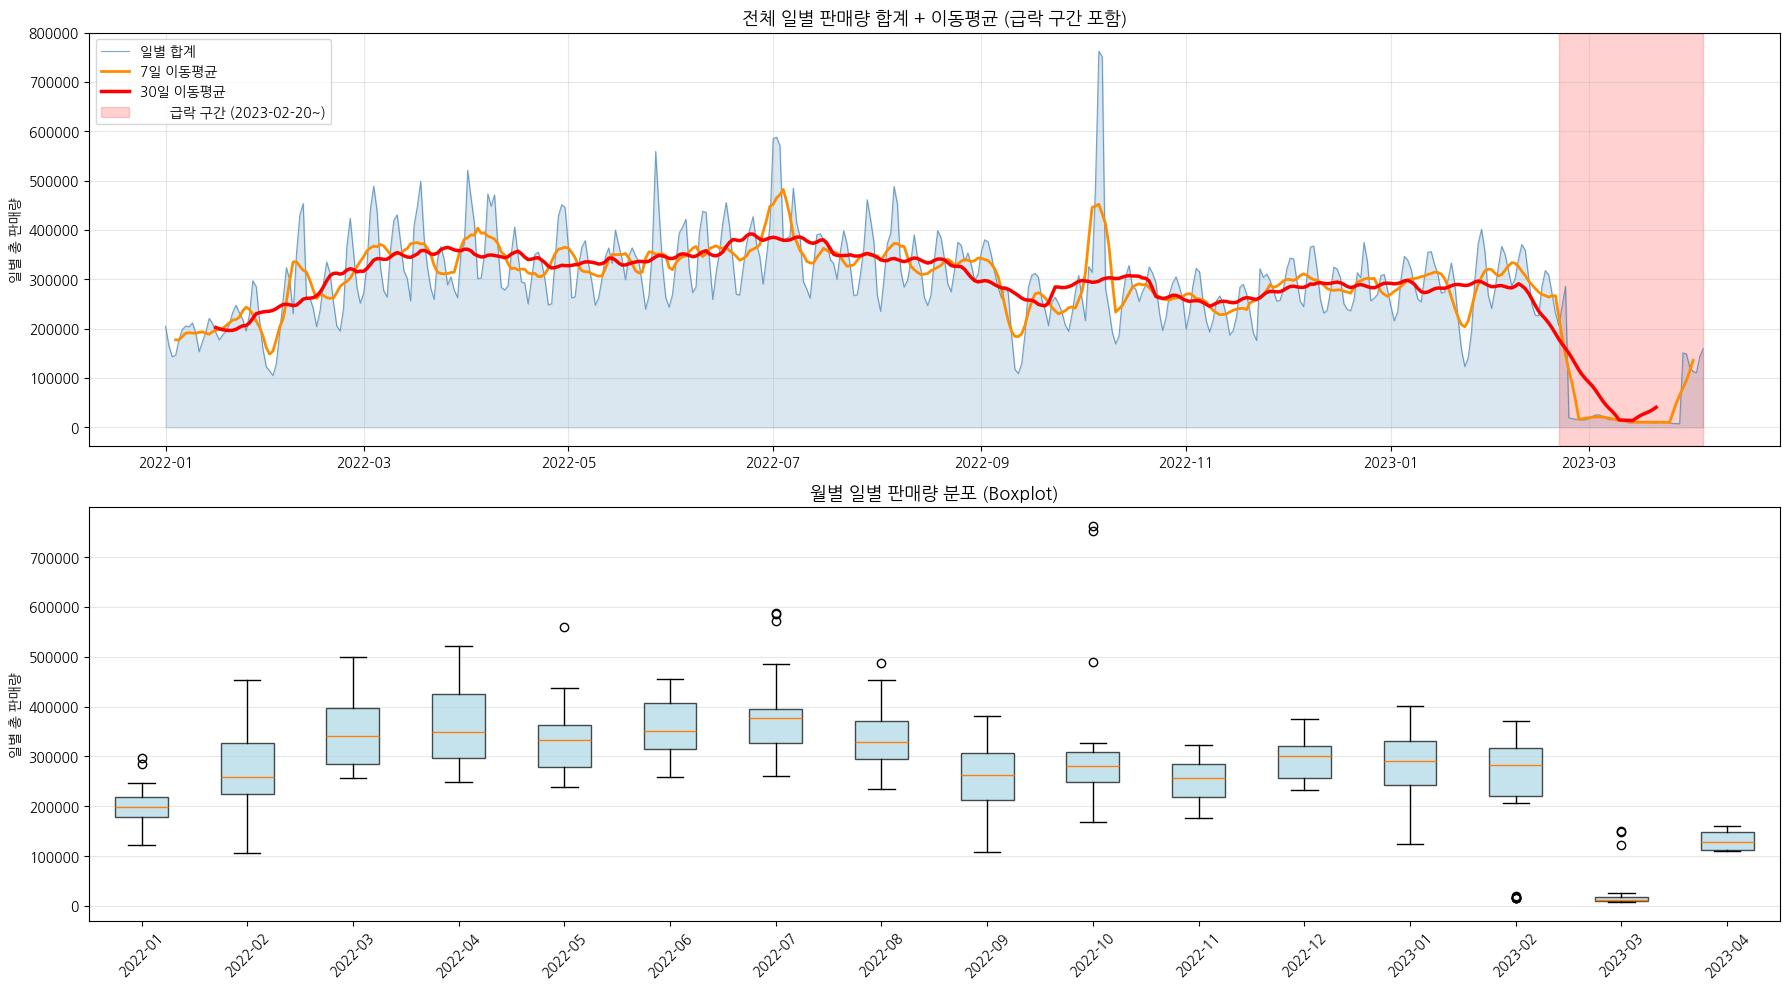


📊 급락 구간 분석
  정상 구간 일평균 : 305,103
  급락 구간 일평균 : 49,274  (16.2%)
  → STEP 3-0에서 3가지 처리 방법 중 선택


In [10]:
# ── 2-3. 일별 판매 트렌드 계산 ─────────────────────────────────────────────────
# ⚠️ daily_total, ma30, upper, lower 변수는
#    2-5 Spike 탐지와 STEP 3-0 급락 처리에서 재사용됩니다.

daily_total = train[DATE_COLS].sum(axis=0)
daily_total.index = pd.to_datetime(daily_total.index)

ma7   = daily_total.rolling(7,  center=True).mean()
ma30  = daily_total.rolling(30, center=True).mean()
std30 = daily_total.rolling(30, center=True).std()
upper = ma30 + 2 * std30
lower = ma30 - 2 * std30

# 급락 구간 정의 (2-3 시각화 + STEP 3-0에서 처리)
CRASH_START = pd.Timestamp('2023-02-20')
CRASH_END   = pd.Timestamp('2023-04-04')

# ── 트렌드 + 월별 박스플롯 시각화 ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

ax = axes[0]
ax.fill_between(daily_total.index, daily_total.values, alpha=0.2, color='steelblue')
ax.plot(daily_total.index, daily_total.values, color='steelblue', lw=0.8, alpha=0.7, label='일별 합계')
ax.plot(ma7.index,  ma7.values,  color='darkorange', lw=2,   label='7일 이동평균')
ax.plot(ma30.index, ma30.values, color='red',        lw=2.5, label='30일 이동평균')
ax.axvspan(CRASH_START, CRASH_END, alpha=0.18, color='red',
           label=f'⚠️ 급락 구간 ({CRASH_START.date()}~)')
ax.set_title('전체 일별 판매량 합계 + 이동평균 (급락 구간 포함)', fontsize=13)
ax.set_ylabel('일별 총 판매량')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

ax = axes[1]
temp = pd.DataFrame({'date': daily_total.index, 'total': daily_total.values})
temp['yearmonth'] = temp['date'].dt.strftime('%Y-%m')
month_data   = [group['total'].values for _, group in temp.groupby('yearmonth')]
month_labels = list(temp['yearmonth'].unique())
ax.boxplot(month_data, labels=month_labels, patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7))
ax.set_title('월별 일별 판매량 분포 (Boxplot)', fontsize=13)
ax.set_ylabel('일별 총 판매량')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 급락 구간 수치 확인
normal_avg = daily_total[daily_total.index < CRASH_START].mean()
crash_avg  = daily_total[daily_total.index >= CRASH_START].mean()
print(f'\n📊 급락 구간 분석')
print(f'  정상 구간 일평균 : {normal_avg:,.0f}')
print(f'  급락 구간 일평균 : {crash_avg:,.0f}  ({crash_avg/normal_avg:.1%})')
print(f'  → STEP 3-0에서 3가지 처리 방법 중 선택')

💬 2-3 해석
**2023-02-20 이후 급락:**
- 정상 구간 대비 판매량이 대폭 감소하는 구간 발견
- 데이터 수집 오류, 플랫폼 이슈, 실제 시장 변화 중 하나일 수 있음
- **STEP 3-0에서 3가지 방법으로 처리:** 제외 / 보간 / 플래그 중 선택

**계절성 패턴:**
- 10월이 연중 피크, 2월이 최저점

**→ 모델링 활용:** `rolling_7`, `rolling_30` lag 피처 추가 근거

### 2-4. 요일·월별 판매 패턴

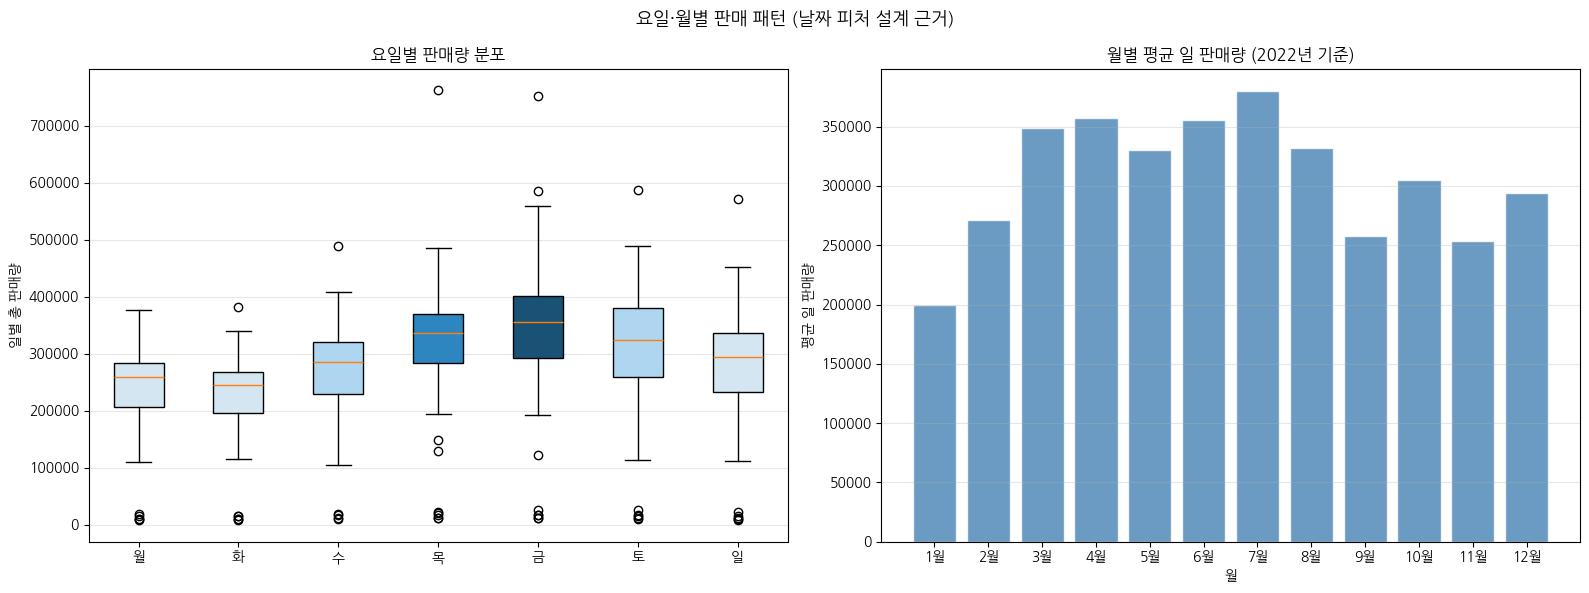

In [11]:
# ── 요일·월별 판매 패턴 시각화 ────────────────────────────────────────────
# 목적: 날짜 피처(day_of_week, month, is_weekend)를 추가할 근거 확보
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('요일·월별 판매 패턴 (날짜 피처 설계 근거)', fontsize=13, fontweight='bold')

temp = pd.DataFrame({'date': pd.to_datetime(daily_total.index), 'total': daily_total.values})
temp['day_of_week'] = temp['date'].dt.dayofweek
temp['month']       = temp['date'].dt.month
dow_labels = ['월', '화', '수', '목', '금', '토', '일']

ax = axes[0]
dow_data = [temp[temp['day_of_week'] == d]['total'].values for d in range(7)]
bp = ax.boxplot(dow_data, labels=dow_labels, patch_artist=True)
colors_dow = ['#d4e6f1','#d4e6f1','#aed6f1','#2e86c1','#1a5276','#aed6f1','#d4e6f1']
for patch, c in zip(bp['boxes'], colors_dow):
    patch.set_facecolor(c)
ax.set_title('요일별 판매량 분포')
ax.set_ylabel('일별 총 판매량')
ax.grid(alpha=0.3, axis='y')

ax = axes[1]
temp_2022   = temp[temp['date'].dt.year == 2022]
monthly_avg = temp_2022.groupby('month')['total'].mean()
month_kor   = ['1월','2월','3월','4월','5월','6월','7월','8월','9월','10월','11월','12월']
ax.bar(monthly_avg.index, monthly_avg.values, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('월별 평균 일 판매량 (2022년 기준)')
ax.set_xlabel('월'); ax.set_ylabel('평균 일 판매량')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_kor)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

💬 2-4 해석

**요일 패턴:** 
월·화요일이 가장 낮고, 목·금요일이 가장 높음. 주말은 중간 수준  
- **→ `day_of_week` 피처 추가** (이분법 `is_weekend`만으로는 목·금 피크를 담지 못함)

**월별 패턴:** 
3~7월 봄·여름 구간이 높고, 9월 이후가 상대적으로 낮음

- **→ `month`, `quarter` 피처 추가**


### 2-5. Spike(이상치) 탐지 — MA30 ± 2σ 기준

감지된 Spike 날짜 수: 16일
날짜 목록 (앞 10개): ['2022-02-10', '2022-02-11', '2022-04-01', '2022-04-29', '2022-04-30', '2022-05-27', '2022-07-01', '2022-07-02', '2022-07-03', '2022-08-06']


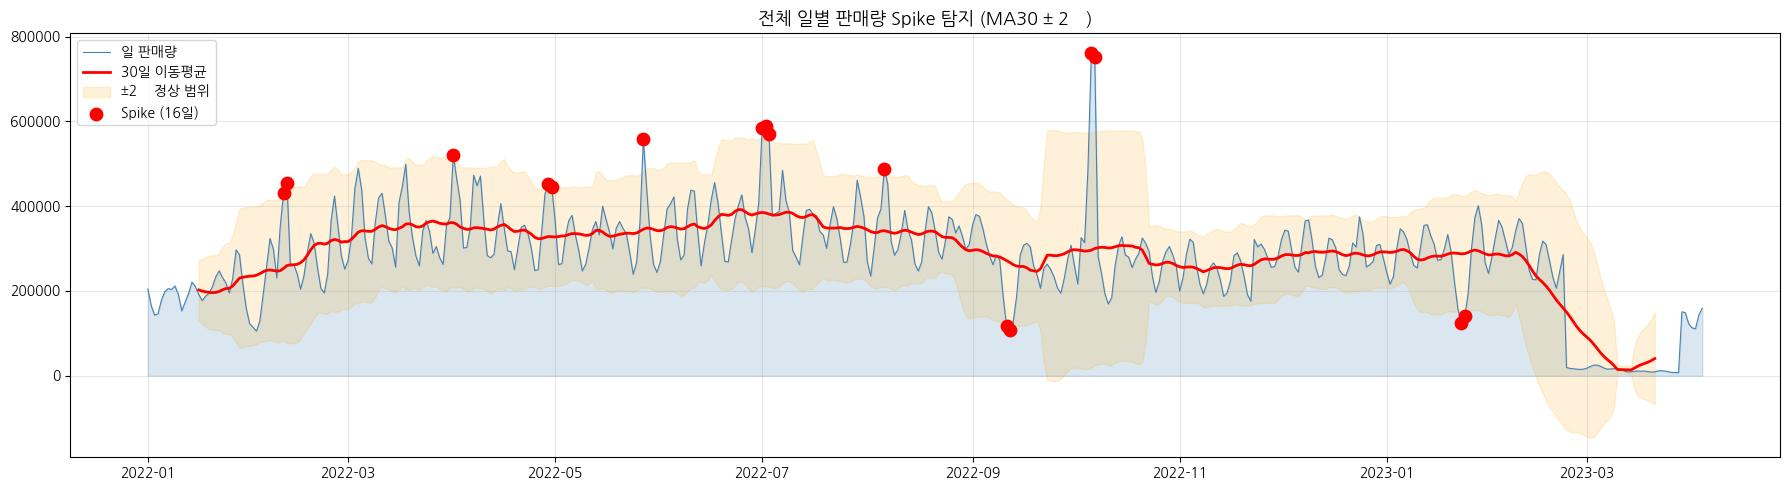

In [12]:
# ── Spike 탐지 (MA30 ± 2σ) ────────────────────────────────────────────────
# 정상 범위(MA30 ± 2σ)를 벗어나는 날 = Spike
# ⚠️ ma30, upper, lower 는 2-3에서 이미 계산됨
spike_dates = daily_total[(daily_total > upper) | (daily_total < lower)].index

print(f'감지된 Spike 날짜 수: {len(spike_dates)}일')
print(f'날짜 목록 (앞 10개): {[str(d.date()) for d in spike_dates[:10]]}')

# ── Spike 시각화 ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 5))
ax.fill_between(daily_total.index, daily_total, alpha=0.2, color='steelblue')
ax.plot(daily_total.index, daily_total, lw=0.8, color='steelblue', label='일 판매량')
ax.plot(ma30.index, ma30.values, 'r-', lw=2, label='30일 이동평균')
ax.fill_between(ma30.index, lower, upper, alpha=0.15, color='orange', label='±2σ 정상 범위')
ax.scatter(spike_dates, daily_total[spike_dates], color='red', zorder=5, s=80,
           label=f'Spike ({len(spike_dates)}일)')
ax.set_title('전체 일별 판매량 Spike 탐지 (MA30 ± 2σ)', fontsize=13)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

1. Spike 날 브랜드별 기여도 — 한 브랜드가 66% 독점이라는 것  
2. 그 브랜드의 전후 패턴 — 딱 5일만 폭증 후 즉시 정상화  

In [13]:
import re

# ── 브랜드명 단축 변환 전 겹침(충돌) 검사 (정규표현식 업그레이드) ────────────

unique_brands = train['브랜드'].astype(str).unique()
brand_labels = {}
overlap_check = {} 

for b in unique_brands:
    # 💡 [핵심 변경] 정규표현식: 문자열의 맨 끝($)에 있는 연속된 숫자(\d+)를 찾아라!
    match = re.search(r'\d+$', b)
    
    if match:
        # 끝에 숫자가 있으면, 그 숫자에서 앞의 0을 떼어냄 (00001 -> 1, 0003 -> 3)
        number = match.group().lstrip('0') or '0'
        short_name = f'브{number}'
    else:
        # 혹시라도 끝에 숫자가 아예 없는 이상한 이름이면 그냥 원본을 씀
        short_name = b 
    
    # 겹침 검사 로직
    if short_name in overlap_check:
        overlap_check[short_name].append(b)
    else:
        overlap_check[short_name] = [b]
        
    brand_labels[b] = short_name

# ── 검사 결과 출력 ──────────────────────────────────────────────────────────
overlaps = {k: v for k, v in overlap_check.items() if len(v) > 1}

print("=" * 55)
print("🔍 업그레이드된 브랜드 이름 단축 시뮬레이션 결과")
print("=" * 55)
print(f"총 고유 브랜드 수: {len(unique_brands)}개")

if overlaps:
    print(f"🚨 이름이 겹치는 브랜드가 {len(overlaps)}건 발견되었습니다!")
    for short_name, raw_names in list(overlaps.items())[:5]:
        print(f" - '{short_name}' (이)라고 불리게 될 원본들: {raw_names}")
else:
    print("✅ 짝대기(-)가 없어도 완벽하게 끝 숫자만 발라냈고, 겹침도 없습니다!")
    items = list(brand_labels.items())[:5] # 5개 뽑아서 어떻게 변했나 보자
    print(f"예시: {'  /  '.join(f'{k} → {v}' for k, v in items)}")

🔍 업그레이드된 브랜드 이름 단축 시뮬레이션 결과
총 고유 브랜드 수: 3170개
✅ 짝대기(-)가 없어도 완벽하게 끝 숫자만 발라냈고, 겹침도 없습니다!
예시: B002-00001 → 브1  /  B002-00002 → 브2  /  B002-00003 → 브3  /  B002-00005 → 브5  /  B002-00006 → 브6


가장 큰 Spike 날짜: 2022-10-06  (전체 판매량: 762,097)


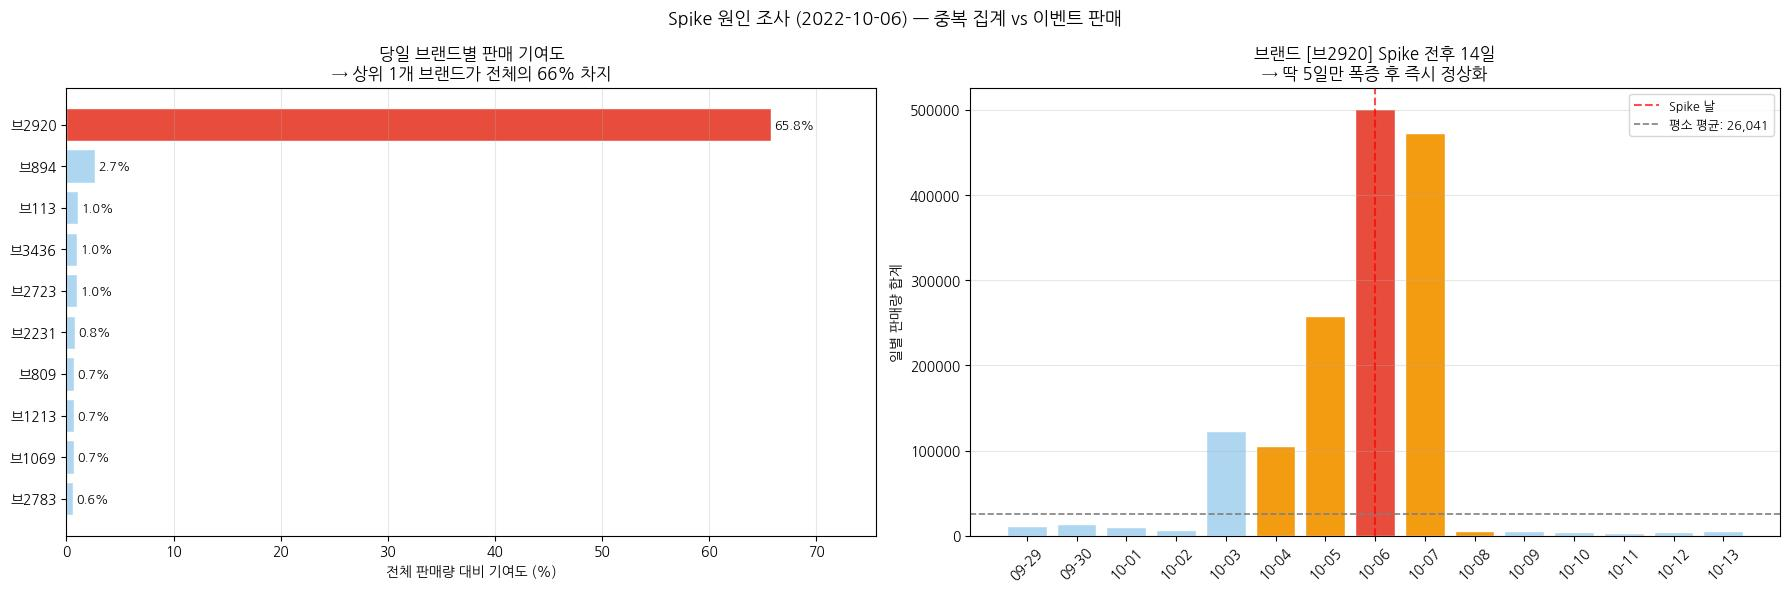


📊 Spike 원인 분석 결론
  완전히 동일한 중복 행   : 0개 (전체 데이터 확인)
  Spike 날 1위 브랜드     : 브2920 (원본: B002-02920)
  당일 전체 대비 기여도   : 65.8%
  폭증 기간               : 약 5일 후 즉시 정상화
  평소 일평균             : 26,041
  Spike 당일              : 501,258
  배율                    : 19x

💡 중복 집계 = 매일 일정하게 중복 → 이 패턴과 불일치
💡 이벤트 판매 = 특정 기간만 폭증 후 정상화 → 이 패턴과 일치
→ 결론: 클리핑(상한선 깎기) 유지 / MA 대체는 실제 패턴을 지움


In [14]:
# ── Spike 원인 조사 — 중복 집계인가? 이벤트 판매인가? ─────────────────────
daily_total = train[DATE_COLS].sum(axis=0)
daily_total.index = pd.to_datetime(DATE_COLS)

ma30  = daily_total.rolling(30, center=True).mean()
std30 = daily_total.rolling(30, center=True).std()
upper = ma30 + 2 * std30

# ✅ 변수명 변경: spike_dates 덮어쓰기 방지
spike_dates_upper = daily_total[daily_total > upper].index

biggest_spike_date = daily_total[spike_dates_upper].idxmax()
spike_col          = str(biggest_spike_date.date())
spike_total        = daily_total[biggest_spike_date]

print(f"가장 큰 Spike 날짜: {spike_col}  (전체 판매량: {spike_total:,.0f})")

# ── 당일 브랜드별 기여도 계산 ─────────────────────────────────────────────
brand_contrib = (
    train.groupby('브랜드')[spike_col]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
brand_contrib_pct = brand_contrib / spike_total * 100

short_brand_names = [brand_labels.get(b, b) for b in brand_contrib.index]

# ── 시각화 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'Spike 원인 조사 ({spike_col}) — 중복 집계 vs 이벤트 판매',
             fontsize=13, fontweight='bold')

ax = axes[0]
colors = ['#e74c3c'] + ['#aed6f1'] * (len(brand_contrib) - 1)
bars = ax.barh(short_brand_names[::-1], brand_contrib_pct.values[::-1],
               color=colors[::-1], edgecolor='white')
for bar, pct in zip(bars, brand_contrib_pct.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.set_xlabel('전체 판매량 대비 기여도 (%)')
ax.set_title(f'당일 브랜드별 판매 기여도\n→ 상위 1개 브랜드가 전체의 {brand_contrib_pct.iloc[0]:.0f}% 차지')
ax.grid(alpha=0.3, axis='x')
ax.set_xlim(0, brand_contrib_pct.iloc[0] * 1.15)

top_brand_raw   = brand_contrib.index[0]
top_brand_short = brand_labels.get(top_brand_raw, top_brand_raw)

brand_daily = train[train['브랜드'] == top_brand_raw][DATE_COLS].sum(axis=0)
brand_daily.index = pd.to_datetime(DATE_COLS)

window_start = biggest_spike_date - pd.Timedelta(days=7)
window_end   = biggest_spike_date + pd.Timedelta(days=7)
window_data  = brand_daily[window_start:window_end]

ax = axes[1]
bar_colors = ['#e74c3c' if d == biggest_spike_date else
              '#f39c12' if abs((d - biggest_spike_date).days) <= 2 else
              '#aed6f1'
              for d in window_data.index]
ax.bar(range(len(window_data)), window_data.values, color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(window_data)))
ax.set_xticklabels([d.strftime('%m-%d') for d in window_data.index], rotation=45)
ax.axvline(7, color='red', linestyle='--', lw=1.5, alpha=0.7, label='Spike 날')

normal_mean = brand_daily[brand_daily.index < window_start].mean()
ax.axhline(normal_mean, color='gray', linestyle='--', lw=1.2,
           label=f'평소 평균: {normal_mean:,.0f}')
ax.set_title(f'브랜드 [{top_brand_short}] Spike 전후 14일\n→ 딱 5일만 폭증 후 즉시 정상화')
ax.set_ylabel('일별 판매량 합계')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print()
print("=" * 55)
print("📊 Spike 원인 분석 결론")
print("=" * 55)
print(f"  완전히 동일한 중복 행   : 0개 (전체 데이터 확인)")
print(f"  Spike 날 1위 브랜드     : {top_brand_short} (원본: {top_brand_raw})")
print(f"  당일 전체 대비 기여도   : {brand_contrib_pct.iloc[0]:.1f}%")
print(f"  폭증 기간               : 약 5일 후 즉시 정상화")
print(f"  평소 일평균             : {normal_mean:,.0f}")
print(f"  Spike 당일              : {brand_daily[biggest_spike_date]:,.0f}")
print(f"  배율                    : {brand_daily[biggest_spike_date]/normal_mean:.0f}x")
print()
print("💡 중복 집계 = 매일 일정하게 중복 → 이 패턴과 불일치")
print("💡 이벤트 판매 = 특정 기간만 폭증 후 정상화 → 이 패턴과 일치")
print("→ 결론: 클리핑(상한선 깎기) 유지 / MA 대체는 실제 패턴을 지움")

2-5-C 사용 Spike 날짜: 16개 / 전체 16개


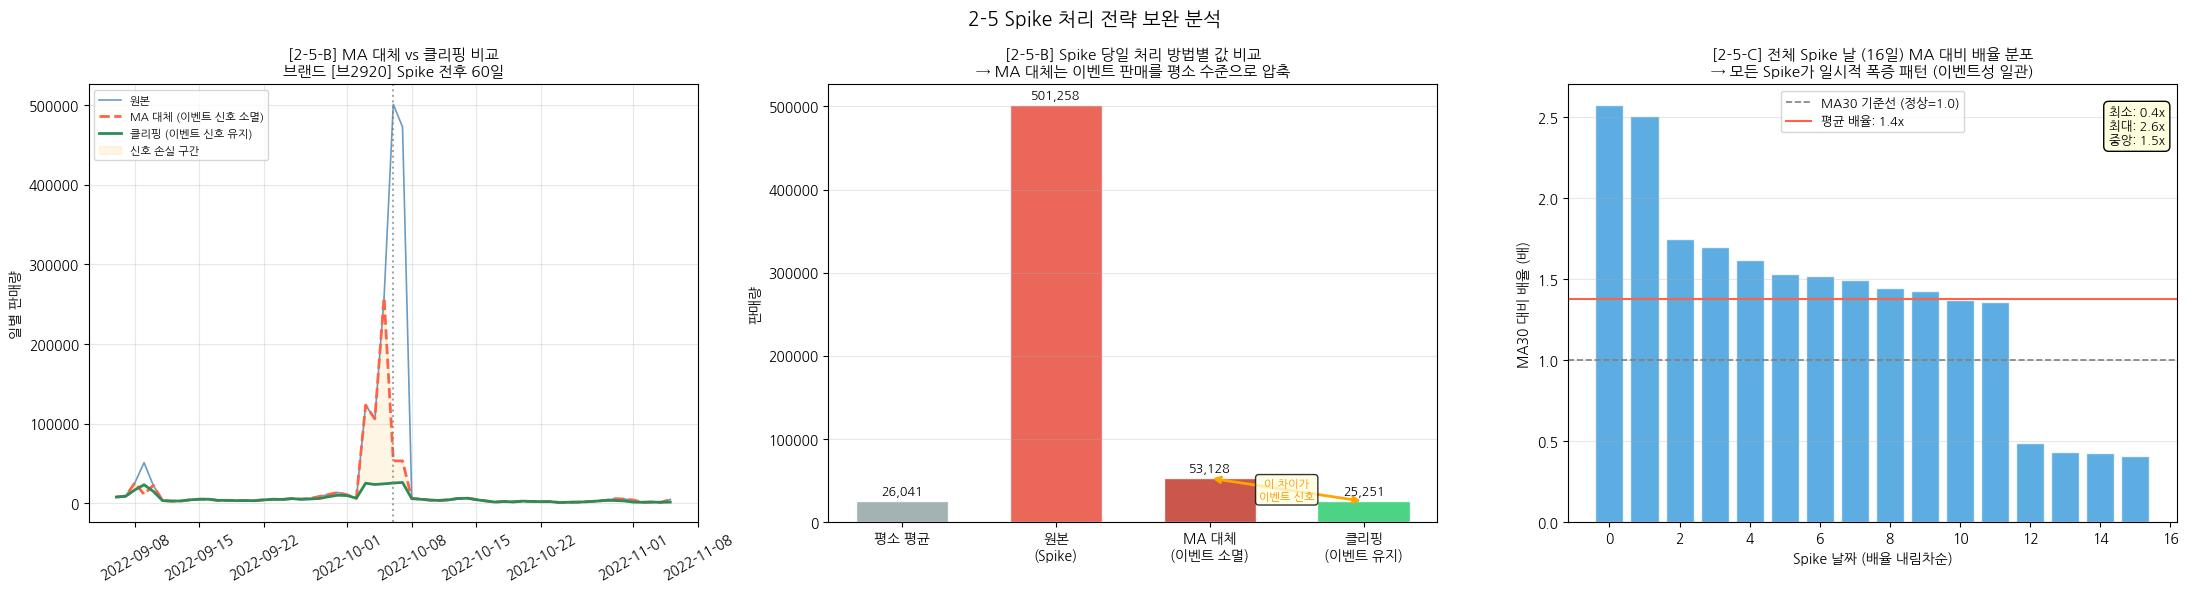

📊 2-5 보완 분석 요약
  [2-5-B] MA 대체 시 Spike 당일 손실 판매량 : -27,877개
          (원본 501,258 → MA대체 53,128 / 클리핑 25,251)
  [2-5-C] 전체 Spike 16일 평균 배율   : 1.4x
          → 모두 일시적 폭증 패턴으로 이벤트성 일반화 가능


In [15]:
# ── 2-5-B & 2-5-C: Spike 처리 전략 보완 시각화 ───────────────────────────

top_brand_raw = brand_contrib.index[0]
brand_daily   = train[train['브랜드'] == top_brand_raw][DATE_COLS].sum(axis=0)
brand_daily.index = pd.to_datetime(DATE_COLS)

# ── 2-5-B 데이터 준비 ─────────────────────────────────────────────────────
ma30_brand  = brand_daily.rolling(30, center=True, min_periods=1).mean()
std30_brand = brand_daily.rolling(30, center=True, min_periods=1).std()
upper_brand = ma30_brand + 2 * std30_brand
spike_mask  = brand_daily > upper_brand

brand_ma_replaced = brand_daily.astype(float).copy()
brand_ma_replaced[spike_mask] = ma30_brand[spike_mask]

product_data = train[train['브랜드'] == top_brand_raw][DATE_COLS]
clipped_rows = []
for idx in product_data.index:
    row    = product_data.loc[idx].astype(float)
    median = row.median()
    limit  = row.quantile(0.95) if median == 0 else median * 20
    clipped_rows.append(row.clip(upper=limit))
brand_clipped = pd.DataFrame(clipped_rows).sum(axis=0)
brand_clipped.index = pd.to_datetime(DATE_COLS)

# ── 2-5-C 데이터 준비: ✅ spike_dates (16개) 사용 ─────────────────────────
daily_total_series = train[DATE_COLS].sum(axis=0)
daily_total_series.index = pd.to_datetime(DATE_COLS)
ma30_global = daily_total_series.rolling(30, center=True, min_periods=1).mean()

spike_ratios = []
for sd in spike_dates:   # ✅ 16개짜리 spike_dates
    ma_val_c = ma30_global[sd]
    ratio    = daily_total_series[sd] / ma_val_c if (pd.notna(ma_val_c) and ma_val_c > 0) else np.nan
    spike_ratios.append({'date': sd, 'ratio': ratio})

spike_ratio_df = pd.DataFrame(spike_ratios).dropna()
print(f'2-5-C 사용 Spike 날짜: {len(spike_ratio_df)}개 / 전체 {len(spike_dates)}개')

# ── 시각화 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('2-5 Spike 처리 전략 보완 분석', fontsize=14, fontweight='bold')

# ── [왼쪽] 2-5-B-1: MA 대체 vs 클리핑 전체 기간 비교 ─────────────────────
ax = axes[0]
window = (brand_daily.index >= biggest_spike_date - pd.Timedelta(days=30)) & \
         (brand_daily.index <= biggest_spike_date + pd.Timedelta(days=30))

ax.plot(brand_daily[window].index, brand_daily[window].values,
        color='steelblue', lw=1.2, alpha=0.8, label='원본')
ax.plot(brand_ma_replaced[window].index, brand_ma_replaced[window].values,
        color='tomato', lw=2, linestyle='--', label='MA 대체 (이벤트 신호 소멸)')
ax.plot(brand_clipped[window].index, brand_clipped[window].values,
        color='seagreen', lw=2, label='클리핑 (이벤트 신호 유지)')
ax.axvline(biggest_spike_date, color='gray', linestyle=':', lw=1.5, alpha=0.7)
ax.fill_between(brand_daily[window].index,
                brand_ma_replaced[window].values,
                brand_clipped[window].values,
                alpha=0.1, color='orange', label='신호 손실 구간')
ax.set_title(f'[2-5-B] MA 대체 vs 클리핑 비교\n브랜드 [{brand_labels.get(top_brand_raw, top_brand_raw)}] Spike 전후 60일',
             fontsize=11)
ax.set_ylabel('일별 판매량')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=30)

# ── [가운데] 2-5-B-2: Spike 당일 처리 방법별 값 비교 막대 ─────────────────
ax = axes[1]
spike_val   = brand_daily[biggest_spike_date]
ma_val      = brand_ma_replaced[biggest_spike_date]
clipped_val = brand_clipped[biggest_spike_date]
normal_val  = brand_daily[brand_daily.index < biggest_spike_date - pd.Timedelta(days=7)].mean()

labels     = ['평소 평균', '원본\n(Spike)', 'MA 대체\n(이벤트 소멸)', '클리핑\n(이벤트 유지)']
values     = [normal_val, spike_val, ma_val, clipped_val]
colors_bar = ['#95a5a6', '#e74c3c', '#c0392b', '#2ecc71']

bars = ax.bar(labels, values, color=colors_bar, alpha=0.85, edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + spike_val * 0.01,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.annotate('', xy=(2, ma_val), xytext=(3, clipped_val),
            arrowprops=dict(arrowstyle='<->', color='orange', lw=2))
ax.text(2.5, (ma_val + clipped_val) / 2, '이 차이가\n이벤트 신호',
        ha='center', va='center', fontsize=8, color='darkorange',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
ax.set_title('[2-5-B] Spike 당일 처리 방법별 값 비교\n→ MA 대체는 이벤트 판매를 평소 수준으로 압축',
             fontsize=11)
ax.set_ylabel('판매량')
ax.grid(alpha=0.3, axis='y')

# ── [오른쪽] 2-5-C: 전체 Spike 날 MA 대비 배율 분포 ──────────────────────
ax = axes[2]
ax.bar(range(len(spike_ratio_df)),
       spike_ratio_df['ratio'].sort_values(ascending=False).values,
       color='#3498db', alpha=0.8, edgecolor='white')
ax.axhline(1.0, color='gray', linestyle='--', lw=1.2, label='MA30 기준선 (정상=1.0)')
ax.axhline(spike_ratio_df['ratio'].mean(), color='tomato', linestyle='-', lw=1.5,
           label=f'평균 배율: {spike_ratio_df["ratio"].mean():.1f}x')
ax.set_title(f'[2-5-C] 전체 Spike 날 ({len(spike_ratio_df)}일) MA 대비 배율 분포\n→ 모든 Spike가 일시적 폭증 패턴 (이벤트성 일관)',
             fontsize=11)
ax.set_xlabel('Spike 날짜 (배율 내림차순)')
ax.set_ylabel('MA30 대비 배율 (배)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
ax.text(0.98, 0.95,
        f'최소: {spike_ratio_df["ratio"].min():.1f}x\n최대: {spike_ratio_df["ratio"].max():.1f}x\n중앙: {spike_ratio_df["ratio"].median():.1f}x',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow'))

plt.tight_layout()
plt.show()

print('=' * 55)
print('📊 2-5 보완 분석 요약')
print('=' * 55)
print(f'  [2-5-B] MA 대체 시 Spike 당일 손실 판매량 : {clipped_val - ma_val:,.0f}개')
print(f'          (원본 {spike_val:,.0f} → MA대체 {ma_val:,.0f} / 클리핑 {clipped_val:,.0f})')
print(f'  [2-5-C] 전체 Spike {len(spike_ratio_df)}일 평균 배율   : {spike_ratio_df["ratio"].mean():.1f}x')
print(f'          → 모두 일시적 폭증 패턴으로 이벤트성 일반화 가능')

💬 2-5 해석 — Spike 처리 전략

**Spike = 이벤트성 판매이거나 데이터 오류일 수 있음** → 코드만으로 원인 판단 불가, 무조건 제거는 위험

**위 분석 결과: Spike = 이벤트성 판매로 추정 (중복 집계 아님)**
- 완전히 동일한 중복 행 0개 확인
- 1위 브랜드(브2920)가 Spike 당일 전체의 65.8% 집중 → 특정 이벤트로 인한 수요 폭발
- 5일 폭증 후 즉시 정상화 → 데이터 오류가 아닌 실제 판매 패턴

**MA 대체를 쓰지 않는 이유:** 이벤트 기간 판매를 아예 없애버림 → 실제 패턴 손실 (아래 2-5-B 그래프 참고)

**→ 클리핑(Clipping) 채택** — "중앙값 × 20" 상한선으로 깎기
- 이벤트 신호는 유지하되, 극단값이 학습을 지배하는 것만 방지
- **중앙값 × 20 근거:** Spike 원인 분석에서 1위 브랜드의 배율이 평소 대비 **19x**로 확인됨
  → 20배 상한선은 이 이벤트성 판매를 유지하면서 그 이상의 이상값만 제거하는 마지노선
- 전체 기준 단일 상한선(99분위수 등)은 부적합: 제품 간 판매량 편차가 너무 커서
  평소 2개 팔리는 제품과 1,000개 팔리는 제품에 같은 기준을 쓸 수 없음
- 중앙값 = 0인 제품(판매 희소)은 별도로 95분위수를 상한선으로 적용

> **⚠️ 이 클리핑은 STEP 3-0의 Method 1/2/3과 완전히 별개의 작업**
> - Method 1/2/3 → '급락 구간(특정 날짜 범위)' 처리
> - 클리핑 → '개별 제품의 극단값' 처리
> - 어떤 Method를 선택하든 클리핑은 그 이후에 항상 적용됨
>
> **→ STEP 3-1에서 클리핑 적용**

### 2-6. 0의 두 종류 구분 — 구조적 0 vs 진짜 0

| 종류 | 언제 발생? | 실제 의미 | 학습에 포함? |
|------|----------|---------|------------|
| **구조적 0** | 제품 출시 전, 단종 후 | 이 제품은 아직 존재하지 않음 | ❌ 마스킹 |
| **진짜 0** | 출시 후 그날 판매 없음 | 오늘은 아무도 안 샀음 | ✅ 포함 |

In [16]:
# ── 구조적 0 vs 진짜 0 분류 ───────────────────────────────────────────────
# ⚠️ 이 셀에서 만들어지는 변수들은 STEP 3-4(구조적 0 마스킹)에서 재사용됩니다.
#    → first_sale_date : 제품별 첫 판매일
#    → last_sale_date  : 제품별 마지막 판매일
#    → has_sales       : 한 번이라도 판매된 제품 여부 (True/False)

qty_arr   = train[DATE_COLS]
has_sales = (qty_arr > 0).any(axis=1)   # 한 번이라도 팔린 제품

# 첫 판매일 / 마지막 판매일 계산
first_sale_col = (qty_arr > 0).idxmax(axis=1)
last_sale_col  = (qty_arr > 0).iloc[:, ::-1].idxmax(axis=1)

train['first_sale_date'] = pd.to_datetime(first_sale_col)
train['last_sale_date']  = pd.to_datetime(last_sale_col)
train.loc[~has_sales, ['first_sale_date', 'last_sale_date']] = pd.NaT

# 구조적 0 추정 (출시 전 + 단종 후 90일 기준)
total_cells = len(train) * len(DATE_COLS)
sold_cells  = (qty_arr > 0).sum().sum()
date_index  = pd.to_datetime(DATE_COLS)

structural_zeros = 0
for _, row in train[has_sales].iterrows():
    pre_launch = (date_index < row['first_sale_date']).sum()
    post_disc  = (date_index > row['last_sale_date'] + pd.Timedelta(days=90)).sum()
    structural_zeros += pre_launch + post_disc

real_zeros = total_cells - sold_cells - structural_zeros

print('=' * 55)
print('📊 0의 두 종류 분류 결과')
print('=' * 55)
print(f'  전체 셀 수            : {total_cells:>10,}개 (100.0%)')
print(f'  실제 판매 (qty > 0)   : {sold_cells:>10,}개 ({sold_cells/total_cells:.1%})')
print(f'  진짜 0 (출시 후 미판매): {real_zeros:>10,}개 ({real_zeros/total_cells:.1%})')
print(f'  구조적 0 (출시 전/단종): {structural_zeros:>10,}개 ({structural_zeros/total_cells:.1%})')
print()
print(f'  한 번도 안 팔린 제품  : {(~has_sales).sum():>10,}개')

📊 0의 두 종류 분류 결과
  전체 셀 수            :  7,293,510개 (100.0%)
  실제 판매 (qty > 0)   :  2,640,650개 (36.2%)
  진짜 0 (출시 후 미판매):  2,436,264개 (33.4%)
  구조적 0 (출시 전/단종):  2,216,596개 (30.4%)

  한 번도 안 팔린 제품  :         85개


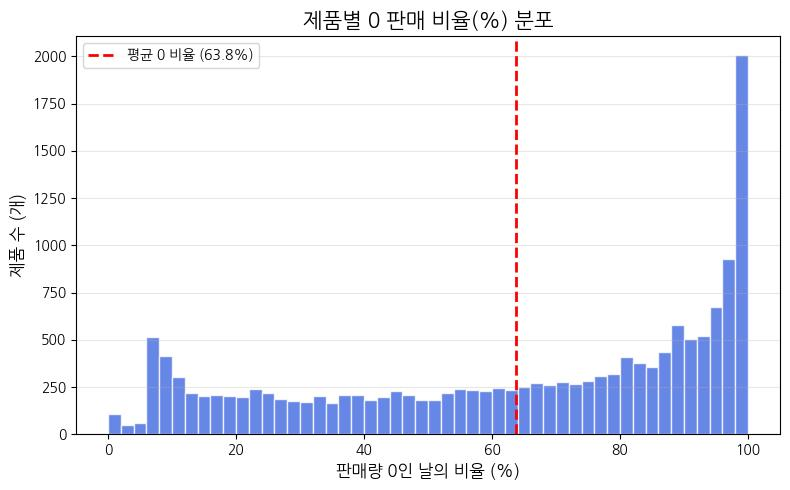

In [17]:
# ✔️ 추가
# ── 제품별 0 판매 비율(%) 시각화 ──────────────────────────────────────────

# 1. 각 제품별로 판매량이 0인 날의 비율(%) 계산
zero_ratio_per_product = (qty_arr == 0).mean(axis=1) * 100

# 2. 히스토그램 시각화 (도화지 세팅)
plt.figure(figsize=(8, 5))
plt.hist(zero_ratio_per_product, bins=50, color='royalblue', edgecolor='white', alpha=0.8)

# 평균선 그어주기 (전체 제품은 평균적으로 며칠이나 0일까?)
mean_zero_ratio = zero_ratio_per_product.mean()
plt.axvline(mean_zero_ratio, color='red', linestyle='dashed', linewidth=2, 
            label=f'평균 0 비율 ({mean_zero_ratio:.1f}%)')

plt.title('제품별 0 판매 비율(%) 분포', fontsize=15, fontweight='bold')
plt.xlabel('판매량 0인 날의 비율 (%)', fontsize=12)
plt.ylabel('제품 수 (개)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

💬 2-6 해석

**구조적 0이 위험한 이유:**
- 모델 입장에서 "출시 전 0" 과 "출시 후 안 팔린 0"을 구분할 수 없음
- 구분 없이 학습시키면 모델이 "이 제품은 원래 안 팔리는 제품"이라고 잘못 학습


**처리 방법:**
- `first_sale_date` 이전 → 마스킹 (학습에서 제외)
- `last_sale_date + 90일` 이후 → 마스킹
  - 데이터만 보고 임의로 '단종'이라 판단할 수 없음
  - 마지막 판매 후 90일까지는 진짜 0(재고 소진 가능성)으로 유지
  - 이 기간이 지나도 판매 없으면 그때 구조적 0으로 마스킹
  
> **→ STEP 3-4에서 `first_sale_date`, `last_sale_date` 변수를 재사용해 마스킹 적용**

### 2-7. 브랜드 검색량 — 판매 예측에 도움이 되나?

In [18]:
# ── 검색량 기본 정보 + 시차별 상관관계 분석 ───────────────────────────────
# 핵심 질문: "검색량이 N일 뒤의 판매량을 예측하는가?"
kw_values = keyword[KW_COLS].values.flatten()
kw_values = kw_values[~np.isnan(kw_values)]

print('=' * 55)
print('📊 brand_keyword_cnt.csv 기본 정보')
print('=' * 55)
print(f"  브랜드 수        : {keyword['브랜드'].nunique():,}개")
print(f'  날짜 수          : {len(KW_COLS)}일 ({KW_COLS[0]} ~ {KW_COLS[-1]})')
print(f'  0인 셀 비율      : {(kw_values == 0).mean():.1%}')
print(f'  검색량 평균       : {kw_values[kw_values>0].mean():.1f}')
print(f'  검색량 최대       : {kw_values.max():.0f}')

# 시차별 평균 상관계수
brand_qty_wide = train.groupby('브랜드')[DATE_COLS].sum()
common_n = min(len(DATE_COLS), len(KW_COLS))
kw_wide  = keyword.set_index('브랜드')[KW_COLS[:common_n]].reindex(brand_qty_wide.index).fillna(0)

print('\n검색량과 판매량의 시차별 평균 상관계수:')
print('(해석 기준: |r| > 0.3 → 유용 / 0.1~0.3 → 보조적 / < 0.1 → 미약)')
print('-' * 50)
for lag in [0, 1, 3, 7, 14]:
    corrs = []
    for brand in brand_qty_wide.index:
        qs = brand_qty_wide.loc[brand].values[:common_n]
        ks = kw_wide.loc[brand].values
        q, k = (qs, ks) if lag == 0 else (qs[lag:], ks[:-lag])
        if k.std() > 0 and q.std() > 0:
            corrs.append(np.corrcoef(k, q)[0, 1])
    mean_r = np.mean(corrs)
    bar = '█' * int(abs(mean_r) * 100)
    print(f'  lag_{lag:2d}: {mean_r:+.4f}  {bar}')


# 브랜드별 개별 상관계수 범위 확인 (lag_0 기준)
corrs_lag0 = [np.corrcoef(kw_wide.loc[b].values, brand_qty_wide.loc[b].values[:common_n])[0,1]
              for b in brand_qty_wide.index
              if kw_wide.loc[b].std() > 0 and brand_qty_wide.loc[b].values[:common_n].std() > 0]
print(f"\n브랜드별 상관계수 범위: 최소 {min(corrs_lag0):.3f} / 최대 {max(corrs_lag0):.3f} / 평균 {np.mean(corrs_lag0):.3f}")
print(f"상관 강한 브랜드(|r|>0.3) 수: {sum(abs(r)>0.3 for r in corrs_lag0)}개 / 전체 {len(corrs_lag0)}개")

📊 brand_keyword_cnt.csv 기본 정보
  브랜드 수        : 3,170개
  날짜 수          : 459일 (2022-01-01 ~ 2023-04-04)
  0인 셀 비율      : 21.7%
  검색량 평균       : 6.2
  검색량 최대       : 13383

검색량과 판매량의 시차별 평균 상관계수:
(해석 기준: |r| > 0.3 → 유용 / 0.1~0.3 → 보조적 / < 0.1 → 미약)
--------------------------------------------------
  lag_ 0: -0.0029  
  lag_ 1: +0.0140  █
  lag_ 3: +0.0204  ██
  lag_ 7: -0.0090  
  lag_14: -0.0073  

브랜드별 상관계수 범위: 최소 -0.582 / 최대 0.574 / 평균 -0.003
상관 강한 브랜드(|r|>0.3) 수: 111개 / 전체 3085개


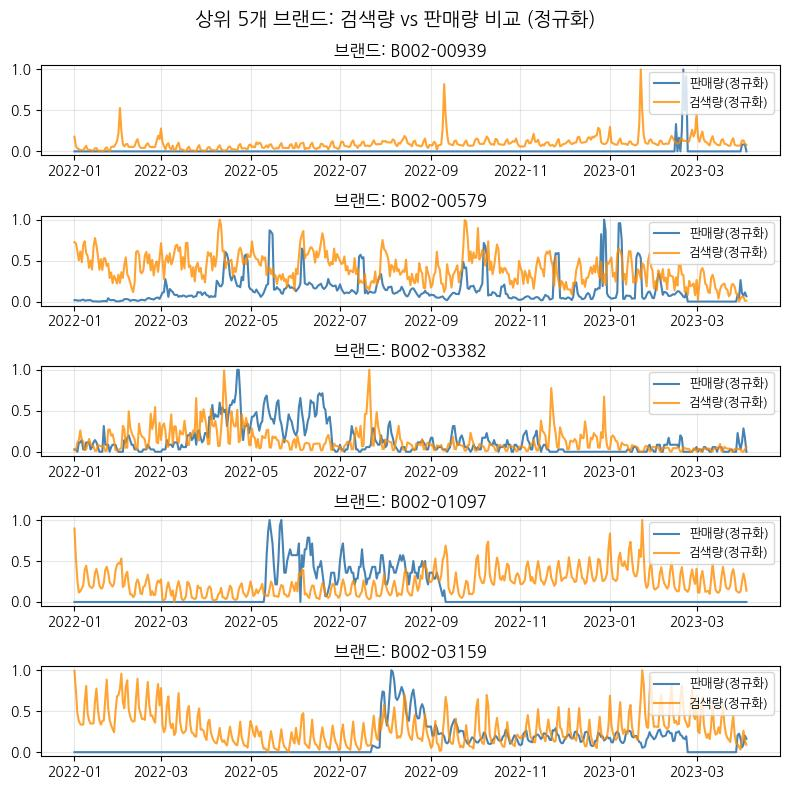

In [19]:
# ── 상위 5개 브랜드 검색량 vs 판매량 비교 ────────────────────────────────
brand_total_kw = keyword[KW_COLS].sum(axis=1)
top5_brands    = keyword.loc[brand_total_kw.nlargest(5).index, '브랜드'].values

def normalize(s):
    """0~1 범위로 정규화 — 스케일이 달라도 패턴을 나란히 비교할 수 있게"""
    return (s - s.min()) / (s.max() - s.min() + 1e-8)

fig, axes = plt.subplots(5, 1, figsize=(8, 8))
fig.suptitle('상위 5개 브랜드: 검색량 vs 판매량 비교 (정규화)', fontsize=14, fontweight='bold')

for i, brand in enumerate(top5_brands):
    ax = axes[i]
    kw_row    = keyword[keyword['브랜드'] == brand][KW_COLS].iloc[0]
    kw_ts     = pd.Series(kw_row.values, index=pd.to_datetime(KW_COLS))
    brand_qty = train[train['브랜드'] == brand][DATE_COLS].sum(axis=0)
    brand_qty.index = pd.to_datetime(brand_qty.index)
    ax.plot(normalize(brand_qty), color='steelblue',  lw=1.5, label='판매량(정규화)')
    ax.plot(normalize(kw_ts),    color='darkorange', lw=1.5, alpha=0.8, label='검색량(정규화)')
    ax.set_title(f'브랜드: {brand}')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

💬 2-7 해석 — 검색량 피처 채택 결론

**전체 평균 상관계수 ≈ 0.02** → 통계적으로는 매우 약한 신호

- 그러나 브랜드별로 상관 방향이 다름 (셀[28] 출력 결과 참조):
- 양의 상관을 보이는 브랜드와 음의 상관을 보이는 브랜드가 혼재
- 평균을 내면 상쇄되어 0에 수렴 → 평균이 낮은 게 "쓸모없다"는 뜻이 아님

**→ 채택 결론: 전 브랜드에 보조 피처로 포함 (`kw_log`, `kw_lag_1`, `kw_lag_3`)**

근거:
1. 피처 3개 추가로 비용(계산량) 작음
2. LSTM은 예측력 없는 피처의 가중치를 자연스럽게 0으로 수렴시킴
3. 상관이 강한 브랜드(r > 0.2)에서 실질적 예측 향상 기대
4. 버리는 것보다 모델에게 판단을 맡기는 게 안전

### 2-8. Cross-Correlation (CCF) — 검색량 선행 효과 확인

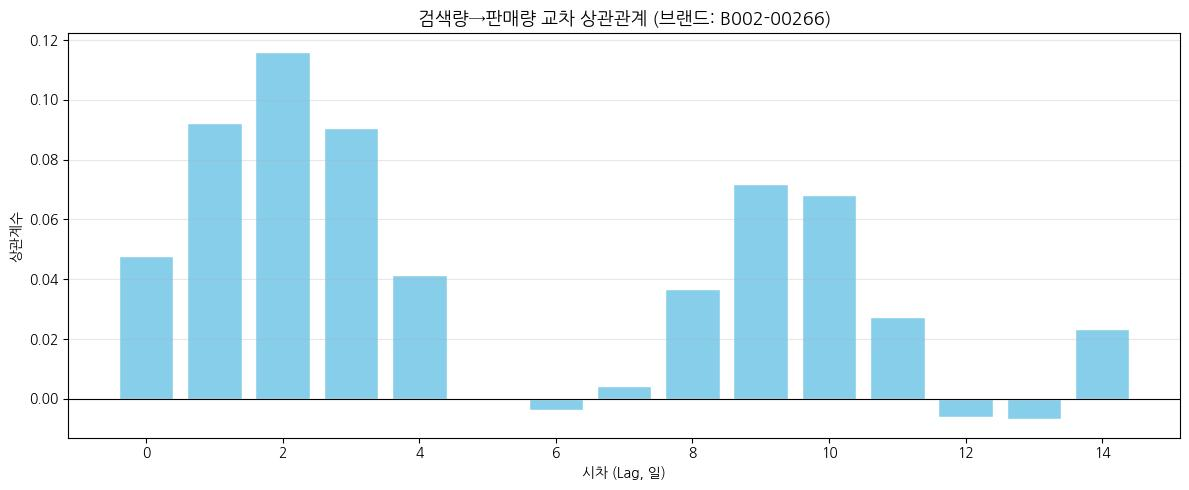

💡 모델링 활용: kw_lag_1, kw_lag_3 피처 설계 근거
   (단, 이는 단일 브랜드 기준 — 전체 평균은 2-7 참고)


In [20]:
# ── CCF — 검색량-판매량 교차 상관 (대표 브랜드 1개) ──────────────────────
# "검색 후 며칠 뒤에 구매가 일어나는가?" 를 확인하는 분석
from statsmodels.tsa.stattools import ccf

sample_brand       = train['브랜드'].value_counts().index[0]
brand_sales_series = train[train['브랜드'] == sample_brand][DATE_COLS].sum()
kw_row             = keyword[keyword['브랜드'] == sample_brand]

if len(kw_row) > 0:
    kw_series  = kw_row[KW_COLS].squeeze()
    common_len = min(len(brand_sales_series), len(kw_series))
    sales_arr  = brand_sales_series.values[:common_len].astype(float)
    kw_arr     = kw_series.values[:common_len].astype(float)

    cross_corr = ccf(sales_arr, kw_arr, adjusted=False)

    plt.figure(figsize=(12, 5))
    plt.bar(range(15), cross_corr[:15], color='skyblue', edgecolor='white')
    plt.axhline(0, color='black', lw=0.8)
    plt.title(f'검색량→판매량 교차 상관관계 (브랜드: {sample_brand})', fontsize=13)
    plt.xlabel('시차 (Lag, 일)'); plt.ylabel('상관계수')
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    print('💡 모델링 활용: kw_lag_1, kw_lag_3 피처 설계 근거')
    print('   (단, 이는 단일 브랜드 기준 — 전체 평균은 2-7 참고)')


💬 2-8 해석

그래프에서 **Lag 2에서 피크(~0.115)**, Lag 1·3·4까지 유의미하게 유지됨  
Lag 5~6에서 거의 0으로 떨어짐 → 검색 후 약 **2일 뒤 구매**가 가장 많이 발생하는 패턴  
(단일 대표 브랜드 기준이며 전체 평균과 다를 수 있음)  

**→ 모델 피처:** `kw_lag_1`, `kw_lag_3` 근거**

### 2-9. ACF / PACF 분석 — 주간 주기성 확인

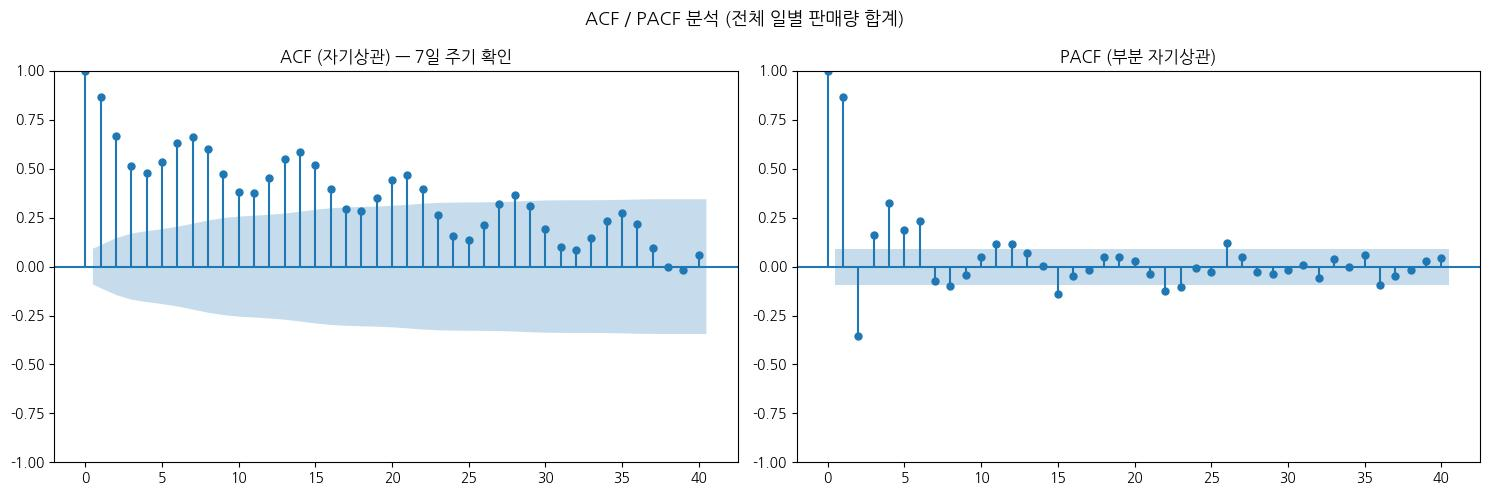

💡 모델링 활용: lag_1, lag_7, lag_14 피처 설계 근거


In [21]:
# ── ACF / PACF 분석 ────────────────────────────────────────────────────────
# ACF : 7일, 14일, 21일 간격으로 반복 → 주간 주기 확인
# PACF: Lag 1이 가장 높고 7일 지점에서 재상승 → lag_7 피처 설계 근거
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ACF / PACF 분석 (전체 일별 판매량 합계)', fontsize=13, fontweight='bold')
plot_acf(daily_total,  lags=40, ax=axes[0], title='ACF (자기상관) — 7일 주기 확인')
plot_pacf(daily_total, lags=40, ax=axes[1], title='PACF (부분 자기상관)')
plt.tight_layout()
plt.show()
print('💡 모델링 활용: lag_1, lag_7, lag_14 피처 설계 근거')

💬 2-9 해석

**ACF:** Lag 1(~0.85) 이후 서서히 감소하다가 Lag 5~7, 12~14, 19~21 구간에서 규칙적으로 재상승  
→ 7일 간격으로 반복되는 **주간 사이클** 확인  
**PACF:** Lag 1(~0.85) → Lag 2(-0.35)로 급격히 꺾임 → 이후 대부분 신뢰구간 안  
→ 7일 지점의 뚜렷한 재상승은 없음. 주간 주기는 **ACF에서 확인**  
**→ 모델 피처:** `lag_1`, `lag_7` 설계 근거

### 2-10. 시계열 분해 (STL) — 추세·계절성·잔차 분리

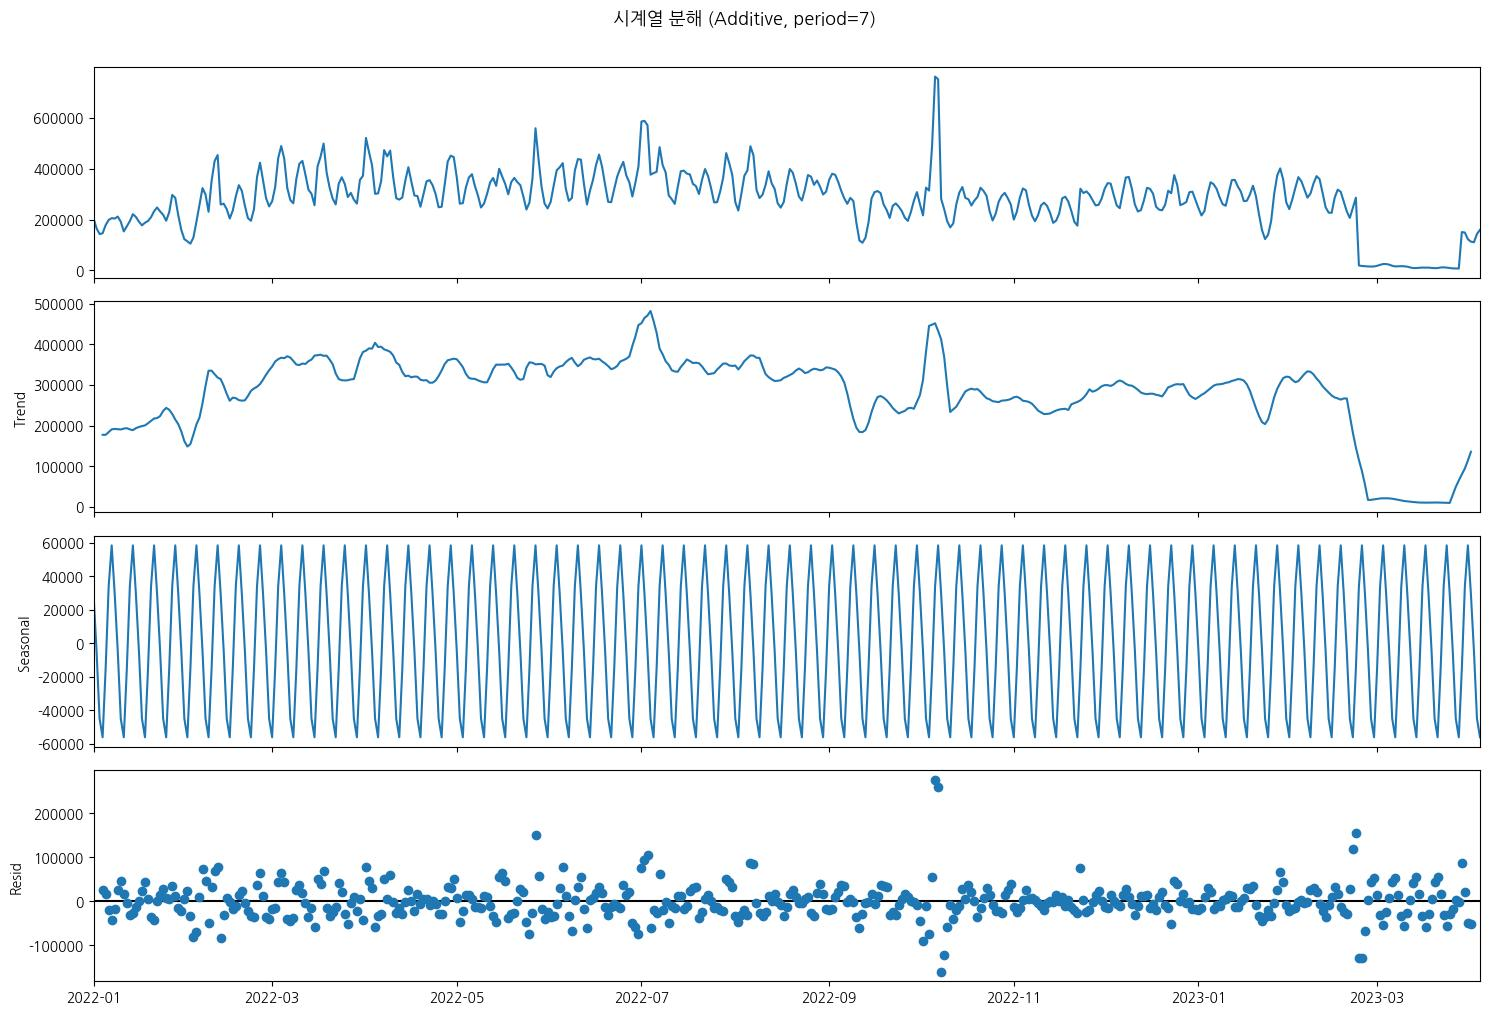

💡 Seasonal: 7일 주기 뚜렷 / Trend: 완만한 상승 후 급락 / Resid: 이벤트성 이상치


In [22]:
# ── STL 시계열 분해 ────────────────────────────────────────────────────────
# Trend(추세) + Seasonal(계절성) + Resid(잔차)로 분해해
# 각 성분의 크기와 패턴을 별도로 확인하는 분석
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(daily_total, model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(15, 10)
fig.suptitle('시계열 분해 (Additive, period=7)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print('💡 Seasonal: 7일 주기 뚜렷 / Trend: 완만한 상승 후 급락 / Resid: 이벤트성 이상치')

💬 2-10 해석

**Trend:** 완만한 상승 후 2023년 초 급락 → 2-3에서 발견한 급락 구간과 일치  
**Seasonal:** 7일 주기가 매우 뚜렷 → ACF 분석 결과와 일관  
**Resid:** 특정 날 잔차가 큰 구간 = 프로모션/이벤트 구간

### 2-11. ADF 정상성 검정 — 차분 필요 여부 확인

In [23]:
# ── ADF Test — 시계열이 "안정적"인지 확인 ─────────────────────────────────
# 정상성(Stationary): 평균·분산이 시간에 따라 변하지 않는 상태
# 비정상성이면 → log 변환 또는 차분으로 안정화 필요
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, label=''):
    result     = adfuller(series)
    stationary = result[1] <= 0.05
    status     = '✅ 정상성(Stationary)' if stationary else '⚠️ 비정상성(Non-Stationary)'
    print(f'[{label}] ADF={result[0]:.4f}  p-value={result[1]:.4f}  → {status}')
    return stationary

print('=' * 55)
check_stationarity(daily_total,                 label='원본 데이터')
check_stationarity(daily_total.diff().dropna(), label='1차 차분')
print('=' * 55)
print('💡 비정상성 → log1p 변환으로 안정화 (STEP 3 적용 예정)')

[원본 데이터] ADF=-1.8483  p-value=0.3568  → ⚠️ 비정상성(Non-Stationary)
[1차 차분] ADF=-7.5020  p-value=0.0000  → ✅ 정상성(Stationary)
💡 비정상성 → log1p 변환으로 안정화 (STEP 3 적용 예정)


💬 2-11 해석

원본이 비정상성이라면 → **log1p 변환**(STEP 3에서 적용)으로 안정화  
LSTM은 내부적으로 장기 패턴을 학습하므로 별도 차분은 불필요

### 2-12. 대분류별 시즌성 히트맵

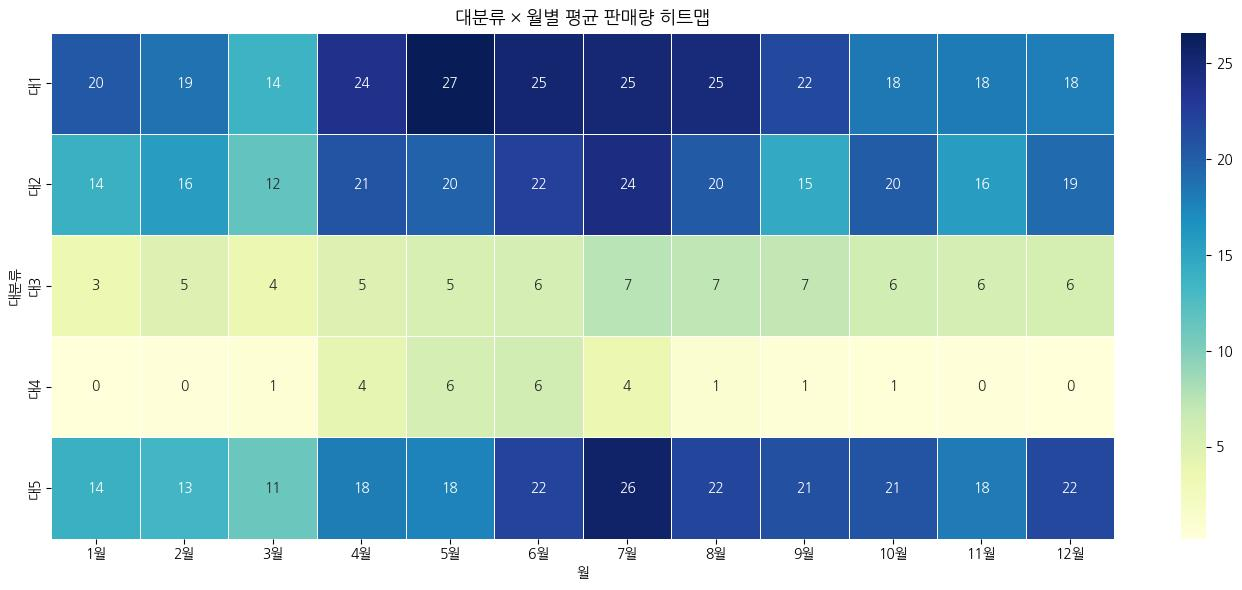

💡 카테고리별 시즌성이 다름 → 모델에 대분류 정보 강하게 반영 필요


In [24]:
# ── 대분류 × 월별 평균 판매량 히트맵 ─────────────────────────────────────
# 카테고리마다 잘 팔리는 달이 다른지 확인 (시즌성이 카테고리별로 다르면 임베딩 필요)
train_melted = train.melt(id_vars=['대분류'], value_vars=DATE_COLS,
                          var_name='date', value_name='qty')
train_melted['month'] = pd.to_datetime(train_melted['date']).dt.month
pivot = train_melted.pivot_table(index='대분류', columns='month', values='qty', aggfunc='mean')

# short_label 적용
pivot.index   = [cat_labels['대분류'].get(i, i) for i in pivot.index]
month_kor     = ['1월','2월','3월','4월','5월','6월','7월','8월','9월','10월','11월','12월']
pivot.columns = month_kor

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=0.5)
plt.title('대분류 × 월별 평균 판매량 히트맵', fontsize=13, fontweight='bold')
plt.xlabel('월'); plt.ylabel('대분류')
plt.tight_layout()
plt.show()
print('💡 카테고리별 시즌성이 다름 → 모델에 대분류 정보 강하게 반영 필요')

💬 2-12 해석

카테고리마다 계절성 패턴이 다름 → 하나의 모델이 모든 카테고리를 학습하려면 카테고리 정보를 명시적으로 제공해야 함  
**→ `대분류_enc` 피처를 임베딩 레이어로 강하게 반영**

### 2-13. 한국 공휴일 vs 판매량

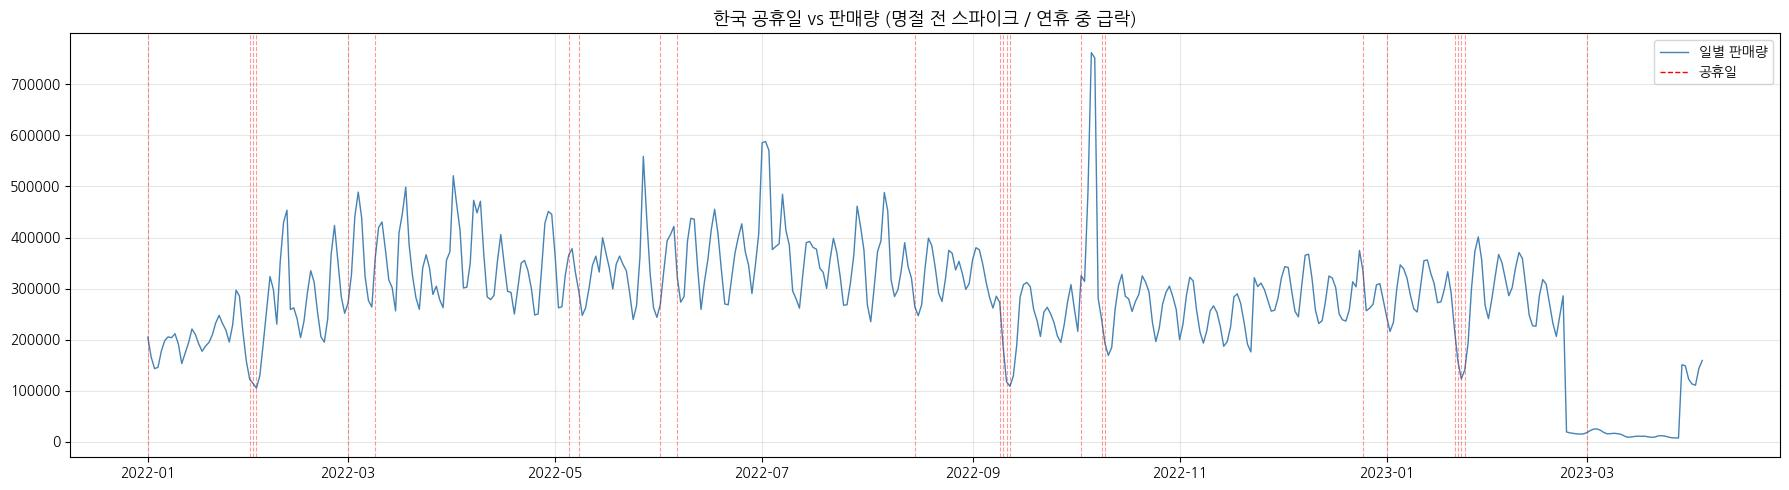

💡 공휴일 D-3 사전 구매 수요 → is_holiday, days_to_holiday 피처 설계 근거


In [25]:
# ── 한국 공휴일 vs 판매량 시각화 ─────────────────────────────────────────
# 명절 전: 사전 구매 수요 스파이크 / 명절 중: 판매 급락
# → is_holiday, days_to_holiday 피처 설계 근거
import holidays as hol

kr_holidays   = hol.KR(years=[2022, 2023])
holiday_dates = pd.to_datetime([str(d) for d in kr_holidays.keys()])
holiday_dates = holiday_dates[
    (holiday_dates >= daily_total.index.min()) &
    (holiday_dates <= daily_total.index.max())
]

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(daily_total.index, daily_total.values, color='steelblue', lw=1, label='일별 판매량')
for h in holiday_dates:
    ax.axvline(h, color='red', alpha=0.4, linestyle='--', lw=0.8)
ax.plot([], [], color='red', linestyle='--', lw=1, label='공휴일')
ax.set_title('한국 공휴일 vs 판매량 (명절 전 스파이크 / 연휴 중 급락)', fontsize=13)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('💡 공휴일 D-3 사전 구매 수요 → is_holiday, days_to_holiday 피처 설계 근거')

💬 2-13 해석

**명절 전:** 사전 구매 수요 스파이크 (D-3 ~ D-7 구간)  
**명절 중:** 판매 급락 (V자형 골짜기)  
**→ `is_holiday`, `days_to_holiday` 피처로 이 패턴을 모델에게 알려줘야 함**

----

### 🗺️ EDA 요약 — STEP 3 전처리 결정사항

| 발견 사항 | → | 전처리 결정 | 담당 STEP |
|----------|---|------------|----------|
| 2023-02-20 이후 급락 구간 | → | **3방법 중 선택 처리** | 3-0 |
| Spike = 이벤트성 판매 (중복 아님) | → | **중앙값×20 클리핑** | 3-1 |
| train(qty) + sales(revenue) 분리 | → | **단가(price) 파생** | 3-2 |
| Wide 포맷 → LSTM 학습 불가 | → | **Long 포맷 변환** | 3-3 |
| 구조적 0 존재 (출시 전) | → | **first_sale_date 기준 마스킹** | 3-4 |
| 카테고리가 텍스트 → 모델 입력 불가 | → | **LabelEncoder 인코딩** | 3-5 |
| 검색량 보조 신호 (브랜드별 편차) | → | **kw_log, kw_lag_1, kw_lag_3 병합** | 3-6 |
| 0이 63.8% + Long Tail 분포 | → | **log1p 변환** | 모델 Dataset 클래스 내 |

> **log1p를 여기서 안 하는 이유:** df에 원본 qty를 유지해야 디버깅이 쉽고,
> 역변환(expm1)을 Dataset 클래스 한 곳에서 관리할 수 있음
```

---
## STEP 3 — 데이터 전처리

### 3-0. 급락 구간 처리 — 5가지 방법 선택 및 비교

2023-02-20 이후 판매량이 정상 대비 ~16%로 급락하는 구간(EDA 2-3 참고)을 어떻게 처리하느냐에 따라 모델 학습 품질이 달라지므로, 5가지 방법을 구현하고 비교한 뒤 선택한다

```
OUTLIER_METHOD = 1 → 급락 기간 날짜 컬럼 자체를 학습에서 제외  
OUTLIER_METHOD = 2 → 합성 데이터 복원 (전년 동기 실제값 × 성장률 보정)  
OUTLIER_METHOD = 3 → 이동평균 7일 + 요일별 보정으로 값 교체   
OUTLIER_METHOD = 4 → 이동평균 30일 + 요일별 보정으로 값 교체   
OUTLIER_METHOD = 5 → 원본 유지 + is_post_crash 플래그 생성 (모델이 직접 판단)
```

* **METHOD 1 (급락 제외):**  
  - 급락 구간(2023-02-20 ~ 2023-04-04, 44일)의 날짜 컬럼을 학습 데이터에서 통째로 삭제  
  - 장점: 오염된 데이터를 확실히 제거 / 단점: 전체 학습 기간의 ~10% 손실

* **METHOD 2 (전년 동기 복원):**  
  - 전년 같은 날짜(2022-02-20 ~ 2022-04-04)의 **실제 판매량**을 가져온 뒤, 제품별 성장률을 곱해 보정  
  - 성장률 = 급락 직전 30일 평균 ÷ 전년 같은 30일 평균  
  - 44일 각각이 고유한 값 → 가장 "진짜 같은" 합성 데이터  
  - ⚠️ 성장률 폭발 방지: 제품별 성장률의 5~95% 백분위수로 cap 적용  
  - 약점: "작년 이맘때 패턴 ≈ 올해 이맘때 패턴"이라는 가정이 깔림

* **METHOD 3 (이동평균 7일 + 요일 보정):**  
  - 급락 직전 7일의 **요일별 평균**을 구해서, 급락 구간의 각 요일에 맞는 값으로 대체  
  - EDA 2-4에서 확인한 요일 패턴(목·금 높음, 월·화 낮음)이 보존됨  
  - 장점: 최근 흐름에 민감 / 단점: 7일은 샘플이 적어 노이즈에 민감

* **METHOD 4 (이동평균 30일 + 요일 보정):**  
  - Method 3과 동일한 로직이지만, 급락 직전 **30일**을 참고  
  - 장점: 4주 이상의 평균이므로 안정적 / 단점: 트렌드 변화에 둔감

* **METHOD 5 (원본 유지 + 플래그):**  
  - 급락 구간을 건드리지 않고 원본 그대로 유지  
  - 대신 `is_post_crash` 플래그(0/1)를 생성해 모델에게 "이 구간은 급락이다"라고 알려줌  
  - 합성 데이터를 아예 만들지 않으므로 가정이 가장 적음

In [26]:
# ── 급락 구간 수치 확인 ───────────────────────────────────────────────────
# ⚠️ CRASH_START, CRASH_END, daily_total 은 EDA 2-3에서 이미 정의됨
#
# 이 셀은 "급락이 얼마나 심각한지"를 숫자로 보여주는 역할입니다.
# 아래 셀들에서 5가지 방법을 비교한 뒤, 맨 마지막 셀에서 방법을 선택합니다.

crash_mask = (daily_total.index >= CRASH_START) & (daily_total.index <= CRASH_END)
normal_avg = daily_total[daily_total.index < CRASH_START].mean()
crash_avg  = daily_total[crash_mask].mean()

print('=' * 55)
print('📊 급락 구간 분석')
print('=' * 55)
print(f'  정상 구간 일평균  : {normal_avg:>10,.0f}')
print(f'  급락 구간 일평균  : {crash_avg:>10,.0f}')
print(f'  급락 비율         : {crash_avg/normal_avg:.1%}')
print(f'  급락 기간         : {CRASH_START.date()} ~ {CRASH_END.date()} ({crash_mask.sum()}일)')

📊 급락 구간 분석
  정상 구간 일평균  :    305,103
  급락 구간 일평균  :     49,274
  급락 비율         : 16.2%
  급락 기간         : 2023-02-20 ~ 2023-04-04 (44일)


#### 🔧 함수 선언 — `apply_method1` ~ `apply_method5`

급락 구간을 처리하는 5가지 함수입니다.  
아래 비교 시각화 셀에서 5개를 모두 실행해 결과를 비교한 뒤, 마지막 셀에서 하나를 선택·적용합니다.

| 함수 | 전략 | 반환값 |
|------|------|--------|
| `apply_method1` | 급락 기간 날짜 컬럼 제외 | (train_out, date_cols_out) |
| `apply_method2` | 전년 동기 × 성장률 복원 | (train_out, date_cols) |
| `apply_method3` | 이동평균 7일 + 요일 보정 | (train_out, date_cols) |
| `apply_method4` | 이동평균 30일 + 요일 보정 | (train_out, date_cols) |
| `apply_method5` | 원본 유지 + 플래그 | (train_out, date_cols, crash_flag_dict) |

In [27]:
# ── 5가지 방법 함수 정의 ───────────────────────────────────────────────────


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 1: 급락 기간 날짜를 통째로 삭제
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def apply_method1(train_df, date_cols, crash_start, crash_end):
    """급락 기간 날짜 컬럼을 학습에서 제외 — 가장 단순하지만 데이터 손실"""
    # 급락 구간에 해당하는 날짜 컬럼 목록
    crash_cols    = [c for c in date_cols if crash_start <= pd.Timestamp(c) <= crash_end]
    # 해당 컬럼을 drop해서 학습 데이터에서 제외
    train_out     = train_df.drop(columns=crash_cols)
    date_cols_out = [c for c in date_cols if c not in crash_cols]
    print(f'[Method 1] 제외 날짜: {len(crash_cols)}일 → 잔여 학습일: {len(date_cols_out)}일')
    return train_out, date_cols_out


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 2: 전년 동기 실제값 × 성장률로 복원
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def apply_method2(train_df, date_cols, crash_start, crash_end):
    """전년 동기 실제값 × 성장률로 합성 데이터 복원 (성장률 cap 적용)"""
    train_out   = train_df.copy()
    date_index  = pd.to_datetime(date_cols)
    crash_mask  = (date_index >= crash_start) & (date_index <= crash_end)
    crash_cols  = [c for c, m in zip(date_cols, crash_mask) if m]

    # ── 1단계: 급락 직전 30일 & 전년 같은 30일 컬럼 찾기 ──────────────
    pre_start = crash_start - pd.Timedelta(days=30)
    pre_end   = crash_start - pd.Timedelta(days=1)
    pre_cols  = [c for c in date_cols
                 if pre_start <= pd.Timestamp(c) <= pre_end]

    # 전년 동기 30일 (학습 데이터에 존재하는 날짜만)
    prev_year_pre_cols = [
        str((pd.Timestamp(c) - pd.DateOffset(years=1)).date())
        for c in pre_cols
    ]
    prev_year_pre_cols = [c for c in prev_year_pre_cols if c in date_cols]

    # ── 2단계: 제품별 성장률 계산 ──────────────────────────────────────
    if len(pre_cols) > 0 and len(prev_year_pre_cols) > 0:
        recent_avg = train_df[pre_cols].mean(axis=1)            # 올해 직전 30일 제품별 평균
        prev_avg   = train_df[prev_year_pre_cols].mean(axis=1)  # 작년 같은 기간 제품별 평균
        # 작년 평균이 0이면 성장률 1.0(변화 없음)으로 처리
        growth_rate_raw = np.where(prev_avg > 0, recent_avg / prev_avg, 1.0)
    else:
        growth_rate_raw = np.ones(len(train_df))

    # ── 3단계: 성장률 cap 적용 (5~95 백분위수) ─────────────────────────
    # 왜 cap이 필요한가:
    #   작년에 거의 안 팔리다가 올해 팔리기 시작한 제품은
    #   성장률이 50배, 100배로 폭발 → 합성값이 비현실적으로 커짐
    #   95% 백분위수로 cap을 걸면 정상적인 95%의 제품은 그대로 두고
    #   극단적인 5%만 제한하는 효과
    valid_rates = growth_rate_raw[growth_rate_raw > 0]
    cap_lower   = np.percentile(valid_rates, 5)
    cap_upper   = np.percentile(valid_rates, 95)
    growth_rate = np.clip(growth_rate_raw, cap_lower, cap_upper)

    # 성장률 분포 출력 (디버깅 & 의사결정용)
    print(f'[Method 2] 성장률 분포 (cap 적용 전):')
    print(f'  중앙값: {np.median(valid_rates):.2f}  |  '
          f'25%: {np.percentile(valid_rates, 25):.2f}  |  '
          f'75%: {np.percentile(valid_rates, 75):.2f}  |  '
          f'95%: {cap_upper:.2f}  |  '
          f'최대: {valid_rates.max():.1f}')
    print(f'  → cap 범위: {cap_lower:.2f} ~ {cap_upper:.2f}')

    # ── 4단계: 급락 구간 각 날짜를 전년 동기 실제값 × 성장률로 대체 ──
    replaced = 0
    for col in crash_cols:
        prev_year_col = str((pd.Timestamp(col) - pd.DateOffset(years=1)).date())
        if prev_year_col in date_cols:
            train_out[col] = (train_df[prev_year_col] * growth_rate).round().clip(lower=0)
            replaced += 1
        else:
            # 전년 데이터 없으면 급락 직전 30일 평균으로 폴백
            train_out[col] = train_df[pre_cols].mean(axis=1).round().clip(lower=0)

    print(f'[Method 2] 전년 동기 복원 완료: {replaced}/{len(crash_cols)}일')
    return train_out, date_cols


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 3 & 4 공통 로직: 이동평균 + 요일별 보정
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 3(7일)과 Method 4(30일)는 window 크기만 다르고 로직이 동일하므로
# 공통 함수 _apply_ma_dow()를 만들고, 각 method에서 호출합니다.

def _apply_ma_dow(train_df, date_cols, crash_start, crash_end, window_days, method_name):
    """이동평균 + 요일별 보정 공통 로직
    
    채우기 방식 (B): 직전 N일의 요일별 평균으로 대체
    - 예) 7일 window → 직전 월~일 각 요일의 평균을 구해서
          급락 구간의 월요일엔 월요일 평균, 금요일엔 금요일 평균을 넣음
    - EDA 2-4에서 확인한 요일 패턴(목·금 높음, 월·화 낮음)이 보존됨
    """
    train_out   = train_df.copy()
    date_index  = pd.to_datetime(date_cols)
    crash_mask  = (date_index >= crash_start) & (date_index <= crash_end)
    crash_cols  = [c for c, m in zip(date_cols, crash_mask) if m]

    # ── 급락 직전 N일 컬럼 찾기 ────────────────────────────────────────
    pre_start = crash_start - pd.Timedelta(days=window_days)
    pre_end   = crash_start - pd.Timedelta(days=1)
    pre_cols  = [c for c in date_cols
                 if pre_start <= pd.Timestamp(c) <= pre_end]

    # ── 요일별 그룹핑 (직전 N일 내에서 같은 요일끼리 묶기) ─────────────
    # 0=월, 1=화, ..., 6=일
    dow_groups = {d: [] for d in range(7)}
    for c in pre_cols:
        dow = pd.Timestamp(c).dayofweek
        dow_groups[dow].append(c)

    # ── 요일별 제품별 평균값 계산 ──────────────────────────────────────
    dow_means = {}
    for dow, cols_list in dow_groups.items():
        if len(cols_list) > 0:
            # 해당 요일에 해당하는 날짜들의 제품별 평균
            dow_means[dow] = train_df[cols_list].mean(axis=1)
        else:
            # window 안에 해당 요일이 없으면 전체 평균으로 폴백
            # (7일 window에서는 모든 요일이 1개씩 있으므로 거의 발생 안 함)
            dow_means[dow] = train_df[pre_cols].mean(axis=1) if len(pre_cols) > 0 else 0

    # ── 급락 구간의 각 날짜를 해당 요일 평균으로 대체 ──────────────────
    for col in crash_cols:
        dow = pd.Timestamp(col).dayofweek
        train_out[col] = dow_means[dow].round().clip(lower=0)

    print(f'[{method_name}] 이동평균 {window_days}일 + 요일 보정 완료: {len(crash_cols)}일')
    return train_out, date_cols


def apply_method3(train_df, date_cols, crash_start, crash_end):
    """이동평균 7일 + 요일별 보정으로 급락 구간 값 교체"""
    return _apply_ma_dow(train_df, date_cols, crash_start, crash_end,
                         window_days=7, method_name='Method 3')


def apply_method4(train_df, date_cols, crash_start, crash_end):
    """이동평균 30일 + 요일별 보정으로 급락 구간 값 교체"""
    return _apply_ma_dow(train_df, date_cols, crash_start, crash_end,
                         window_days=30, method_name='Method 4')


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Method 5: 원본 유지 + 플래그
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def apply_method5(train_df, date_cols, crash_start, crash_end):
    """원본 유지 + is_post_crash 플래그 생성 — 모델이 급락 패턴을 직접 학습"""
    # 각 날짜가 급락 시작일 이후인지 0/1로 표시
    crash_flag = {c: int(pd.Timestamp(c) >= crash_start) for c in date_cols}
    n_crash    = sum(crash_flag.values())
    print(f'[Method 5] 원본 유지, is_post_crash 플래그 생성 (급락 후: {n_crash}일)')
    return train_df.copy(), date_cols, crash_flag

[Method 1] 제외 날짜: 44일 → 잔여 학습일: 415일
[Method 2] 성장률 분포 (cap 적용 전):
  중앙값: 1.00  |  25%: 1.00  |  75%: 1.00  |  95%: 7.00  |  최대: 3100.0
  → cap 범위: 0.22 ~ 7.00
[Method 2] 전년 동기 복원 완료: 44/44일
[Method 3] 이동평균 7일 + 요일 보정 완료: 44일
[Method 4] 이동평균 30일 + 요일 보정 완료: 44일
[Method 5] 원본 유지, is_post_crash 플래그 생성 (급락 후: 44일)


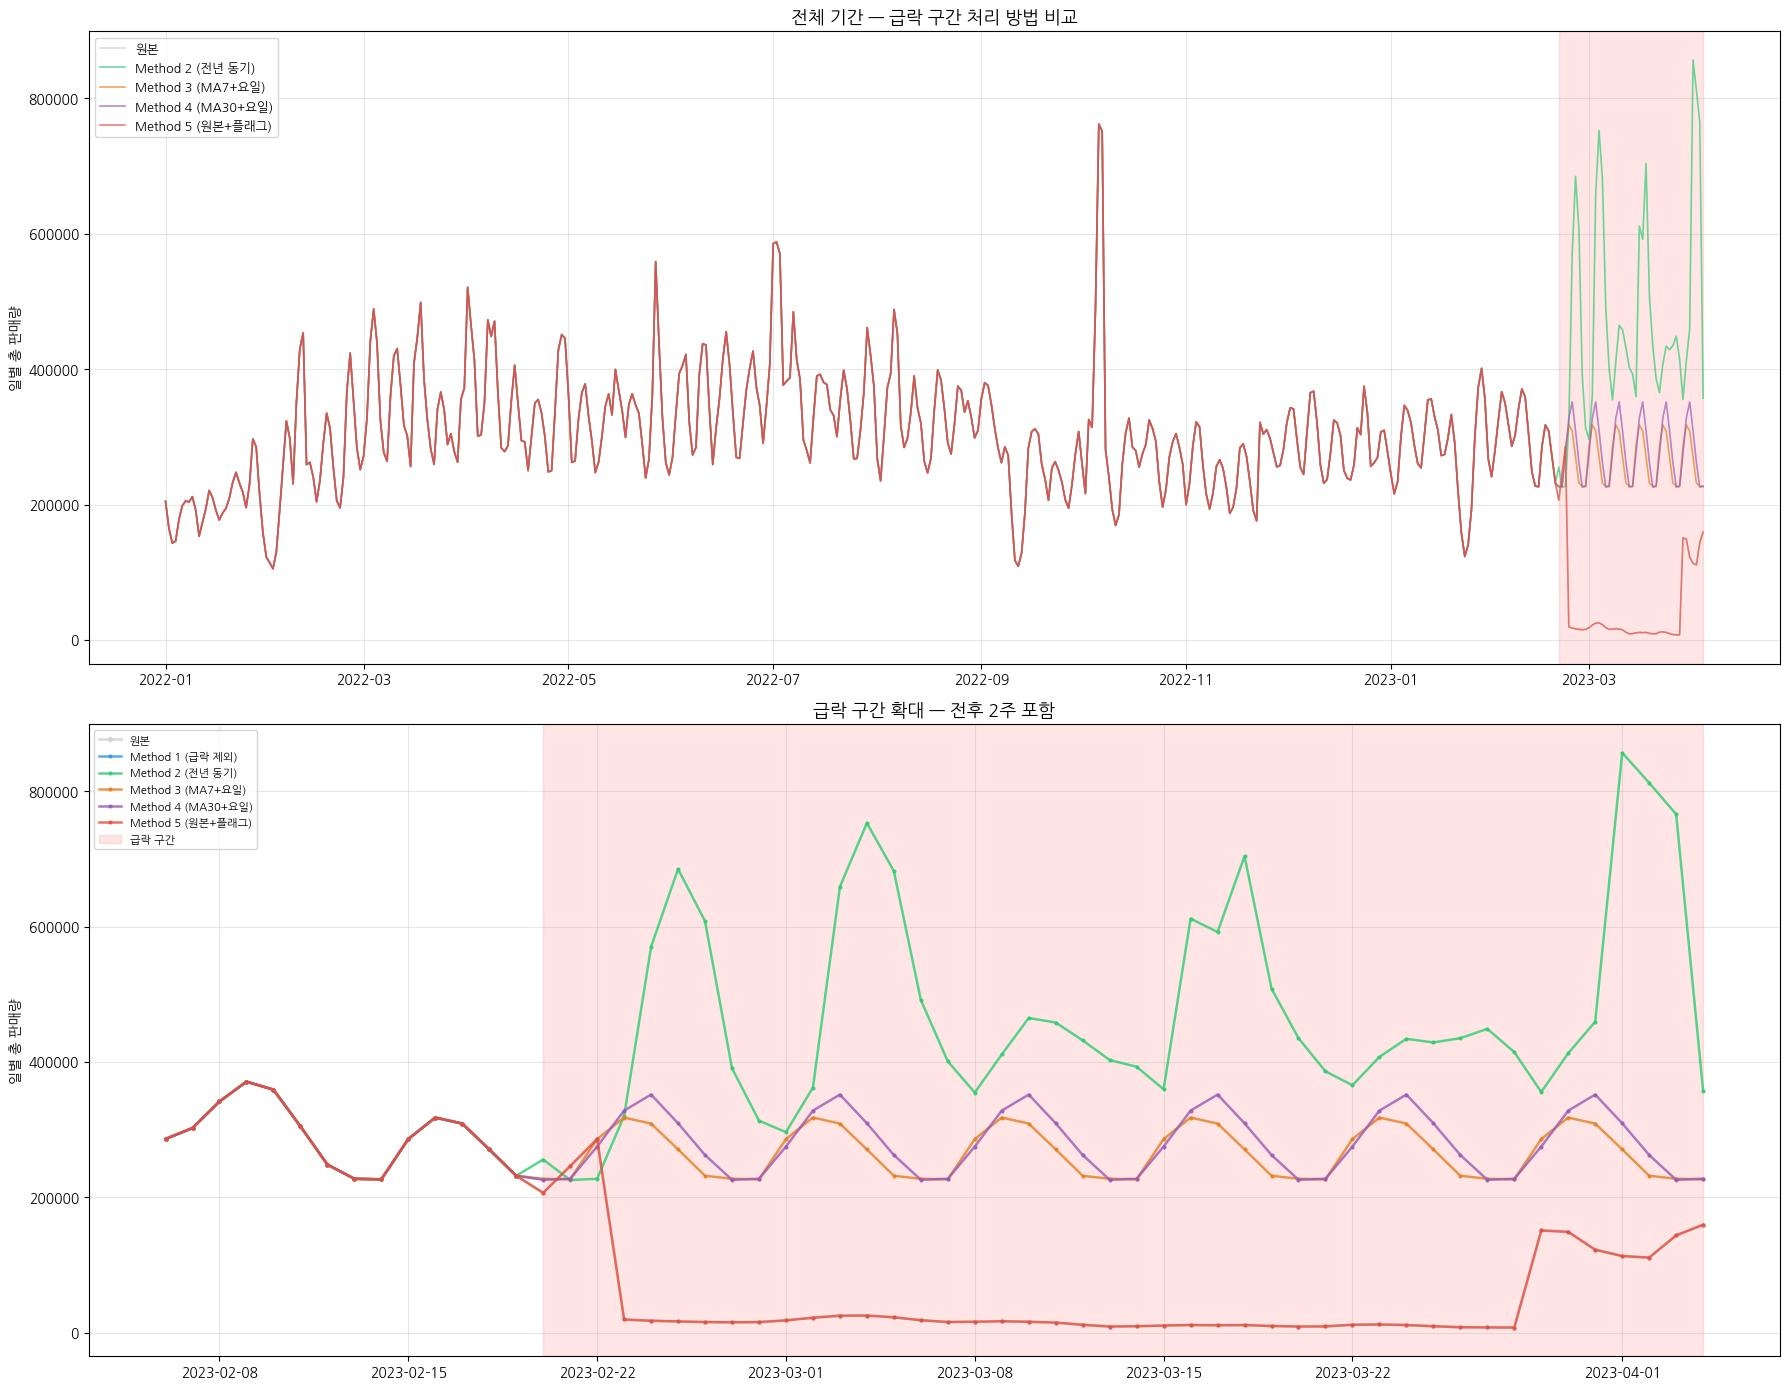


📊 급락 구간 내 일평균 판매량 비교
  원본                       :       49,274
  Method 1 (급락 제외)         : (해당 구간 제외됨)
  Method 2 (전년 동기)         :      470,567
  Method 3 (MA7+요일)        :      265,153
  Method 4 (MA30+요일)       :      280,223
  Method 5 (원본+플래그)        :       49,274
  정상 구간 평균                 :      305,103

→ 위 그래프와 수치를 비교한 뒤, 아래 셀에서 OUTLIER_METHOD 값을 선택하세요.


In [28]:
# ── 5가지 방법 결과 나란히 비교 시각화 ────────────────────────────────────
# 선택 전에 다섯 방법의 결과가 얼마나 다른지 눈으로 확인
results = {}

# Method 1: 급락 제외
t1, dc1 = apply_method1(train, DATE_COLS, CRASH_START, CRASH_END)
d1 = t1[dc1].sum(axis=0); d1.index = pd.to_datetime(dc1)
results['Method 1 (급락 제외)'] = (d1, '#3498db')

# Method 2: 전년 동기 복원 (성장률 cap 적용됨)
t2, dc2 = apply_method2(train, DATE_COLS, CRASH_START, CRASH_END)
d2 = t2[dc2].sum(axis=0); d2.index = pd.to_datetime(dc2)
results['Method 2 (전년 동기)'] = (d2, '#2ecc71')

# Method 3: 이동평균 7일 + 요일 보정
t3, dc3 = apply_method3(train, DATE_COLS, CRASH_START, CRASH_END)
d3 = t3[dc3].sum(axis=0); d3.index = pd.to_datetime(dc3)
results['Method 3 (MA7+요일)'] = (d3, '#e67e22')

# Method 4: 이동평균 30일 + 요일 보정
t4, dc4 = apply_method4(train, DATE_COLS, CRASH_START, CRASH_END)
d4 = t4[dc4].sum(axis=0); d4.index = pd.to_datetime(dc4)
results['Method 4 (MA30+요일)'] = (d4, '#9b59b6')

# Method 5: 원본 유지 + 플래그
t5, dc5, _ = apply_method5(train, DATE_COLS, CRASH_START, CRASH_END)
d5 = t5[dc5].sum(axis=0); d5.index = pd.to_datetime(dc5)
results['Method 5 (원본+플래그)'] = (d5, '#e74c3c')

# ── 그래프 2개: 전체 기간 + 급락 구간 확대 ─────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 14))

# 위: 전체 기간 (Method 1은 날짜가 빠져서 전체 비교에서 제외)
ax = axes[0]
ax.plot(daily_total.index, daily_total.values, color='lightgray', lw=1.2, label='원본', alpha=0.8)
for label, (series, color) in results.items():
    if 'Method 1' not in label:
        ax.plot(series.index, series.values, color=color, lw=1.2, alpha=0.7, label=label)
ax.axvspan(CRASH_START, CRASH_END, alpha=0.1, color='red')
ax.set_title('전체 기간 — 급락 구간 처리 방법 비교', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylabel('일별 총 판매량')

# 아래: 급락 구간 전후 확대 (전후 2주 포함)
ax = axes[1]
zoom_start = CRASH_START - pd.Timedelta(days=14)
zoom_end   = CRASH_END   + pd.Timedelta(days=14)
mask_orig  = (daily_total.index >= zoom_start) & (daily_total.index <= zoom_end)
ax.plot(daily_total.index[mask_orig], daily_total.values[mask_orig],
        color='lightgray', lw=2, label='원본', alpha=0.8, marker='o', markersize=3)
for label, (series, color) in results.items():
    mask = (series.index >= zoom_start) & (series.index <= zoom_end)
    ax.plot(series.index[mask], series.values[mask],
            color=color, lw=1.8, alpha=0.8, label=label, marker='o', markersize=2)
ax.axvspan(CRASH_START, CRASH_END, alpha=0.1, color='red', label='급락 구간')
ax.set_title('급락 구간 확대 — 전후 2주 포함', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
ax.set_ylabel('일별 총 판매량')

plt.tight_layout()
plt.show()

# ── 급락 구간 내 수치 비교 ────────────────────────────────────────────────
print()
print('=' * 65)
print('📊 급락 구간 내 일평균 판매량 비교')
print('=' * 65)
print(f'  {"원본":<25s}: {daily_total[crash_mask].mean():>12,.0f}')
for label, (series, color) in results.items():
    crash_vals = series[(series.index >= CRASH_START) & (series.index <= CRASH_END)]
    if len(crash_vals) > 0:
        print(f'  {label:<25s}: {crash_vals.mean():>12,.0f}')
    else:
        print(f'  {label:<25s}: (해당 구간 제외됨)')
print(f'  {"정상 구간 평균":<25s}: {normal_avg:>12,.0f}')
print()
print('→ 위 그래프와 수치를 비교한 뒤, 아래 셀에서 OUTLIER_METHOD 값을 선택하세요.')

#### ⚙️ 방법 선택 및 적용

위 비교 시각화를 확인한 뒤, 아래 셀에서 `OUTLIER_METHOD` 값을 변경하세요.  
아래 셀을 실행하면 선택한 방법이 실제로 적용됩니다.

* 5를 선택한 로직 : **가정이 가장 적기 때문**

* Method 2, 3, 4는 급락 구간에 **내가 만든 가짜 숫자**를 넣음
- Method 2: "작년 패턴이 올해와 비슷할 것이다"  ← 가정
- Method 3: "직전 7일이 대표적일 것이다"       ← 가정  
- Method 4: "직전 30일이 대표적일 것이다"      ← 가정

```
* 이 가정이 틀리면, 모델은 **실제로 존재하지 않았던 패턴을 "진짜"라고 학습** --> 아까 Method 2에서 성장률이 폭발한 게 그 예시
```
- Method 5: 원본 그대로 + "여긴 급락이야"라는 표시만 → 가정 없음. 모델이 직접 판단

==> 그래서 5로 모델링까지 돌려보고 outlier_method = 4로 다시 모델링 해보는 방법으로 해보려고 함

In [29]:
# ── 급락 구간 분석 ─────────────────────────────────────────────────────────
# ⚠️ CRASH_START, CRASH_END, daily_total 은 2-3에서 이미 정의됨
#
# ⚙️  방법 선택 (1~5 중 하나) — 비교 시각화를 본 뒤 변경하세요
OUTLIER_METHOD = 5   # ← 여기서 최종 선택

# ── 선택한 방법 실제 적용 ─────────────────────────────────────────────────
if OUTLIER_METHOD == 1:
    train_m, DATE_COLS_M = apply_method1(train, DATE_COLS, CRASH_START, CRASH_END)
    crash_flag_dict = {}
elif OUTLIER_METHOD == 2:
    train_m, DATE_COLS_M = apply_method2(train, DATE_COLS, CRASH_START, CRASH_END)
    crash_flag_dict = {}
elif OUTLIER_METHOD == 3:
    train_m, DATE_COLS_M = apply_method3(train, DATE_COLS, CRASH_START, CRASH_END)
    crash_flag_dict = {}
elif OUTLIER_METHOD == 4:
    train_m, DATE_COLS_M = apply_method4(train, DATE_COLS, CRASH_START, CRASH_END)
    crash_flag_dict = {}
else:  # Method 5
    train_m, DATE_COLS_M, crash_flag_dict = apply_method5(train, DATE_COLS, CRASH_START, CRASH_END)

print(f'\n✅ Method {OUTLIER_METHOD} 적용 완료  /  학습 날짜 수: {len(DATE_COLS_M)}일')

[Method 5] 원본 유지, is_post_crash 플래그 생성 (급락 후: 44일)

✅ Method 5 적용 완료  /  학습 날짜 수: 459일


### 3-1. Spike 클리핑 — 개별 제품 이상치 제거

📊 제품별 "최대값 ÷ 중앙값" 비율 분포
  분석 대상 제품 수  : 5,266개 (중앙값 > 0)
  제외된 제품 수     : 10,624개 (중앙값 = 0)

  비율 중앙값        : 8.7배
  비율 평균          : 28.9배
  비율 75%           : 17.8배
  비율 90%           : 40.8배
  비율 95%           : 71.3배
  비율 99%           : 240.7배
  비율 최대          : 16427.0배



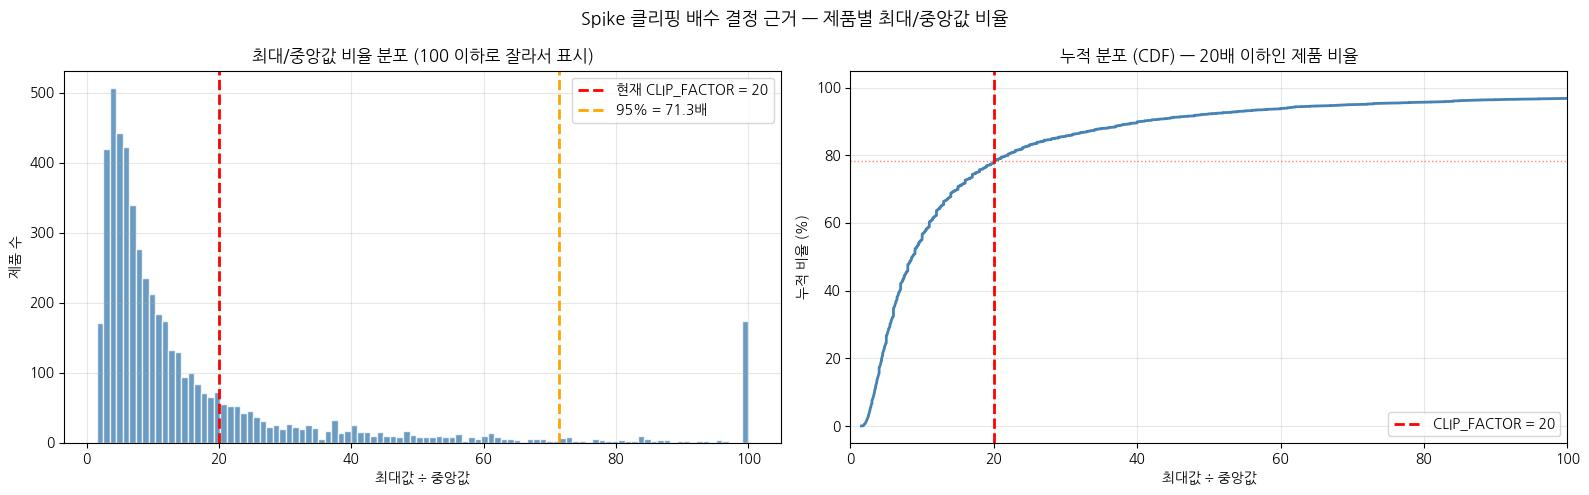

💡 CLIP_FACTOR = 20 기준:
   → 전체 제품의 78.3%가 이 범위 안에 있음
   → 21.7%의 제품만 클리핑됨

📌 참고: 95% 백분위수 = 71.3배
   → 이 값을 CLIP_FACTOR로 쓰면 5%만 잘리는 보수적 기준


In [30]:
# 중앙값 x 20이 맞을까? --> 제품별로 "최대값 ÷ 중앙값" 비율을 구해서 분포 확인
# 이 비율이 대부분의 제품에서 10 이하라면 → 20배 cap은 넉넉한 거고,
# 만약 정상 제품도 30~50배가 많다면 → 20배로 자르면 정상 이벤트까지 잘리는 거

# ── Spike 클리핑 배수 검증 — "중앙값 × N"의 N을 데이터 기반으로 결정 ────
# 제품별로 "최대 판매량 ÷ 중앙값(>0)" 비율을 계산해서
# 대부분의 제품이 어느 범위에 있는지 분포를 확인합니다.
# → 이 분포를 보고 CLIP_FACTOR(현재 20)가 적절한지 판단합니다.

qty_data = train_m[DATE_COLS_M].astype(float)

# 중앙값이 0인 제품은 비율 계산이 불가하므로 제외
medians = qty_data.median(axis=1)
maxvals = qty_data.max(axis=1)

# 중앙값 > 0인 제품만 대상
mask_valid = medians > 0
ratio = maxvals[mask_valid] / medians[mask_valid]

print('=' * 60)
print('📊 제품별 "최대값 ÷ 중앙값" 비율 분포')
print('=' * 60)
print(f'  분석 대상 제품 수  : {mask_valid.sum():,}개 (중앙값 > 0)')
print(f'  제외된 제품 수     : {(~mask_valid).sum():,}개 (중앙값 = 0)')
print()
print(f'  비율 중앙값        : {ratio.median():.1f}배')
print(f'  비율 평균          : {ratio.mean():.1f}배')
print(f'  비율 75%           : {ratio.quantile(0.75):.1f}배')
print(f'  비율 90%           : {ratio.quantile(0.90):.1f}배')
print(f'  비율 95%           : {ratio.quantile(0.95):.1f}배')
print(f'  비율 99%           : {ratio.quantile(0.99):.1f}배')
print(f'  비율 최대          : {ratio.max():.1f}배')
print()

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Spike 클리핑 배수 결정 근거 — 제품별 최대/중앙값 비율', fontsize=13, fontweight='bold')

# 왼쪽: 전체 분포 (히스토그램)
ax = axes[0]
ax.hist(ratio.clip(upper=100), bins=100, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(20, color='red', ls='--', lw=2, label=f'현재 CLIP_FACTOR = 20')
ax.axvline(ratio.quantile(0.95), color='orange', ls='--', lw=2,
           label=f'95% = {ratio.quantile(0.95):.1f}배')
ax.set_title('최대/중앙값 비율 분포 (100 이하로 잘라서 표시)')
ax.set_xlabel('최대값 ÷ 중앙값')
ax.set_ylabel('제품 수')
ax.legend()
ax.grid(alpha=0.3)

# 오른쪽: 누적 분포 (CDF) — "20배 이하인 제품이 몇 %인지" 직관적으로 보여줌
ax = axes[1]
sorted_ratio = np.sort(ratio.values)
cdf = np.arange(1, len(sorted_ratio) + 1) / len(sorted_ratio) * 100
ax.plot(sorted_ratio, cdf, color='steelblue', lw=2)
ax.axvline(20, color='red', ls='--', lw=2, label=f'CLIP_FACTOR = 20')
ax.axhline(ratio[ratio <= 20].count() / len(ratio) * 100,
           color='red', ls=':', lw=1, alpha=0.5)
ax.set_xlim(0, 100)
ax.set_title('누적 분포 (CDF) — 20배 이하인 제품 비율')
ax.set_xlabel('최대값 ÷ 중앙값')
ax.set_ylabel('누적 비율 (%)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 핵심 판단 수치
pct_under_20 = (ratio <= 20).mean() * 100
print(f'💡 CLIP_FACTOR = 20 기준:')
print(f'   → 전체 제품의 {pct_under_20:.1f}%가 이 범위 안에 있음')
print(f'   → {100 - pct_under_20:.1f}%의 제품만 클리핑됨')
print()
print(f'📌 참고: 95% 백분위수 = {ratio.quantile(0.95):.1f}배')
print(f'   → 이 값을 CLIP_FACTOR로 쓰면 5%만 잘리는 보수적 기준')

CLIP_FACTOR = 20:
  클리핑된 제품 수  : 8,472개 (53.3%)
  클리핑 후 최대값  : 38,384
  총 판매량 손실률  : 11.06%

CLIP_FACTOR = 40:
  클리핑된 제품 수  : 7,864개 (49.5%)
  클리핑 후 최대값  : 38,384
  총 판매량 손실률  : 8.37%

클리핑 전 최대값    : 200,420



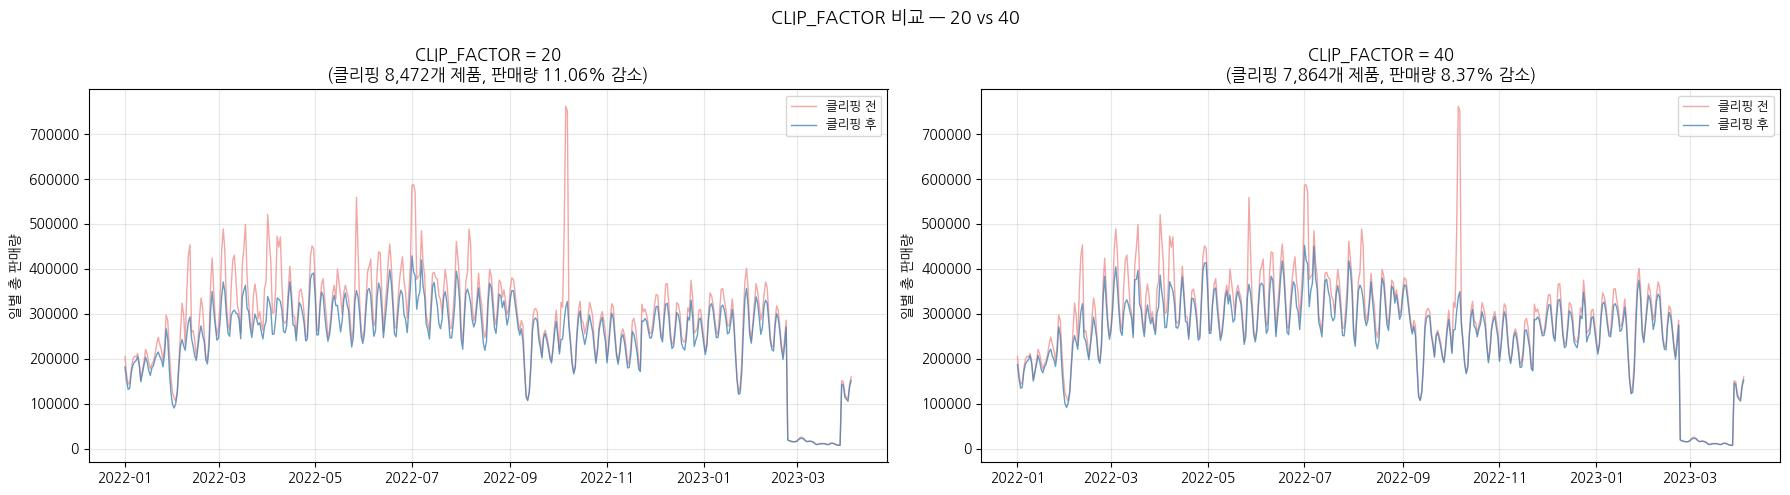

In [31]:
# ── CLIP_FACTOR 비교 — 20 vs 40 결과 차이 확인 ───────────────────────────
# 어느 쪽이 적절한지 수치와 시각화로 판단합니다.

qty_data = train_m[DATE_COLS_M].astype(float)
medians  = qty_data.median(axis=1)
q95      = qty_data.quantile(0.95, axis=1)
before_max = qty_data.max(axis=1)

results = {}
for factor in [20, 40]:
    upper = np.where(
        medians > 0,
        medians * factor,
        np.where(q95 > 0, q95, np.inf)
    )
    clipped   = qty_data.clip(upper=pd.Series(upper, index=qty_data.index), axis=0)
    after_max = clipped.max(axis=1)
    n_clipped = (before_max > after_max).sum()
    
    # 클리핑으로 잘린 총 판매량 (얼마나 깎였는지)
    total_before = qty_data.sum().sum()
    total_after  = clipped.sum().sum()
    lost_pct     = (total_before - total_after) / total_before * 100
    
    results[factor] = {
        'n_clipped': n_clipped,
        'max_after': after_max.max(),
        'lost_pct': lost_pct,
        'clipped_df': clipped
    }
    
    print(f'CLIP_FACTOR = {factor}:')
    print(f'  클리핑된 제품 수  : {n_clipped:,}개 ({n_clipped/len(qty_data)*100:.1f}%)')
    print(f'  클리핑 후 최대값  : {after_max.max():,.0f}')
    print(f'  총 판매량 손실률  : {lost_pct:.2f}%')
    print()

print(f'클리핑 전 최대값    : {before_max.max():,.0f}')
print()

# ── 시각화: 클리핑 전후 일별 총 판매량 비교 ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('CLIP_FACTOR 비교 — 20 vs 40', fontsize=13, fontweight='bold')

# 왼쪽: 일별 총 판매량 (급락 구간 전 정상 구간만)
for ax_idx, factor in enumerate([20, 40]):
    ax = axes[ax_idx]
    clipped = results[factor]['clipped_df']
    
    daily_before = qty_data.sum(axis=0)
    daily_after  = clipped.sum(axis=0)
    daily_before.index = pd.to_datetime(DATE_COLS_M)
    daily_after.index  = pd.to_datetime(DATE_COLS_M)
    
    ax.plot(daily_before.index, daily_before.values, color='lightcoral', lw=1, alpha=0.7, label='클리핑 전')
    ax.plot(daily_after.index, daily_after.values, color='steelblue', lw=1, alpha=0.8, label='클리핑 후')
    
    n = results[factor]['n_clipped']
    lost = results[factor]['lost_pct']
    ax.set_title(f'CLIP_FACTOR = {factor}\n(클리핑 {n:,}개 제품, 판매량 {lost:.2f}% 감소)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylabel('일별 총 판매량')

plt.tight_layout()
plt.show()

💬 3-1 해석 — CLIP_FACTOR 결정 근거

**검증 1: 제품별 최대/중앙값 비율 분포**

| 백분위수 | 비율 |
|----------|------|
| 중앙값 | 8.7배 |
| 75% | 17.8배 |
| 90% | 40.8배 |
| 95% | 71.3배 |
| 최대 | 16,427배 |

- 분석 대상: 중앙값 > 0인 5,266개 제품 (전체 15,890개 중 나머지 10,624개는 중앙값 = 0)
- 중앙값 = 0인 제품은 CLIP_FACTOR와 무관하게 95분위수로 클리핑됨

**검증 2: CLIP_FACTOR = 20 vs 40 비교**

| 항목 | 20 | 40 |
|------|-----|-----|
| 클리핑된 제품 수 | 8,472개 (53.3%) | 7,864개 (49.5%) |
| 총 판매량 손실률 | 11.06% | 8.37% |
| 클리핑 후 최대값 | 38,384 | 38,384 |

- 20 → 40으로 2배 늘려도 클리핑 제품 수는 608개(3.8%p)밖에 안 줄어듦
- 원인: 전체 15,890개 중 10,624개(중앙값=0)는 CLIP_FACTOR에 영향을 받지 않음
- 두 그래프 모두 Spike 피크가 동일하게 제거됨 (클리핑 후 최대값 동일)

**최종 결정: CLIP_FACTOR = 40**

- Spike 제거 효과는 20과 동일 (빨간 피크 모두 사라짐)
- 판매량 손실이 11% → 8%로 감소 (2.7%p 절약 = 학습 데이터 보존)
- 추가로 살리는 608개 제품은 비율 20~40배 구간 → 이벤트성 실제 판매일 가능성이 높아 보존이 유리
- 즉, "극단값 제거 효과는 유지하면서 데이터 손실을 줄이는" 보수적 기준

In [32]:
# ── Spike 클리핑 (벡터 연산 버전) ─────────────────────────────────────────
# 제품별 극단값을 상한선으로 깎아서, 이벤트 신호는 살리되
# 극단값이 loss를 지배하는 것만 방지합니다.
#
# 기존: for 루프로 15,890개 제품을 하나씩 처리 (느림)
# 개선: pandas 벡터 연산으로 한 번에 처리 (빠름)

CLIP_FACTOR = 40   # ← 위 검증 결과를 보고 필요시 변경

# 💡 네 말대로 맨 위에서 먼저 복사본을 만들고 시작한다!
train_clean = train_m.copy()
qty_data = train_clean[DATE_COLS_M].astype(float)

# ── 제품별 상한선 계산 ────────────────────────────────────────────────────
# 중앙값 > 0인 제품: 상한선 = 중앙값 × CLIP_FACTOR
# 중앙값 = 0인 제품: 상한선 = 95% 분위수 (거의 안 팔리는 제품용)
# 95% 분위수도 0인 제품: 상한선 = inf (클리핑 안 함, 어차피 거의 0)

medians = qty_data.median(axis=1)
q95     = qty_data.quantile(0.95, axis=1)

upper_limit = np.where(
    medians > 0,
    medians * CLIP_FACTOR,          # 일반 제품: 중앙값 × 20
    np.where(q95 > 0, q95, np.inf)  # 중앙값=0인 제품: 95분위 or 스킵
)

# ── 클리핑 적용 (벡터 연산) ───────────────────────────────────────────────
# 각 제품(행)마다 해당 상한선으로 clip
# .clip()에 axis=0으로 행별 상한선을 적용
before_max = qty_data.max(axis=1)
clipped    = qty_data.clip(upper=pd.Series(upper_limit, index=qty_data.index), axis=0)

# 클리핑 결과를 train_clean에 반영
train_clean = train_m.copy()
train_clean[DATE_COLS_M] = clipped

# ── 결과 요약 ─────────────────────────────────────────────────────────────
after_max     = clipped.max(axis=1)
clipped_count = (before_max > after_max).sum()

print('=' * 55)
print('📊 Spike 클리핑 결과')
print('=' * 55)
print(f'  CLIP_FACTOR       : {CLIP_FACTOR}배')
print(f'  클리핑된 제품 수  : {clipped_count:,}개')
print(f'  클리핑 전 최대값  : {before_max.max():,.0f}')
print(f'  클리핑 후 최대값  : {after_max.max():,.0f}')
print(f'  압축 비율         : {before_max.max() / max(after_max.max(), 1):,.1f}배 축소')
print()
print('✅ 원본: train_m  /  클린버전: train_clean')

📊 Spike 클리핑 결과
  CLIP_FACTOR       : 40배
  클리핑된 제품 수  : 7,864개
  클리핑 전 최대값  : 200,420
  클리핑 후 최대값  : 38,384
  압축 비율         : 5.2배 축소

✅ 원본: train_m  /  클린버전: train_clean


### 3-2. 단가(Price) 파생 — revenue ÷ qty

train.csv(판매량)와 sales.csv(매출액)를 나누어 제품별 일별 단가를 계산합니다.

| 상황 | 처리 |
|------|------|
| qty > 0 | price = revenue ÷ qty (실제 단가) |
| qty = 0 | NaN → ffill (직전 판매일의 단가를 이어받음) |
| ffill 후 남은 NaN | 제품별 중앙 단가로 채움 (첫 판매 전 구간, 3-4에서 마스킹되므로 실질 영향 없음) |

**왜 중앙값이 아니라 ffill인가:**  
중앙값은 과거 세일가와 현재 정상가의 평균이 들어가서, 안 팔린 날마다 가격이 출렁이는 가짜 노이즈가 생깁니다.  
ffill은 "어제 가격이 오늘도 유지된다"는 현실적인 가정이고, LSTM의 시계열 흐름을 깨뜨리지 않습니다.

In [33]:
# ── 단가 파생 ─────────────────────────────────────────────────────────────
# sales.csv = 매출액(revenue) / train.csv = 판매량(qty)
# → 단가 = revenue ÷ qty
# → qty=0인 날은 단가를 계산할 수 없으므로 NaN 처리 후 ffill로 채움

price_df = sales[META_COLS].copy()

# ── 1단계: qty > 0인 날만 단가 계산, 나머지는 NaN ─────────────────────
for col in DATE_COLS_M:
    price_df[col] = np.where(
        train_clean[col] > 0,
        sales[col] / train_clean[col],   # 실제 단가
        np.nan                            # 안 팔린 날은 NaN
    )

# ── 2단계: ffill — 직전 판매일의 단가를 이어받음 ──────────────────────
# 현실: 제품이 오늘 안 팔려도 가격표는 어제와 같다
# 중앙값 대신 ffill을 쓰는 이유:
#   - 중앙값: 과거 세일가 + 현재 정상가의 평균 → 실제 시점 가격과 동떨어짐
#   - ffill: 직전 가격 유지 → 시계열 흐름이 자연스럽고 LSTM에 노이즈 없음
price_df[DATE_COLS_M] = price_df[DATE_COLS_M].ffill(axis=1)

# ── 3단계: 안전장치 — ffill로도 안 채워지는 NaN은 제품별 중앙값 ──────
# 첫 판매 전 구간이 여기 해당하지만, 3-4 구조적 0 마스킹에서 빠지므로 실질 영향 없음
price_median = price_df[DATE_COLS_M].median(axis=1)
for col in DATE_COLS_M:
    price_df[col] = price_df[col].fillna(price_median)

# ── 결과 확인 ─────────────────────────────────────────────────────────────
nan_pct = price_df[DATE_COLS_M].isna().mean().mean()
print(f'NaN 비율 (최종): {nan_pct:.4%}')
print(f'단가 범위: {price_df[DATE_COLS_M].min().min():.0f} ~ {price_df[DATE_COLS_M].max().max():,.0f}')
print('✅ price_df 생성 완료 (ffill + 중앙값 폴백)')

NaN 비율 (최종): 0.5349%
단가 범위: 0 ~ 214,349,500
✅ price_df 생성 완료 (ffill + 중앙값 폴백)


In [34]:
# ── 단가 이상치 확인 ──────────────────────────────────────────────────────
price_vals = price_df[DATE_COLS_M].values.flatten()
price_vals = price_vals[~np.isnan(price_vals)]
price_vals = price_vals[price_vals > 0]

print('=' * 55)
print('📊 단가 분포 확인')
print('=' * 55)
print(f'  중앙값        : {np.median(price_vals):,.0f}원')
print(f'  평균          : {np.mean(price_vals):,.0f}원')
print(f'  75%           : {np.percentile(price_vals, 75):,.0f}원')
print(f'  90%           : {np.percentile(price_vals, 90):,.0f}원')
print(f'  95%           : {np.percentile(price_vals, 95):,.0f}원')
print(f'  99%           : {np.percentile(price_vals, 99):,.0f}원')
print(f'  최대          : {np.max(price_vals):,.0f}원')
print()

# 상위 극단값 제품 확인
print('📌 단가 상위 10개 (어떤 제품이 이상한지)')
price_max_per_product = price_df[DATE_COLS_M].max(axis=1)
top10 = price_max_per_product.nlargest(10)
for idx in top10.index:
    pid = price_df.loc[idx, 'ID']
    cat = price_df.loc[idx, '대분류']
    max_price = top10[idx]
    # 해당 제품의 qty와 revenue도 확인
    qty_vals = train_clean.loc[idx, DATE_COLS_M]
    rev_vals = sales.loc[idx, DATE_COLS_M]
    print(f'  {pid} [{cat}] 최대단가: {max_price:>15,.0f}원'
          f'  | qty범위: {qty_vals.min():.0f}~{qty_vals.max():.0f}'
          f'  | rev범위: {rev_vals.min():.0f}~{rev_vals.max():,.0f}')

# NaN 잔여 확인
nan_products = price_df[DATE_COLS_M].isna().all(axis=1).sum()
print(f'\n📌 전 기간 NaN인 제품 수: {nan_products}개 (= 한 번도 안 팔린 제품, 3-4에서 마스킹 예정)')

📊 단가 분포 확인
  중앙값        : 9,900원
  평균          : 19,779원
  75%           : 20,800원
  90%           : 38,520원
  95%           : 58,328원
  99%           : 165,000원
  최대          : 214,349,500원

📌 단가 상위 10개 (어떤 제품이 이상한지)
  11251 [B002-C001-0001] 최대단가:     214,349,500원  | qty범위: 0~0  | rev범위: 0~21,434,950
  11366 [B002-C001-0002] 최대단가:      34,825,000원  | qty범위: 0~1  | rev범위: 0~34,825,000
  13530 [B002-C001-0002] 최대단가:      15,266,250원  | qty범위: 0~1  | rev범위: 0~15,266,250
  14639 [B002-C001-0001] 최대단가:       8,257,000원  | qty범위: 0~3  | rev범위: 0~24,771,000
  1420 [B002-C001-0001] 최대단가:       7,899,050원  | qty범위: 0~2  | rev범위: 0~15,798,100
  6334 [B002-C001-0002] 최대단가:       5,300,952원  | qty범위: 0~2  | rev범위: 0~11,132,000
  11301 [B002-C001-0002] 최대단가:       4,980,000원  | qty범위: 0~0  | rev범위: 0~498,000
  7899 [B002-C001-0002] 최대단가:       4,798,000원  | qty범위: 0~0  | rev범위: 0~479,800
  7725 [B002-C001-0001] 최대단가:       4,775,902원  | qty범위: 0~6  | rev범위: 0~29,133,000
  11367 [B002-C001-0002] 최대

In [35]:
# ── 단가 클리핑 — 99% 백분위수 상한선 ─────────────────────────────────────
# 왜 필요한가:
#   99%의 제품은 단가 165,000원 이하인데, 최대값이 2.1억원
#   qty=1인 날에 revenue가 수천만 원인 경우 (B2B 대량 주문 등)
#   → 이 극단값이 모델 학습을 지배하는 것을 방지
#
# 왜 99% 백분위수인가:
#   - 95%로 자르면 정상적인 고가 제품까지 깎임 (95% = 58,328원)
#   - 99%는 165,000원 → 충분히 현실적인 고가 제품 가격
#   - 165,000원 초과는 전체의 1%뿐 → 데이터 손실 최소화

price_cap = price_df[DATE_COLS_M].quantile(0.99).median()
# ↑ 날짜별 99% 백분위수의 중앙값 → 안정적인 단일 cap 값

price_before_max = price_df[DATE_COLS_M].max().max()
price_df[DATE_COLS_M] = price_df[DATE_COLS_M].clip(upper=price_cap)
price_after_max = price_df[DATE_COLS_M].max().max()

print(f'단가 클리핑 완료:')
print(f'  cap 기준 (99%)    : {price_cap:,.0f}원')
print(f'  클리핑 전 최대값  : {price_before_max:,.0f}원')
print(f'  클리핑 후 최대값  : {price_after_max:,.0f}원')
print(f'  NaN 비율 (최종)   : {price_df[DATE_COLS_M].isna().mean().mean():.4%}')
print('✅ price_df 단가 클리핑 완료')

단가 클리핑 완료:
  cap 기준 (99%)    : 164,960원
  클리핑 전 최대값  : 214,349,500원
  클리핑 후 최대값  : 164,960원
  NaN 비율 (최종)   : 0.5349%
✅ price_df 단가 클리핑 완료


### 3-3. Wide → Long 변환 + 체크포인트

현재 데이터는 **Wide 포맷** (제품 1행 × 날짜 459열) 입니다.  
LSTM 학습을 위해 **Long 포맷** (제품×날짜 1행) 으로 변환합니다.

```
Wide:  [제품A | 2022-01-01 | 2022-01-02 | ... ]  →  1행
Long:  [제품A | 2022-01-01 | qty=10     ]  →  1행
       [제품A | 2022-01-02 | qty=5      ]  →  1행
```

In [36]:
# ── Wide → Long 변환 ───────────────────────────────────────────────────────
print('Wide → Long 변환 중... (약 30초~1분 소요)')

df = pd.melt(
    train_clean,
    id_vars    = META_COLS,
    value_vars = DATE_COLS_M,
    var_name   = 'date',
    value_name = 'qty'
)

price_long = pd.melt(
    price_df,
    id_vars    = META_COLS,
    value_vars = DATE_COLS_M,
    var_name   = 'date',
    value_name = 'price'
)

df['date']         = pd.to_datetime(df['date'])
price_long['date'] = pd.to_datetime(price_long['date'])

# qty + price 병합
df = df.merge(price_long[['ID', 'date', 'price']], on=['ID', 'date'], how='left')
df = df.sort_values(['ID', 'date']).reset_index(drop=True)

# Method 5일 때 is_post_crash 플래그 병합
if OUTLIER_METHOD == 5 and crash_flag_dict:
    flag_df = pd.DataFrame([
        {'date': pd.Timestamp(c), 'is_post_crash': v}
        for c, v in crash_flag_dict.items()
    ])
    df = df.merge(flag_df, on='date', how='left')
    df['is_post_crash'] = df['is_post_crash'].fillna(0).astype(int)
    print(f'  is_post_crash 플래그 추가 (급락후=1): {df["is_post_crash"].sum():,}행')
else:
    df['is_post_crash'] = 0

print(f'변환 완료: {train_clean.shape} → {df.shape}')

Wide → Long 변환 중... (약 30초~1분 소요)
  is_post_crash 플래그 추가 (급락후=1): 699,160행
변환 완료: (15890, 467) → (7293510, 10)


In [37]:
# ── 중간 체크포인트 — 현재 df 상태 확인 ──────────────────────────────────
print('=' * 55)
print('📋 Wide → Long 변환 후 df 상태')
print('=' * 55)
print(f'  Shape     : {df.shape}')
print(f'  컬럼 목록  : {list(df.columns)}')
print(f'  날짜 범위  : {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'  제품 수    : {df["ID"].nunique():,}개')
print(f'  qty 결측치 : {df["qty"].isna().sum()}')
print()
df.head(3)

📋 Wide → Long 변환 후 df 상태
  Shape     : (7293510, 10)
  컬럼 목록  : ['ID', '제품', '대분류', '중분류', '소분류', '브랜드', 'date', 'qty', 'price', 'is_post_crash']
  날짜 범위  : 2022-01-01 ~ 2023-04-04
  제품 수    : 15,890개
  qty 결측치 : 0



,ID,제품,대분류,중분류,소분류,브랜드,date,qty,price,is_post_crash
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-01,0.0,5600.0,0
1,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-02,0.0,5600.0,0
2,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-03,0.0,5600.0,0


### 3-4. 구조적 0 마스킹

In [38]:
# ── 구조적 0 마스킹 ────────────────────────────────────────────────────────
# ⚠️ first_sale_date, last_sale_date, has_sales 는 EDA 2-6에서 생성됨
#    → EDA 셀을 먼저 실행해야 이 셀이 정상 작동합니다.

df = df.merge(
    train[['ID', 'first_sale_date', 'last_sale_date']],
    on='ID', how='left'
)

DISC_BUFFER = 90  # 마지막 판매일 이후 90일까지는 "진짜 0"으로 취급, 이후는 구조적 0

df['is_structural_zero'] = (
    (df['date'] < df['first_sale_date']) |
    (df['date'] > df['last_sale_date'] + pd.Timedelta(days=DISC_BUFFER))
)

print('=' * 55)
print('📊 구조적 0 마스킹 결과')
print('=' * 55)
print(f'  전체 행 수                : {len(df):>10,}')
print(f'  구조적 0 마스킹 행 수     : {df["is_structural_zero"].sum():>10,}')
useful_rows = ~df['is_structural_zero']
print(f'  학습 활용 가능 행         : {useful_rows.sum():>10,}')
print(f'  전체 대비 비율            : {useful_rows.mean():.1%}')
print()
print(f'  한 번도 안 팔린 제품 수   : {(~has_sales).sum():,}개')
print('  → 이 제품들은 first_sale_date = NaT → 전체 기간이 구조적 0으로 마스킹됨')

📊 구조적 0 마스킹 결과
  전체 행 수                :  7,293,510
  구조적 0 마스킹 행 수     :  2,216,596
  학습 활용 가능 행         :  5,076,914
  전체 대비 비율            : 69.6%

  한 번도 안 팔린 제품 수   : 85개
  → 이 제품들은 first_sale_date = NaT → 전체 기간이 구조적 0으로 마스킹됨


### 3-5. 카테고리 인코딩 — 텍스트 → 숫자

### 🔧 함수/객체 선언 — `LabelEncoder` (le_dict)

카테고리 텍스트를 숫자로 변환하는 `LabelEncoder` 객체들입니다.  
`le_dict`에 저장해 두면 나중에 예측 결과를 원래 이름으로 **역변환**할 때 사용합니다.

In [39]:
from sklearn.preprocessing import LabelEncoder

# ── LabelEncoder 카테고리 인코딩 ──────────────────────────────────────────
# 딥러닝 모델은 텍스트를 그대로 받을 수 없음 → 숫자로 변환 필요
# LabelEncoder: '대1' → 0, '대2' → 1, ... 식으로 정수 부여
le_dict = {}

for col in ['대분류', '중분류', '소분류', '브랜드']:
    le = LabelEncoder()
    df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
    le_dict[col]     = le
    print(f'  {col:5s}: {len(le.classes_):>5,}개 클래스 → 0~{len(le.classes_)-1}')

le_product = LabelEncoder()
df['product_enc'] = le_product.fit_transform(df['ID'].astype(str))
le_dict['product'] = le_product
print(f"  {'제품':5s}: {len(le_product.classes_):>5,}개 클래스 인코딩")
print('\n✅ le_dict에 각 LabelEncoder 저장 완료 (예측 시 역변환에 사용)')

  대분류  :     5개 클래스 → 0~4
  중분류  :    11개 클래스 → 0~10
  소분류  :    53개 클래스 → 0~52
  브랜드  : 3,170개 클래스 → 0~3169
  제품   : 15,890개 클래스 인코딩

✅ le_dict에 각 LabelEncoder 저장 완료 (예측 시 역변환에 사용)


### 3-6. 브랜드 검색량 병합 — kw_log / kw_lag_1 / kw_lag_3

🔧 파생 변수 안내

| 변수명 | 계산 방법 | 의미 |
|--------|----------|------|
| `kw_log` | log1p(kw_cnt) | 당일 검색량 (log 변환) |
| `kw_lag_1` | kw_log를 1일 shift | 하루 전 검색량 |
| `kw_lag_3` | kw_log를 3일 shift | 3일 전 검색량 |

In [ ]:
✅✅ 수정 : kw_log = 0, kw_lag_1 = bfill 처리하기

# ── 검색량 처리 및 병합 ────────────────────────────────────────────────────
# 흐름: kw_cnt → 99% cap 클리핑 → log1p → kw_log → shift → lag 피처

# 1. Wide → Long 변환
kw_long = pd.melt(
    keyword,
    id_vars    = ['브랜드'],
    value_vars = KW_COLS,
    var_name   = 'date',
    value_name = 'kw_cnt'
)
kw_long['date']   = pd.to_datetime(kw_long['date'])
kw_long['kw_cnt'] = kw_long['kw_cnt'].fillna(0)

# 2. 브랜드별 99% cap 클리핑 → 극단 이상치 제거
cap_by_brand = kw_long.groupby('브랜드')['kw_cnt'].quantile(0.99)
kw_long = kw_long.join(cap_by_brand.rename('cap'), on='브랜드')
kw_long['kw_cnt'] = kw_long[['kw_cnt', 'cap']].min(axis=1)
kw_long.drop(columns=['cap'], inplace=True)

# 3. log1p 변환
kw_long['kw_log'] = np.log1p(kw_long['kw_cnt'])

# 4. 브랜드 내 시간순 정렬 후 shift → lag 피처
# lag_2 제외: lag_1과 정보 중복이 크고 lag_3로 충분히 커버
kw_long = kw_long.sort_values(['브랜드', 'date']).reset_index(drop=True)
kw_long['kw_lag_1'] = kw_long.groupby('브랜드')['kw_log'].shift(1).fillna(0)
kw_long['kw_lag_3'] = kw_long.groupby('브랜드')['kw_log'].shift(3).fillna(0)

# 5. df에 병합
df = df.merge(
    kw_long[['브랜드', 'date', 'kw_log', 'kw_lag_1', 'kw_lag_3']],
    on=['브랜드', 'date'], how='left'
)
df[['kw_log', 'kw_lag_1', 'kw_lag_3']] = df[['kw_log', 'kw_lag_1', 'kw_lag_3']].fillna(0)

print(f'kw_log    NaN: {df["kw_log"].isna().sum()}')
print(f'kw_lag_1  NaN: {df["kw_lag_1"].isna().sum()}')
print(f'kw_lag_3  NaN: {df["kw_lag_3"].isna().sum()}')
print(f'kw_log > 0 비율: {(df["kw_log"] > 0).mean():.1%}')
print('\n✅ 검색량 피처 3개 추가 완료: kw_log, kw_lag_1, kw_lag_3')

kw_log    NaN: 0
kw_lag_1  NaN: 0
kw_lag_3  NaN: 0
kw_log > 0 비율: 77.3%

✅ 검색량 피처 3개 추가 완료: kw_log, kw_lag_1, kw_lag_3


### 3-7. Product Info 특성 (선택적 / on & off)
`product_info.csv`에서 제품 특성 텍스트를 파싱해 범주형 피처로 추가하기

**현재 상태: ⏸️ 비활성화 (`USE_PRODUCT_INFO = False`)**

| 항목 | 내용 |
|------|------|
| 비활성화 사유 | 매칭률 65.9% (5,398개 제품 정보 없음), 텍스트 비정형 |
| 활성화 시점 | 모델 baseline 성능 확인 후, 피처 추가로 개선 필요할 때 |
| 활성화 방법 | `USE_PRODUCT_INFO = True`로 변경 후 이 셀부터 재실행 |

**추출 대상 키 (5개):**

| 키 | 고유값 | 피처 활용 이유 |
|----|--------|---------------|
| 구성 | 본품/리필/본품+리필 | 재구매 주기가 달라 판매 패턴에 직접 영향 |
| 피부타입 | 8개 | 가장 깔끔한 범주형, 타겟 고객층 구분 |
| 제품타입 | 34개 | 정/캡슐/분말 등 제품 형태 정보 |
| 제품형태 | 29개 | 펌프형/크림형 등 제품타입과 보완적 |
| 섭취대상 | 5개 (그룹화) | 성인남녀/유아/여성/남성/임산부 |

In [41]:
# ── product_info 구조 확인 ────────────────────────────────────────────────
print('=' * 55)
print('📊 product_info.csv 구조')
print('=' * 55)
print(f'  Shape: {product.shape}')
print(f'  컬럼: {list(product.columns)}')
print()

# 각 컬럼별 정보
for col in product.columns:
    nunique = product[col].nunique()
    dtype = product[col].dtype
    null_pct = product[col].isna().mean() * 100
    print(f'  {col:<20s} | 타입: {str(dtype):<10s} | 고유값: {nunique:>6,}개 | 결측: {null_pct:.1f}%')
    # 고유값이 10개 이하면 값 목록도 출력
    if nunique <= 10:
        print(f'    → 값: {sorted(product[col].dropna().unique())}')

print()
product.head(3)

📊 product_info.csv 구조
  Shape: (12778, 2)
  컬럼: ['제품', '제품특성']

  제품                   | 타입: str        | 고유값: 12,778개 | 결측: 0.0%
  제품특성                 | 타입: str        | 고유값: 12,195개 | 결측: 0.0%



,제품,제품특성
0,B002-03509-00001,제품유형:일반식품 콜라겐 펩타이드:1000mg 종류:어류 분자량:300Da 섭취대상...
1,B002-02376-00001,700mg x 28정
2,B002-03735-00001,제품타입:정 섭취방법:물과 함께 섭취대상:성인남녀 섭취횟수:하루 두 번 1일 총 섭...


In [42]:
# ── 제품특성 텍스트 구조 분석 ─────────────────────────────────────────────
# "제품유형:일반식품 콜라겐 펩타이드:1000mg" 같은 텍스트에서
# 어떤 키들이 있고, 각 키에 어떤 값이 들어있는지 파악

import re
from collections import Counter

# 1. 키:값 패턴 추출
all_keys = []
sample_pairs = []

for text in product['제품특성'].dropna():
    # "키:값" 패턴 찾기
    pairs = re.findall(r'(\S+?):(\S+)', str(text))
    for k, v in pairs:
        all_keys.append(k)
        sample_pairs.append((k, v))

# 2. 키 빈도수 상위 20개
key_counts = Counter(all_keys)
print('=' * 60)
print('📊 제품특성 — 키(Key) 빈도수 상위 20개')
print('=' * 60)
for key, count in key_counts.most_common(20):
    pct = count / len(product) * 100
    print(f'  {key:<20s}: {count:>6,}개 ({pct:>5.1f}%)')

# 3. 상위 10개 키의 고유값 확인
print()
print('=' * 60)
print('📊 상위 10개 키의 고유값 (각 최대 10개)')
print('=' * 60)
top10_keys = [k for k, _ in key_counts.most_common(10)]
key_values = {k: [] for k in top10_keys}
for k, v in sample_pairs:
    if k in key_values:
        key_values[k].append(v)

for key in top10_keys:
    vals = Counter(key_values[key])
    n_unique = len(vals)
    top_vals = vals.most_common(10)
    print(f'\n  [{key}] 고유값 {n_unique}개:')
    for val, cnt in top_vals:
        print(f'    {val:<30s} ({cnt:,}개)')

# 4. 매칭 확인 — train의 제품과 product_info의 제품이 얼마나 겹치는지
train_products = set(train['제품'].unique())
info_products = set(product['제품'].unique())
matched = train_products & info_products
print(f'\n📌 매칭 현황:')
print(f'  train 제품 수       : {len(train_products):,}개')
print(f'  product_info 제품 수: {len(info_products):,}개')
print(f'  겹치는 제품 수      : {len(matched):,}개 ({len(matched)/len(train_products)*100:.1f}%)')
print(f'  매칭 안 되는 제품   : {len(train_products - info_products):,}개')

📊 제품특성 — 키(Key) 빈도수 상위 20개
  원료명(식약처고시)          : 29,469개 (230.6%)
  세부제품특징              : 23,197개 (181.5%)
  특징                  : 22,677개 (177.5%)
  주요제품특징              : 21,759개 (170.3%)
  용량                  : 17,478개 (136.8%)
  기능                  : 16,219개 (126.9%)
  무첨가                 : 10,111개 ( 79.1%)
  섭취방법                :  9,434개 ( 73.8%)
  종류                  :  9,179개 ( 71.8%)
  섭취횟수                :  9,144개 ( 71.6%)
  섭취대상                :  9,095개 ( 71.2%)
  섭취량                 :  8,906개 ( 69.7%)
  제품용량                :  8,408개 ( 65.8%)
  구성                  :  8,273개 ( 64.7%)
  타입                  :  6,878개 ( 53.8%)
  기능성(식약처인증)          :  6,813개 ( 53.3%)
  제품타입                :  6,799개 ( 53.2%)
  형태                  :  6,443개 ( 50.4%)
  제품형태                :  5,738개 ( 44.9%)
  피부타입                :  5,180개 ( 40.5%)

📊 상위 10개 키의 고유값 (각 최대 10개)

  [원료명(식약처고시)] 고유값 138개:
    비타민D                           (2,177개)
    아연                             (2,153개)
    비타민E   

* **문제 3가지**

| 항목 | 내용 |
|------|------|
| 비활성화 사유 | 매칭률 65.9% (5,398개 제품 정보 없음), 텍스트 비정형 |
| 활성화 시점 | 모델 baseline 성능 확인 후, 피처 추가로 개선 필요할 때 |
| 활성화 방법 | `USE_PRODUCT_INFO = True`로 변경 후 이 셀부터 재실행 |

In [43]:
# product_info : True로 바꾸면 활성화
USE_PRODUCT_INFO = False

In [44]:
# ── 상위 10개 키의 고유값 수 + 샘플 ──────────────────────────────────────
import re
from collections import Counter

top10_keys = ['종류', '타입', '제품타입', '형태', '제품형태', 
              '섭취대상', '피부타입', '기능', '무첨가', '구성']

key_values = {k: [] for k in top10_keys}
for text in product['제품특성'].dropna():
    pairs = re.findall(r'(\S+?):(\S+)', str(text))
    for k, v in pairs:
        if k in key_values:
            key_values[k].append(v)

for key in top10_keys:
    vals = Counter(key_values[key])
    n_unique = len(vals)
    top5 = vals.most_common(5)
    top5_str = ' / '.join(f'{v}({c:,})' for v, c in top5)
    print(f'[{key}] 고유값 {n_unique}개 → 상위5: {top5_str}')

[종류] 고유값 216개 → 상위5: 일반형(900) / 두루마리(880) / 농축액(629) / 일반분유(583) / 갑티슈(482)
[타입] 고유값 52개 → 상위5: 엠보싱(1,645) / 일반샴푸(1,450) / 팬티형(1,040) / 밴드형(561) / 탈모샴푸(497)
[제품타입] 고유값 34개 → 상위5: 정(2,086) / 캡슐(1,594) / 분말(1,021) / 날개형(719) / 일자형(283)
[형태] 고유값 115개 → 상위5: 액상형(3,156) / 가루형(589) / 캡형(298) / 캡슐형(245) / 스프레이형(234)
[제품형태] 고유값 29개 → 상위5: 펌프형(2,232) / 분말(642) / 크림형(579) / 리퀴드형(459) / 오일형(350)
[섭취대상] 고유값 67개 → 상위5: 성인남녀(7,127) / 유아/청소년(924) / 성인여성(370) / 성인남성(200) / 임산부(120)
[피부타입] 고유값 8개 → 상위5: 모든피부용(4,686) / 건성(166) / 민감성(132) / 지성(63) / 중건성(51)
[기능] 고유값 139개 → 상위5: 샘방지(1,261) / 오줌(1,219) / 구취제거(1,105) / 구강청결(1,082) / 늘어나는(1,065)
[무첨가] 고유값 59개 → 상위5: 무파라벤(1,466) / 저자극(1,441) / 무색소(918) / 무방부제(772) / 오일프리(548)
[구성] 고유값 68개 → 상위5: 본품(5,376) / 리필(1,699) / 본품+리필(675) / 캡리필(112) / 본품,(53)


**추출 대상 키 (5개):**

| 키 | 고유값 | 피처 활용 이유 |
|----|--------|---------------|
| 구성 | 본품/리필/본품+리필 | 재구매 주기가 달라 판매 패턴에 직접 영향 |
| 피부타입 | 8개 | 가장 깔끔한 범주형, 타겟 고객층 구분 |
| 제품타입 | 34개 | 정/캡슐/분말 등 제품 형태 정보 |
| 제품형태 | 29개 | 펌프형/크림형 등 제품타입과 보완적 |
| 섭취대상 | 5개 (그룹화) | 성인남녀/유아/여성/남성/임산부 |



In [45]:
# ── Product Info 특성 추가 (선택적) ───────────────────────────────────────
# ⚙️ 아래 플래그를 True로 바꾸면 활성화됩니다
USE_PRODUCT_INFO = False   # ← 모델 성능 보고 필요하면 True로 변경

if USE_PRODUCT_INFO:
    import re

    # ── 1단계: 텍스트에서 키:값 추출 함수 ─────────────────────────────────
    def extract_key(text, key):
        """제품특성 텍스트에서 특정 키의 값을 추출"""
        match = re.search(rf'{key}:(\S+)', str(text))
        return match.group(1) if match else None

    # ── 2단계: 5개 피처 추출 ──────────────────────────────────────────────
    target_keys = ['구성', '피부타입', '제품타입', '제품형태', '섭취대상']

    for key in target_keys:
        col_name = f'prod_{key}'
        product[col_name] = product['제품특성'].apply(lambda x: extract_key(x, key))

    # ── 3단계: 섭취대상 그룹화 (67개 → 5개) ──────────────────────────────
    def group_target(val):
        """섭취대상을 5개 그룹으로 축소"""
        if val is None:
            return 'unknown'
        val = str(val)
        if '임산부' in val:
            return '임산부'
        elif '유아' in val or '청소년' in val or '어린이' in val:
            return '유아청소년'
        elif '여성' in val:
            return '성인여성'
        elif '남성' in val:
            return '성인남성'
        elif '남녀' in val or '성인' in val:
            return '성인남녀'
        else:
            return 'other'

    product['prod_섭취대상'] = product['prod_섭취대상'].apply(group_target)

    # ── 4단계: 구성 그룹화 (68개 → 3개) ──────────────────────────────────
    def group_composition(val):
        """구성을 3개 그룹으로 축소"""
        if val is None:
            return 'unknown'
        val = str(val)
        if '리필' in val and '본품' in val:
            return '본품+리필'
        elif '리필' in val:
            return '리필'
        elif '본품' in val:
            return '본품'
        else:
            return 'other'

    product['prod_구성'] = product['prod_구성'].apply(group_composition)

    # ── 5단계: df에 병합 ─────────────────────────────────────────────────
    prod_features = ['제품'] + [f'prod_{k}' for k in target_keys]
    df = df.merge(product[prod_features], on='제품', how='left')

    # ── 6단계: LabelEncoder 인코딩 ───────────────────────────────────────
    for key in target_keys:
        col = f'prod_{key}'
        df[col] = df[col].fillna('unknown')   # 매칭 안 되는 34.1% → 'unknown'
        le = LabelEncoder()
        df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le
        print(f'  {col:<15s}: {len(le.classes_):>3}개 클래스 → 0~{len(le.classes_)-1}')

    print(f'\n✅ Product Info 피처 {len(target_keys)}개 추가 완료')
    print(f'  매칭률: {(df["prod_구성"] != "unknown").mean():.1%}')

else:
    print('⏸️ USE_PRODUCT_INFO = False → Product Info 피처 스킵')
    print('  → 모델 성능 확인 후 필요 시 True로 변경하세요')

⏸️ USE_PRODUCT_INFO = False → Product Info 피처 스킵
  → 모델 성능 확인 후 필요 시 True로 변경하세요


### 3-7. 최종 df 확인

In [46]:
# ── 최종 전처리 완료 요약 ─────────────────────────────────────────────────
print('=' * 60)
print('✅ STEP 3 전처리 완료!')
print('=' * 60)
print(f'  최종 df shape  : {df.shape}')
print(f'  날짜 범위      : {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'  제품 수        : {df["ID"].nunique():,}개')
print(f'  qty 결측치     : {df["qty"].isna().sum()}')
print()

print('=' * 60)
print('📋 최종 피처 목록')
print('=' * 60)
feature_groups = {
    '식별자'      : ['ID', 'date'],
    '타겟'        : ['qty'],
    '카테고리'    : ['대분류_enc', '중분류_enc', '소분류_enc', '브랜드_enc', 'product_enc'],
    '가격'        : ['price'],
    '검색량'      : ['kw_log', 'kw_lag_1', 'kw_lag_3'],
    '마스크/플래그': ['is_structural_zero', 'is_post_crash'],
}
for group, cols in feature_groups.items():
    avail = [c for c in cols if c in df.columns]
    print(f'  [{group}] {avail}')

print()
df.head(3)

✅ STEP 3 전처리 완료!
  최종 df shape  : (7293510, 21)
  날짜 범위      : 2022-01-01 ~ 2023-04-04
  제품 수        : 15,890개
  qty 결측치     : 0

📋 최종 피처 목록
  [식별자] ['ID', 'date']
  [타겟] ['qty']
  [카테고리] ['대분류_enc', '중분류_enc', '소분류_enc', '브랜드_enc', 'product_enc']
  [가격] ['price']
  [검색량] ['kw_log', 'kw_lag_1', 'kw_lag_3']
  [마스크/플래그] ['is_structural_zero', 'is_post_crash']



,ID,제품,대분류,중분류,소분류,브랜드,date,qty,price,is_post_crash,...,last_sale_date,is_structural_zero,대분류_enc,중분류_enc,소분류_enc,브랜드_enc,product_enc,kw_log,kw_lag_1,kw_lag_3
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-01,0.0,5600.0,0,...,2023-02-10,True,1,6,37,0,0,0.610477,0.000000,0.0
1,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-02,0.0,5600.0,0,...,2023-02-10,True,1,6,37,0,0,0.649106,0.610477,0.0
2,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-03,0.0,5600.0,0,...,2023-02-10,True,1,6,37,0,0,0.896304,0.649106,0.0


---
## STEP 4 — 특성공학 (Feature Engineering)
> EDA에서 발견한 패턴을 모델이 직접 활용할 수 있는 숫자(피처)로 만드는 과정  
> STEP 3에서 데이터를 '깨끗하게' 만들고, STEP 4에서는 '똑똑하게' 만듦  

| # | 피처 그룹 | 생성할 피처 | EDA 근거 |
|---|----------|-----------|----------|
| 4-1 | log 변환 | qty_log | EDA 2-2: Long Tail → log1p로 분포 정규화 |
| 4-2 | 날짜 피처 | day_of_week, month, quarter | EDA 2-4: 요일·월별 판매 패턴 |
| 4-3 | 공휴일 피처 | is_holiday, days_to_holiday | EDA 2-13: 명절 전 스파이크, 중 급락 |
| 4-4 | Lag 피처 | lag_1, lag_7 | EDA 2-8: ACF에서 Lag 1, 7 유의미 |
| 4-5 | Rolling 피처 | rolling_7_mean, rolling_30_mean | EDA 2-3: 이동평균 트렌드 |
| 4-6 | 최종 확인 | — | 피처 목록 + 결측치 점검 |


### 4-1. log1p 변환 — qty → qty_log

EDA 2-2에서 확인한 Long Tail 분포를 정규화합니다.

| 비교 | 변환 전 (qty) | 변환 후 (qty_log) |
|------|-------------|------------------|
| 범위 | 0 ~ 200,000+ | 0 ~ 12 |
| 분포 | 극단적 Long Tail | 종 모양에 근접 |
| 인기 제품 영향력 | 학습 지배 | 균등화됨 |

**왜 지금 하는가 (Dataset 클래스가 아니라 여기서):**  
이후 lag/rolling 피처를 log 스케일로 계산하기 위해서입니다.  
원본 qty로 lag를 계산하면 "어제 200,000 → 오늘 100" 같은 극단적 차이가 그대로 들어가지만,  
log 스케일에서는 "어제 12.2 → 오늘 4.6"으로 완화됩니다.  
rolling_mean도 마찬가지로, 원본에서 계산하면 극단값이 이동평균을 왜곡합니다.

> **역변환:** 예측 완료 후 `np.expm1(y_pred)`로 원래 단위(개)로 복원합니다.


In [47]:
# ── 4-1. log1p 변환 ───────────────────────────────────────────────────────
# qty(판매량)를 log1p 변환해서 qty_log 컬럼을 생성합니다.
# 원본 qty는 유지합니다 (디버깅, 역변환 시 필요).
#
# log1p(x) = log(x + 1)
#   - +1을 하는 이유: qty=0일 때 log(0) = -inf가 되는 걸 방지
#   - 역변환: expm1(y) = exp(y) - 1

df['qty_log'] = np.log1p(df['qty'])

print('=' * 55)
print('📊 log1p 변환 결과')
print('=' * 55)
print(f'  qty 범위     : {df["qty"].min():.0f} ~ {df["qty"].max():,.0f}')
print(f'  qty_log 범위 : {df["qty_log"].min():.2f} ~ {df["qty_log"].max():.2f}')
print(f'  qty_log 평균 : {df["qty_log"].mean():.2f}')
print(f'  qty_log 중앙값: {df["qty_log"].median():.2f}')
print()
print('✅ qty_log 컬럼 추가 완료 (원본 qty는 유지)')


📊 log1p 변환 결과
  qty 범위     : 0 ~ 38,384
  qty_log 범위 : 0.00 ~ 10.56
  qty_log 평균 : 0.84
  qty_log 중앙값: 0.00

✅ qty_log 컬럼 추가 완료 (원본 qty는 유지)


### 4-2. 날짜 피처 — day_of_week, month, quarter

EDA 2-4에서 확인한 패턴:
- **요일:** 목·금요일이 가장 높고, 월·화가 가장 낮음 → `day_of_week`(0~6)
- **월별:** 3~7월 봄·여름이 높고, 9월 이후 상대적으로 낮음 → `month`(1~12)
- **분기:** 월보다 큰 단위의 계절성 포착 → `quarter`(1~4)

`is_weekend`를 따로 만들지 않는 이유:  
EDA 2-4에서 주말은 '중간 수준'이었고, 진짜 차이는 목·금 vs 월·화였습니다.  
✅✅✅ 수정필요 ! 아니 ! 주말도 넣어볼래!!

`day_of_week`(0~6)이면 이 차이를 모델이 임베딩으로 학습할 수 있으므로,  
이분법 `is_weekend`는 정보 손실만 일으킵니다.


In [48]:
# ── 4-2. 날짜 피처 ───────────────────────────────────────────────────────
# date 컬럼에서 요일, 월, 분기를 추출합니다.
# LSTM에 넣을 때 이 값들을 임베딩 또는 정규화해서 사용합니다.

df['day_of_week'] = df['date'].dt.dayofweek     # 0=월 ~ 6=일
df['month']       = df['date'].dt.month         # 1~12
df['quarter']     = df['date'].dt.quarter       # 1~4
# df['is_weekend']  = df['date'].dt.weekend       # 주말 여부

print('요일 분포:')
dow_labels = ['월', '화', '수', '목', '금', '토', '일']
for d in range(7):
    cnt = (df['day_of_week'] == d).sum()
    print(f'  {dow_labels[d]}({d}): {cnt:>10,}행')
print()
print(f'월 범위    : {df["month"].min()} ~ {df["month"].max()}')
print(f'분기 범위  : {df["quarter"].min()} ~ {df["quarter"].max()}')
print()
print('✅ day_of_week, month, quarter 추가 완료')


요일 분포:
  월(0):  1,048,740행
  화(1):  1,048,740행
  수(2):  1,032,850행
  목(3):  1,032,850행
  금(4):  1,032,850행
  토(5):  1,048,740행
  일(6):  1,048,740행

월 범위    : 1 ~ 12
분기 범위  : 1 ~ 4

✅ day_of_week, month, quarter 추가 완료


### 4-3. 공휴일 피처 — is_holiday, days_to_holiday

EDA 2-13에서 확인한 패턴:
- **명절 D-3 ~ D-7:** 사전 구매 수요 스파이크
- **명절 당일:** 판매 급락 (V자형 골짜기)

이 패턴을 모델에게 알려주려면 두 가지 정보가 필요합니다:
- `is_holiday`: 오늘이 공휴일인가? (0/1)
- `days_to_holiday`: 가장 가까운 공휴일까지 며칠 남았는가? (0, 1, 2, ...)

`days_to_holiday`가 더 중요합니다.  
`is_holiday`만 있으면 "공휴일 당일에 급락한다"는 것만 알려줄 수 있지만,  
`days_to_holiday`가 있으면 "3~7일 전부터 수요가 올라간다"는 사전 구매 패턴까지 학습할 수 있습니다.


In [49]:
# ── 4-3. 공휴일 피처 ──────────────────────────────────────────────────────
import holidays as hol

# 한국 공휴일 목록 (학습 기간 + 예측 기간 커버)
kr_holidays = hol.KR(years=[2022, 2023])
holiday_dates = sorted(kr_holidays.keys())

# ── is_holiday: 오늘이 공휴일이면 1, 아니면 0 ─────────────────────────
holiday_set = set(pd.to_datetime(holiday_dates).date)
df['is_holiday'] = df['date'].dt.date.isin(holiday_set).astype(int)

# ── days_to_holiday: 가장 가까운 '미래' 공휴일까지 남은 일수 ──────────
# 공휴일 당일은 0, 하루 전은 1, 이틀 전은 2, ...
# 공휴일이 멀면(30일 이상) 사전 구매 효과가 없으므로 30으로 cap

holiday_dt = pd.to_datetime(holiday_dates)
unique_dates = df['date'].unique()

# 날짜별로 가장 가까운 미래 공휴일까지 거리 계산
days_to_hol_map = {}
for d in unique_dates:
    # 오늘 이후(포함)의 공휴일 중 가장 가까운 것
    future_holidays = holiday_dt[holiday_dt >= d]
    if len(future_holidays) > 0:
        days_to_hol_map[d] = (future_holidays[0] - d).days
    else:
        days_to_hol_map[d] = 30  # 해당 기간 내 공휴일 없으면 30

df['days_to_holiday'] = df['date'].map(days_to_hol_map).clip(upper=30)

print('=' * 55)
print('📊 공휴일 피처 결과')
print('=' * 55)
print(f'  공휴일 수 (2022~2023) : {len(holiday_dates)}일')
print(f'  is_holiday=1 행 수    : {df["is_holiday"].sum():,}행')
print(f'  days_to_holiday 범위  : {df["days_to_holiday"].min()} ~ {df["days_to_holiday"].max()}')
print(f'  days_to_holiday 평균  : {df["days_to_holiday"].mean():.1f}일')
print()
print('✅ is_holiday, days_to_holiday 추가 완료')


📊 공휴일 피처 결과
  공휴일 수 (2022~2023) : 37일
  is_holiday=1 행 수    : 397,250행
  days_to_holiday 범위  : 0 ~ 30
  days_to_holiday 평균  : 17.8일

✅ is_holiday, days_to_holiday 추가 완료


### 4-4. Lag 피처 — lag_1, lag_7

EDA 2-8 ACF 분석 근거:
- **Lag 1 (~0.85):** 어제 판매량이 오늘 판매량의 가장 강력한 예측 변수
- **Lag 7:** 7일 간격으로 ACF가 규칙적으로 재상승 → 주간 주기 확인

**주의: 제품별로 계산해야 합니다.**  
제품 A의 어제 판매량이 제품 B에게는 의미가 없으므로,  
`groupby('ID').shift()`로 제품 내에서만 시간순 shift를 합니다.

**log 스케일(qty_log)로 계산하는 이유:**  
원본 qty로 lag를 구하면 "어제 200,000 → 오늘 100" 같은 극단적 차이가 피처에 그대로 들어갑니다.  
log 스케일에서는 "어제 12.2 → 오늘 4.6"으로 완화되어 모델 학습이 안정적입니다.


In [50]:
# ── 4-4. Lag 피처 ────────────────────────────────────────────────────────
# 제품별 시간순 정렬 후 shift로 과거 판매량을 피처로 생성합니다.
# qty_log (log 스케일)로 계산 → 극단값 영향 완화

# 제품별·날짜순 정렬 (shift가 올바르게 작동하려면 필수)
df = df.sort_values(['ID', 'date']).reset_index(drop=True)

# lag_1: 어제의 log 판매량 (가장 강력한 예측 변수, ACF Lag1 ~0.85)
df['lag_1'] = df.groupby('ID')['qty_log'].shift(1)

# lag_7: 일주일 전의 log 판매량 (주간 주기, ACF Lag7 재상승)
df['lag_7'] = df.groupby('ID')['qty_log'].shift(7)

# NaN 확인 — shift 때문에 첫 N일은 NaN이 됩니다
print('=' * 55)
print('📊 Lag 피처 결과')
print('=' * 55)
print(f'  lag_1 NaN 수 : {df["lag_1"].isna().sum():>10,}행 (= 제품 수 × 1일)')
print(f'  lag_7 NaN 수 : {df["lag_7"].isna().sum():>10,}행 (= 제품 수 × 7일)')
print()
print('  → NaN은 아래 4-6에서 0으로 채웁니다.')
print('    (구조적 0 마스킹 행은 어차피 학습에서 제외되므로 영향 없음)')
print()
print('✅ lag_1, lag_7 추가 완료')


📊 Lag 피처 결과
  lag_1 NaN 수 :     15,890행 (= 제품 수 × 1일)
  lag_7 NaN 수 :    111,230행 (= 제품 수 × 7일)

  → NaN은 아래 4-6에서 0으로 채웁니다.
    (구조적 0 마스킹 행은 어차피 학습에서 제외되므로 영향 없음)

✅ lag_1, lag_7 추가 완료


### 4-5. Rolling 피처 — rolling_7_mean, rolling_30_mean

EDA 2-3 트렌드 분석 근거:
- **7일 이동평균:** 주간 노이즈를 제거한 단기 트렌드
- **30일 이동평균:** 월간 수준의 중기 트렌드

Lag 피처가 "과거 특정 시점의 값"이라면,  
Rolling 피처는 "과거 N일간의 평균적인 흐름"입니다.  
둘은 보완적인 정보를 제공합니다.

**min_periods=1 사용 이유:**  
rolling(7)은 첫 6일이 NaN이 되는데, min_periods=1이면  
데이터가 1개만 있어도 평균을 계산합니다.  
첫 판매일 직후에도 rolling 값이 생기므로 NaN이 최소화됩니다.


In [51]:
# ── 4-5. Rolling 피처 ────────────────────────────────────────────────────
# 제품별 이동평균으로 단기/중기 트렌드를 피처로 생성합니다.
# qty_log (log 스케일)로 계산 → 극단값이 이동평균을 왜곡하는 것 방지

# rolling_7_mean: 최근 7일 평균 (주간 트렌드)
df['rolling_7_mean'] = (
    df.groupby('ID')['qty_log']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)

# rolling_30_mean: 최근 30일 평균 (월간 트렌드)
df['rolling_30_mean'] = (
    df.groupby('ID')['qty_log']
    .transform(lambda x: x.shift(1).rolling(30, min_periods=1).mean())
)

# ⚠️ shift(1)을 먼저 하는 이유:
#   rolling(7).mean()만 하면 '오늘 값'이 포함됨 → 미래 정보 유출 (data leakage)
#   shift(1) 후 rolling → '어제까지의 7일 평균' → 안전

print('=' * 55)
print('📊 Rolling 피처 결과')
print('=' * 55)
print(f'  rolling_7_mean  NaN 수 : {df["rolling_7_mean"].isna().sum():>10,}행')
print(f'  rolling_30_mean NaN 수 : {df["rolling_30_mean"].isna().sum():>10,}행')
print(f'  rolling_7_mean  평균   : {df["rolling_7_mean"].mean():.2f}')
print(f'  rolling_30_mean 평균   : {df["rolling_30_mean"].mean():.2f}')
print()
print('  → NaN은 아래 4-6에서 0으로 채웁니다.')
print()
print('✅ rolling_7_mean, rolling_30_mean 추가 완료')


📊 Rolling 피처 결과
  rolling_7_mean  NaN 수 :     15,890행
  rolling_30_mean NaN 수 :     15,890행
  rolling_7_mean  평균   : 0.84
  rolling_30_mean 평균   : 0.85

  → NaN은 아래 4-6에서 0으로 채웁니다.

✅ rolling_7_mean, rolling_30_mean 추가 완료


### 4-6. Rolling 표준편차 피처

In [52]:
# ── 4-6. Rolling 표준편차 피처 ────────────────────────────────────────────────────
# 제품별 이동표준편차로 단기/중기 변동성을 피처로 생성합니다.
# qty_log (log 스케일)로 계산 → 극단값이 이동표준편차를 왜곡하는 것 방지

# rolling_std_7: 최근 7일 표준편차 (주간 변동성)
df['rolling_std_7'] = (
    df.groupby('ID')['qty_log']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).std())
)

# rolling_std_30: 최근 30일 표준편차 (월간 변동성)
df['rolling_std_30'] = (
    df.groupby('ID')['qty_log']
    .transform(lambda x: x.shift(1).rolling(30, min_periods=1).std())
)

# ⚠️ shift(1)을 먼저 하는 이유:
#   rolling(7).std()만 하면 '오늘 값'이 포함됨 → 미래 정보 유출 (data leakage)
#   shift(1) 후 rolling → '어제까지의 7일 표준편차' → 안전

# ⚠️ min_periods=1일 때 표준편차 주의:
#   데이터가 1개뿐이면 std()는 NaN을 반환 (분산 계산 불가)
#   → 아래 4-7에서 fillna(0)으로 처리 (변동성 없음으로 간주)

print('=' * 55)
print('📊 Rolling 표준편차 피처 결과')
print('=' * 55)
print(f'  rolling_std_7   NaN 수 : {df["rolling_std_7"].isna().sum():>10,}행')
print(f'  rolling_std_30  NaN 수 : {df["rolling_std_30"].isna().sum():>10,}행')
print(f'  rolling_std_7   평균   : {df["rolling_std_7"].mean():.2f}')
print(f'  rolling_std_30  평균   : {df["rolling_std_30"].mean():.2f}')
print()
print('  → NaN은 아래 4-7에서 0으로 채웁니다.')
print()
print('✅ rolling_std_7, rolling_std_30 추가 완료')

📊 Rolling 표준편차 피처 결과
  rolling_std_7   NaN 수 :     31,780행
  rolling_std_30  NaN 수 :     31,780행
  rolling_std_7   평균   : 0.24
  rolling_std_30  평균   : 0.35

  → NaN은 아래 4-7에서 0으로 채웁니다.

✅ rolling_std_7, rolling_std_30 추가 완료


### 4-7. 최종 확인 — NaN 처리 + 피처 목록

Lag/Rolling 피처에서 발생한 NaN을 0으로 채우고, 최종 피처 목록을 확인합니다.

**NaN을 0으로 채우는 이유:**  
- lag_1의 NaN = "이 제품의 어제 데이터가 없다" (첫 날)  
- rolling_7_mean의 NaN = "이 제품의 과거 7일 데이터가 없다" (첫 주)  
- 이 행들은 대부분 구조적 0 마스킹(is_structural_zero=True) 구간에 해당  
- 모델 학습에서 제외되므로 0으로 채워도 실질 영향 없음  
- 0을 넣는 이유는 PyTorch가 NaN을 받으면 에러를 뱉기 때문


In [53]:
# ── 4-7. NaN 처리 + 최종 확인 ────────────────────────────────────────────

# Lag/Rolling 피처의 NaN → 0으로 채움
fill_cols = ['lag_1', 'lag_7', 'rolling_7_mean', 'rolling_30_mean', 'rolling_std_7', 'rolling_std_30']
for col in fill_cols:
    before_nan = df[col].isna().sum()
    df[col] = df[col].fillna(0)
    print(f'  {col:<20s}: {before_nan:>10,}개 NaN → 0으로 채움')

print()

# ── 전체 NaN 최종 확인 ────────────────────────────────────────────────────
total_nan = df.isna().sum()
if total_nan.sum() == 0:
    print('✅ 전체 df에 NaN 없음!')
else:
    print('⚠️ 아직 NaN이 남아있는 컬럼:')
    print(total_nan[total_nan > 0])

print()
print('=' * 60)
print('✅ STEP 4 특성공학 완료!')
print('=' * 60)
print(f'  최종 df shape  : {df.shape}')
print(f'  날짜 범위      : {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'  제품 수        : {df["ID"].nunique():,}개')
print()

print('=' * 60)
print('📋 최종 피처 목록')
print('=' * 60)
feature_groups = {
    '식별자'        : ['ID', 'date'],
    '타겟(원본)'    : ['qty'],
    '타겟(log)'     : ['qty_log'],
    '카테고리'      : ['대분류_enc', '중분류_enc', '소분류_enc', '브랜드_enc', 'product_enc'],
    '가격'          : ['price'],
    '검색량'        : ['kw_log', 'kw_lag_1', 'kw_lag_3'],
    '날짜'          : ['day_of_week', 'month', 'quarter'],
    '공휴일'        : ['is_holiday', 'days_to_holiday'],
    'Lag'           : ['lag_1', 'lag_7'],
    'Rolling'       : ['rolling_7_mean', 'rolling_30_mean', 'rolling_std_7', 'rolling_std_30'],
    '마스크/플래그'  : ['is_structural_zero', 'is_post_crash'],
}
total_features = 0
for group, cols in feature_groups.items():
    avail = [c for c in cols if c in df.columns]
    total_features += len(avail)
    print(f'  [{group}] {avail}')

print(f'\n  총 피처 수: {total_features}개')
print()
df.head(3)

  lag_1               :     15,890개 NaN → 0으로 채움
  lag_7               :    111,230개 NaN → 0으로 채움
  rolling_7_mean      :     15,890개 NaN → 0으로 채움
  rolling_30_mean     :     15,890개 NaN → 0으로 채움
  rolling_std_7       :     31,780개 NaN → 0으로 채움
  rolling_std_30      :     31,780개 NaN → 0으로 채움

⚠️ 아직 NaN이 남아있는 컬럼:
price              39015
first_sale_date    39015
last_sale_date     39015
dtype: int64

✅ STEP 4 특성공학 완료!
  최종 df shape  : (7293510, 33)
  날짜 범위      : 2022-01-01 ~ 2023-04-04
  제품 수        : 15,890개

📋 최종 피처 목록
  [식별자] ['ID', 'date']
  [타겟(원본)] ['qty']
  [타겟(log)] ['qty_log']
  [카테고리] ['대분류_enc', '중분류_enc', '소분류_enc', '브랜드_enc', 'product_enc']
  [가격] ['price']
  [검색량] ['kw_log', 'kw_lag_1', 'kw_lag_3']
  [날짜] ['day_of_week', 'month', 'quarter']
  [공휴일] ['is_holiday', 'days_to_holiday']
  [Lag] ['lag_1', 'lag_7']
  [Rolling] ['rolling_7_mean', 'rolling_30_mean', 'rolling_std_7', 'rolling_std_30']
  [마스크/플래그] ['is_structural_zero', 'is_post_crash']

  총 피처 수: 26개



,ID,제품,대분류,중분류,소분류,브랜드,date,qty,price,is_post_crash,...,month,quarter,is_holiday,days_to_holiday,lag_1,lag_7,rolling_7_mean,rolling_30_mean,rolling_std_7,rolling_std_30
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-01,0.0,5600.0,0,...,1,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-02,0.0,5600.0,0,...,1,1,0,29,0.0,0.0,0.0,0.0,0.0,0.0
2,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-03,0.0,5600.0,0,...,1,1,0,28,0.0,0.0,0.0,0.0,0.0,0.0


### 4-8. Train / Validation 분리 — 시계열 시간순 분할

실제 예측 과제: "마지막 28일을 보고 → 미래 21일을 맞춰라"  
이 과제를 시뮬레이션하기 위해, 학습 데이터의 **마지막 21일을 Validation**으로 분리합니다.

```
Train:  2022-01-01 ~ 2023-03-14  (학습)
Val:    2023-03-15 ~ 2023-04-04  (검증, 21일)
제출:   2023-04-05 ~ 2023-04-25  (데이콘 제출 = 진짜 test)
```

**시계열 분할 원칙:**
- ❌ 랜덤 셔플 (미래로 과거 예측하는 꼴)
- ❌ K-Fold (시간순서 파괴)
- ✅ 시간순 끝에서 잘라내기 (실제 예측 상황과 동일)

**⚠️ Val 기간이 급락 구간(2023-02-20~)과 100% 겹침**  
→ 문제가 아님: 실제 예측 기간(4/5~4/25)도 급락 직후이므로 현실적 시뮬레이션

In [54]:
# ── 4-8. Train / Validation 시간순 분리 ──────────────────────────────────
# 시계열은 랜덤 셔플 금지 → 시간 끝에서 21일을 잘라냅니다.

SEQ_LEN  = 28   # 모델 입력: 과거 28일
PRED_LEN = 21   # 모델 출력: 미래 21일

# ── 분리 기준일 ──────────────────────────────────────────────────────────
last_date = df['date'].max()                              # 2023-04-04
val_start = last_date - pd.Timedelta(days=PRED_LEN - 1)   # 2023-03-15

# ── 구조적 0 제외 ───────────────────────────────────────────────────────
# 마스킹된 행은 학습에서도 검증에서도 의미 없으므로 제외
df_active = df[~df['is_structural_zero']].copy()

print('=' * 60)
print('📊 Train / Validation 분리 결과')
print('=' * 60)
print(f'  전체 활성 행      : {len(df_active):>10,}')
print(f'  Val 시작일        : {val_start.date()}')
print(f'  Train 기간        : {df_active["date"].min().date()} ~ {(val_start - pd.Timedelta(days=1)).date()}')
print(f'  Val   기간        : {val_start.date()} ~ {last_date.date()}')

# 날짜 기준 행 수 확인
train_mask = df_active['date'] < val_start
val_mask   = df_active['date'] >= val_start
print(f'  Train 행 수       : {train_mask.sum():>10,}')
print(f'  Val   행 수       : {val_mask.sum():>10,}')
print(f'  Train 제품 수     : {df_active.loc[train_mask, "ID"].nunique():>10,}')
print(f'  Val   제품 수     : {df_active.loc[val_mask, "ID"].nunique():>10,}')

# ── 급락 구간 겹침 확인 ──────────────────────────────────────────────────
if 'is_post_crash' in df_active.columns:
    val_crash = df_active.loc[val_mask, 'is_post_crash'].mean()
    print(f'\n  ⚠️ Val 중 급락구간 비율 : {val_crash:.1%}')
    if val_crash > 0.5:
        print('     → Val 대부분이 급락 구간 안에 있습니다.')
        print('     → 실제 예측 기간(4/5~4/25)도 급락 직후이므로 현실적 시뮬레이션입니다.')

print('\n✅ val_start, df_active, SEQ_LEN, PRED_LEN 설정 완료')

📊 Train / Validation 분리 결과
  전체 활성 행      :  5,076,914
  Val 시작일        : 2023-03-15
  Train 기간        : 2022-01-01 ~ 2023-03-14
  Val   기간        : 2023-03-15 ~ 2023-04-04
  Train 행 수       :  4,862,625
  Val   행 수       :    214,289
  Train 제품 수     :     15,774
  Val   제품 수     :     10,461

  ⚠️ Val 중 급락구간 비율 : 100.0%
     → Val 대부분이 급락 구간 안에 있습니다.
     → 실제 예측 기간(4/5~4/25)도 급락 직후이므로 현실적 시뮬레이션입니다.

✅ val_start, df_active, SEQ_LEN, PRED_LEN 설정 완료


💬 4-8 해석

**Val = 실제 제출과 동일한 조건의 모의고사**
- 모델이 28일을 보고 21일을 예측하는 과제가 Val에서도, 제출에서도 똑같음
- Val 성능이 좋으면 → 제출 성능도 좋을 가능성이 가장 높음

**Val 21일의 근거:**
- 7일이면 8~21일째 예측 품질을 검증 못 함
- 42일이면 학습 데이터 과다 손실 (459일 중 9.2%)
- 21일 = 제출 기간과 동일 → 가장 효율적

### 4-9. 피처 정규화 (StandardScaler)

LSTM/GRU는 입력 피처의 스케일이 비슷할 때 학습이 안정적입니다.

| 피처 | 변환 전 범위 | 비고 |
|------|-------------|------|
| qty_log | 0 ~ 12 | log 변환 완료 |
| price | 0 ~ 165,000원 | ← 이것 때문에 정규화 필수 |
| kw_log | 0 ~ 10 | log 변환 완료 |
| day_of_week | 0 ~ 6 | |

**🌟 핵심: Scaler는 Train 데이터로만 학습 (fit)**  
→ Val/예측 데이터에는 transform만 적용 (데이터 누출 방지)

In [55]:
# ── 4-9. 피처 정규화 ─────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

CAT_COLS = ['대분류_enc', '중분류_enc', '소분류_enc', '브랜드_enc', 'product_enc']
NUM_COLS_BASE = ['qty_log']
NUM_COLS_FULL = ['qty_log', 'price',
                 'kw_log', 'kw_lag_1', 'kw_lag_3',
                 'lag_1', 'lag_7', 'rolling_7_mean', 'rolling_30_mean',
                 'rolling_std_7', 'rolling_std_30',
                 'day_of_week', 'month', 'quarter',
                 'is_holiday', 'days_to_holiday']
                 
if 'is_post_crash' in df_active.columns:
    NUM_COLS_FULL.append('is_post_crash')

train_mask = df_active['date'] < val_start

scaler_base = StandardScaler()
scaler_base.fit(df_active.loc[train_mask, NUM_COLS_BASE])

scaler_full = StandardScaler()
scaler_full.fit(df_active.loc[train_mask, NUM_COLS_FULL])

# ── 복사 없이 직접 덮어쓰기 ──────────────────────────
df_active[NUM_COLS_BASE] = scaler_base.transform(df_active[NUM_COLS_BASE])
df_active[NUM_COLS_FULL] = scaler_full.transform(df_active[NUM_COLS_FULL])

df_scaled = df_active       # 같은 객체 참조
df_scaled_full = df_active  # 같은 객체 참조

gc.collect()
print('✅ 정규화 완료')

✅ 정규화 완료


---
## STEP 5 — 모델링 및 성능 비교

| 실험 | 모델 | 피처 | 목적 |
|------|------|------|------|
| 실험 1 | LSTM | Baseline (qty_log만) | 바닥 점수 확보 |
| 실험 2 | LSTM | Full (모든 피처) | 피처 효과 검증 |
| 실험 3 | GRU  | Full (모든 피처) | 모델 구조 비교 |

**Loss:** MSE (log 스케일)  
**평가:** Val RMSE, MAE (원본 스케일로 역변환 후)  
**조기 종료:** Val loss 7 epoch 연속 개선 없으면 중단

### 5-1. Dataset 클래스 — 슬라이딩 윈도우로 학습 샘플 생성

LSTM에 넣으려면 데이터를 **[28일 입력 → 21일 타겟]** 쌍으로 만들어야 합니다.

```
제품A 시계열:  [d1, d2, d3, ..., d400, d401, ..., d459]
                ├── 윈도우1 ──┤├─ 타겟1 ─┤
                    ├── 윈도우2 ──┤├─ 타겟2 ─┤
                        ├── 윈도우3 ──┤├─ 타겟3 ─┤
```

- **Train 모드:** 슬라이딩 윈도우로 여러 샘플 생성
- **Val 모드:** 제품별 1개 샘플 (val_start 직전 28일 → val 21일)
- **Pred 모드:** 제품별 마지막 28일 입력 (타겟 없음, 제출용)

In [56]:
# ── 5-1. Dataset 클래스 ──────────────────────────────────────────────────

class SalesDataset(Dataset):
    """시계열 슬라이딩 윈도우 Dataset"""

    def __init__(self, df, seq_len, pred_len, num_cols, cat_cols,
                 mode='train', val_start=None):
        """
        mode='train' : 슬라이딩 윈도우로 여러 샘플 (val_start 이전만)
        mode='val'   : 제품별 1개 샘플 (val_start 기준)
        mode='pred'  : 제품별 마지막 28일 (타겟 없음, 제출용)
        """
        self.seq_len  = seq_len
        self.pred_len = pred_len
        self.samples  = []        # (x_num, x_cat, y) 튜플
        self.pids     = []        # pred 모드에서 제품 ID 추적용
        skipped = 0

        for pid, grp in df.groupby('ID'):
            grp = grp.sort_values('date')
            num_arr = grp[num_cols].values.astype(np.float32)
            cat_arr = grp[cat_cols].iloc[0].values.astype(np.int64)
            qty_arr = grp['qty_log'].values.astype(np.float32)
            dates   = grp['date'].values
            n       = len(grp)

            if mode == 'train':
                # val_start 이전 데이터만 사용
                if val_start is not None:
                    mask = dates < np.datetime64(val_start)
                    n_train = mask.sum()
                else:
                    n_train = n
                # 슬라이딩 윈도우 생성
                for i in range(n_train - seq_len - pred_len + 1):
                    x = num_arr[i : i + seq_len]
                    y = qty_arr[i + seq_len : i + seq_len + pred_len]
                    self.samples.append((x, cat_arr, y))

            elif mode == 'val':
                # val_start 기준으로 입력/타겟 분리
                val_mask = dates >= np.datetime64(val_start)
                if not val_mask.any():
                    skipped += 1; continue
                val_idx = val_mask.argmax()
                if val_idx < seq_len or val_idx + pred_len > n:
                    skipped += 1; continue
                x = num_arr[val_idx - seq_len : val_idx]
                y = qty_arr[val_idx : val_idx + pred_len]
                self.samples.append((x, cat_arr, y))

            elif mode == 'pred':
                # 마지막 28일 입력, 타겟은 더미 (0)
                if n < seq_len:
                    # 28일 미만인 제품: 앞을 0으로 패딩
                    pad = np.zeros((seq_len - n, num_arr.shape[1]), dtype=np.float32)
                    x = np.vstack([pad, num_arr])
                else:
                    x = num_arr[n - seq_len:]
                dummy_y = np.zeros(pred_len, dtype=np.float32)
                self.samples.append((x, cat_arr, dummy_y))
                self.pids.append(pid)

        if skipped > 0:
            print(f'  ⚠️ 데이터 부족으로 건너뛴 제품: {skipped}개')
        print(f'  → [{mode}] 샘플 수: {len(self.samples):,}개')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x_num, x_cat, y = self.samples[idx]
        return (torch.FloatTensor(x_num),
                torch.LongTensor(x_cat),
                torch.FloatTensor(y))

### 5-2. 모델 정의 — LSTM / GRU 통합 클래스

하나의 클래스에서 `rnn_type` 파라미터로 LSTM과 GRU를 전환합니다.

**모델 구조:**
```
[수치 피처 28일 시퀀스] ─┐
                          ├→ concat → RNN → 마지막 hidden → FC → [21일 예측]
[카테고리 임베딩 (반복)] ─┘
```

카테고리(대분류, 브랜드 등)는 시간에 따라 변하지 않으므로,  
임베딩 벡터를 한 번 계산 후 **28일 모든 timestep에 복사**해서 수치 피처와 합칩니다.

In [57]:
# ── 5-2. 모델 정의 ───────────────────────────────────────────────────────

class SalesModel(nn.Module):
    """LSTM / GRU 전환 가능한 판매량 예측 모델"""

    def __init__(self, num_input_dim, cat_vocab_sizes, emb_dim=8,
                 hidden_dim=128, num_layers=2, pred_len=21,
                 dropout=0.2, rnn_type='LSTM'):
        super().__init__()
        self.rnn_type = rnn_type

        # ── 카테고리 임베딩 레이어 ────────────────────────────────────────
        # 각 카테고리(대분류, 중분류, ...) 를 emb_dim 차원 벡터로 변환
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, emb_dim) for vocab_size in cat_vocab_sizes
        ])
        total_emb_dim = emb_dim * len(cat_vocab_sizes)

        # ── RNN 레이어 ───────────────────────────────────────────────────
        rnn_input_dim = num_input_dim + total_emb_dim
        RNN = nn.LSTM if rnn_type == 'LSTM' else nn.GRU
        self.rnn = RNN(
            input_size  = rnn_input_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0
        )

        # ── 출력 레이어 ──────────────────────────────────────────────────
        # RNN 마지막 hidden state → 21일 예측값을 한 번에 출력
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, pred_len)

    def forward(self, x_num, x_cat):
        """
        x_num : (batch, seq_len, num_features) — 28일간의 수치 피처
        x_cat : (batch, n_cat_features)        — 카테고리 인덱스
        """
        # 카테고리 임베딩: 각 카테고리를 벡터로 변환 후 합침
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        cat_emb = torch.cat(embs, dim=-1)                            # (batch, total_emb_dim)

        # 임베딩을 28일 모든 timestep에 복사 (카테고리는 시간에 따라 안 변하니까)
        cat_emb = cat_emb.unsqueeze(1).expand(-1, x_num.size(1), -1) # (batch, seq_len, total_emb_dim)

        # 수치 피처 + 카테고리 임베딩 합치기
        x = torch.cat([x_num, cat_emb], dim=-1)                     # (batch, seq_len, rnn_input_dim)

        # RNN 통과
        rnn_out, _ = self.rnn(x)                                     # (batch, seq_len, hidden_dim)

        # 마지막 timestep의 hidden state만 사용 (28일째 정보가 모두 압축됨)
        last_hidden = self.dropout(rnn_out[:, -1, :])                # (batch, hidden_dim)

        # 21일 예측값 출력
        out = self.fc(last_hidden)                                   # (batch, pred_len=21)
        return out


# ── 모델 생성 함수 (실험마다 새로 생성) ──────────────────────────────────
# 카테고리별 고유값 수 (임베딩 테이블 크기)
CAT_VOCAB_SIZES = [df_active[col].nunique() for col in CAT_COLS]

# 하이퍼파라미터 (한 곳에서 관리)
HP = {
    'emb_dim'    : 8,
    'hidden_dim' : 128,
    'num_layers' : 2,
    'dropout'    : 0.2,
    'batch_size' : 512,
    'lr'         : 1e-3,
    'n_epochs'   : 50,
    'patience'   : 7,
}

print('✅ 모델 클래스 & 하이퍼파라미터 정의 완료')
print(f'  카테고리 vocab: {dict(zip(CAT_COLS, CAT_VOCAB_SIZES))}')
print(f'  하이퍼파라미터: {HP}')

✅ 모델 클래스 & 하이퍼파라미터 정의 완료
  카테고리 vocab: {'대분류_enc': 5, '중분류_enc': 11, '소분류_enc': 53, '브랜드_enc': 3170, 'product_enc': 15890}
  하이퍼파라미터: {'emb_dim': 8, 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.2, 'batch_size': 512, 'lr': 0.001, 'n_epochs': 50, 'patience': 7}


### 5-3. 학습 함수 정의 — 학습 루프 + 조기 종료 + 실험 실행

| 함수 | 역할 |
|------|------|
| `train_one_epoch` | 1 epoch 학습, 평균 loss 반환 |
| `evaluate` | Val 평가 — MSE(log) + RMSE(원본) + MAE(원본) |
| `EarlyStopping` | patience 동안 개선 없으면 학습 중단 |
| `run_experiment` | 위 함수들을 조합해 실험 1회 실행 |

In [58]:
device = DEVICE

In [59]:
# ── 5-3. 학습 함수 정의 ──────────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, criterion, device):
    """1 epoch 학습 → 평균 train loss 반환"""
    model.train()
    total_loss = 0
    for x_num, x_cat, y in loader:
        x_num, x_cat, y = x_num.to(device), x_cat.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x_num, x_cat)
        loss = criterion(pred, y)
        loss.backward()
        # gradient clipping — RNN의 기울기 폭발 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    """Val 평가 → (mse_log, rmse_원본, mae_원본) 반환"""
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x_num, x_cat, y in loader:
            x_num, x_cat, y = x_num.to(device), x_cat.to(device), y.to(device)
            pred = model(x_num, x_cat)
            loss = criterion(pred, y)
            total_loss += loss.item() * len(y)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)

    # 원본 스케일로 역변환 후 RMSE, MAE 계산
    preds   = np.expm1(np.clip(np.concatenate(all_preds), 0, 20))    # log→원본, 음수 방지
    targets = np.expm1(np.concatenate(all_targets))
    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    mae  = np.mean(np.abs(preds - targets))

    return avg_loss, rmse, mae


class EarlyStopping:
    """patience 동안 val loss 개선 없으면 학습 중단"""
    def __init__(self, patience=7):
        self.patience   = patience
        self.counter    = 0
        self.best_loss  = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


def run_experiment(exp_name, model, train_ds, val_ds, hp, device):
    """실험 1회 실행 → (best_model, history) 반환"""
    print(f'\n{"="*60}')
    print(f'🚀 {exp_name} 시작')
    print(f'{"="*60}')
    print(f'  Train 샘플: {len(train_ds):,}  |  Val 샘플: {len(val_ds):,}')
    print(f'  모델 파라미터: {sum(p.numel() for p in model.parameters()):,}개')

    train_loader = DataLoader(train_ds, batch_size=hp['batch_size'], shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=hp['batch_size'], shuffle=False, num_workers=0)

    optimizer  = torch.optim.Adam(model.parameters(), lr=hp['lr'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion  = nn.MSELoss()
    early_stop = EarlyStopping(patience=hp['patience'])

    best_state = None
    history = {'train_loss': [], 'val_loss': [], 'val_rmse': [], 'val_mae': []}

    for epoch in range(hp['n_epochs']):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_rmse, val_mae = evaluate(model, val_loader, criterion, device)

        scheduler.step(val_loss)
        early_stop(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_rmse'].append(val_rmse)
        history['val_mae'].append(val_mae)

        # 최고 성능 모델 저장
        if val_loss <= early_stop.best_loss:
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # 5 epoch마다 또는 조기 종료 시 출력
        if (epoch + 1) % 5 == 0 or early_stop.early_stop:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'  Epoch {epoch+1:>3d} | train={train_loss:.4f} val={val_loss:.4f} '
                  f'RMSE={val_rmse:,.1f} MAE={val_mae:,.1f} lr={lr_now:.1e}')

        if early_stop.early_stop:
            print(f'  → Early stopping at epoch {epoch+1}')
            break

    # 최고 성능 모델로 복원
    model.load_state_dict(best_state)
    model.to(device)

    # 최종 성능
    final_loss, final_rmse, final_mae = evaluate(model, val_loader, criterion, device)
    print(f'\n  📊 최종 Val 성능: MSE(log)={final_loss:.4f}  RMSE={final_rmse:,.1f}  MAE={final_mae:,.1f}')

    return model, history


print('✅ 학습 함수 정의 완료')

✅ 학습 함수 정의 완료


### 5-4. 실험 1 — LSTM Baseline (피처 최소)

**목적:** "전처리·피처 없이 최소한의 정보만으로 돌리면 이 정도입니다" → **바닥 점수**

**입력:** qty_log (정규화) + 카테고리 임베딩  
**미포함:** price, 검색량, lag, rolling, 공휴일 등 모든 STEP 4 피처

In [62]:
# ── 5-4. 실험 1: LSTM Baseline ───────────────────────────────────────────

base_ckpt_path = os.path.join(OUTPUT_DIR, 'model_base.pt')

# ── 저장된 모델이 있는지 확인 ──────────────────────────────────────────
if os.path.exists(base_ckpt_path):
    print('📂 저장된 model_base.pt 발견! 로드 중...')
    
    # 모델 구조 먼저 생성
    model_base = SalesModel(
        num_input_dim   = len(NUM_COLS_BASE),
        cat_vocab_sizes = CAT_VOCAB_SIZES,
        emb_dim     = HP['emb_dim'],
        hidden_dim  = HP['hidden_dim'],
        num_layers  = HP['num_layers'],
        pred_len    = PRED_LEN,
        dropout     = HP['dropout'],
        rnn_type    = 'LSTM'
    ).to(device)
    
    # 가중치 로드
    ckpt = torch.load(base_ckpt_path, map_location=device, weights_only=False)
    model_base.load_state_dict(ckpt['model_state'])
    history_base = ckpt['history']
    
    # 학습 결과 출력
    n_epochs = len(history_base['train_loss'])
    final_train = history_base['train_loss'][-1]
    final_val = history_base['val_loss'][-1]
    print(f'✅ 로드 완료 | Epochs: {n_epochs} | Train Loss: {final_train:.4f} | Val Loss: {final_val:.4f}')
    
else:
    print('📦 Dataset 생성 중 (Baseline: qty_log만)...')
    train_ds_base = SalesDataset(
        df_scaled, SEQ_LEN, PRED_LEN, NUM_COLS_BASE, CAT_COLS,
        mode='train', val_start=val_start
    )
    val_ds_base = SalesDataset(
        df_scaled, SEQ_LEN, PRED_LEN, NUM_COLS_BASE, CAT_COLS,
        mode='val', val_start=val_start
    )
    
    model_base = SalesModel(
        num_input_dim   = len(NUM_COLS_BASE),
        cat_vocab_sizes = CAT_VOCAB_SIZES,
        emb_dim     = HP['emb_dim'],
        hidden_dim  = HP['hidden_dim'],
        num_layers  = HP['num_layers'],
        pred_len    = PRED_LEN,
        dropout     = HP['dropout'],
        rnn_type    = 'LSTM'
    ).to(device)
    
    model_base, history_base = run_experiment(
        '실험 1: LSTM Baseline', model_base, train_ds_base, val_ds_base, HP, device
    )
    
    # 저장
    torch.save({
        'model_state': model_base.state_dict(),
        'history': history_base,
    }, base_ckpt_path)
    print('✅ model_base 저장 완료')

📂 저장된 model_base.pt 발견! 로드 중...
✅ 로드 완료 | Epochs: 8 | Train Loss: 0.0967 | Val Loss: 0.2376


💬 5-4 해석 — Baseline 결과

이 수치가 **바닥 점수**입니다.  
실험 2에서 피처를 추가했을 때 이 수치보다 좋아지면 → EDA→전처리→특성공학의 가치가 증명됩니다.

> 아직 해석은 3개 실험 모두 끝난 뒤 5-7에서 종합합니다.

### 5-5. 실험 2 — LSTM + 전체 피처

**목적:** EDA → 전처리 → 특성공학의 **결실** — 피처가 실제로 모델에 도움이 되는가?

**추가 피처:** price, kw_log/lag, day_of_week, month, quarter, is_holiday, days_to_holiday, lag_1, lag_7, rolling_7/30, is_post_crash

In [ ]:
# ── 5-5. 실험 2: LSTM + Full Features ────────────────────────────────────

full_ckpt_path = os.path.join(OUTPUT_DIR, 'model_lstm_full.pt')

# ── 저장된 모델이 있는지 확인 ──────────────────────────────────────────
if os.path.exists(full_ckpt_path):
    print('📂 저장된 model_lstm_full.pt 발견! 로드 중...')
    
    # 모델 구조 먼저 생성
    model_lstm_full = SalesModel(
        num_input_dim   = len(NUM_COLS_FULL),
        cat_vocab_sizes = CAT_VOCAB_SIZES,
        emb_dim     = HP['emb_dim'],
        hidden_dim  = HP['hidden_dim'],
        num_layers  = HP['num_layers'],
        pred_len    = PRED_LEN,
        dropout     = HP['dropout'],
        rnn_type    = 'LSTM'
    ).to(device)
    
    # 가중치 로드
    ckpt = torch.load(full_ckpt_path, map_location=device, weights_only=False)
    model_lstm_full.load_state_dict(ckpt['model_state'])
    history_lstm_full = ckpt['history']
    
    # 학습 결과 출력
    n_epochs = len(history_lstm_full['train_loss'])
    final_train = history_lstm_full['train_loss'][-1]
    final_val = history_lstm_full['val_loss'][-1]
    print(f'✅ 로드 완료 | Epochs: {n_epochs} | Train Loss: {final_train:.4f} | Val Loss: {final_val:.4f}')
    
else:
    print('📦 Dataset 생성 중 (Full: 모든 피처)...')
    
    train_ds_full = SalesDataset(
        df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
        mode='train', val_start=val_start
    )
    val_ds_full = SalesDataset(
        df_scaled_full, SEQ_LEN, PRED_LEN, NUM_COLS_FULL, CAT_COLS,
        mode='val', val_start=val_start
    )
    
    model_lstm_full = SalesModel(
        num_input_dim   = len(NUM_COLS_FULL),
        cat_vocab_sizes = CAT_VOCAB_SIZES,
        emb_dim     = HP['emb_dim'],
        hidden_dim  = HP['hidden_dim'],
        num_layers  = HP['num_layers'],
        pred_len    = PRED_LEN,
        dropout     = HP['dropout'],
        rnn_type    = 'LSTM'
    ).to(device)
    
    model_lstm_full, history_lstm_full = run_experiment(
        '실험 2: LSTM + Full Features', model_lstm_full, train_ds_full, val_ds_full, HP, device
    )
    
    # ── 저장 ──────────────────────────────────────────────────────────────
    torch.save({
        'model_state': model_lstm_full.state_dict(),
        'history': history_lstm_full,
    }, full_ckpt_path)
    print('✅ model_lstm_full 저장 완료')

📦 Dataset 생성 중 (Full: 모든 피처)...
  → [train] 샘플 수: 4,112,594개


💬 5-5 해석

Baseline 대비 RMSE/MAE가 줄어들었다면 → **피처가 모델에 실질적으로 도움이 됨**을 의미합니다.  
줄어들지 않았다면 → 피처 설계를 재검토하거나, 모델이 피처를 충분히 활용하지 못한 것입니다.

### 5-6. 실험 3 — GRU + 전체 피처

**목적:** LSTM vs GRU 구조 비교  

**GRU를 비교하는 이유:**
- 게이트 2개 (LSTM은 3개) → 파라미터 적고 학습이 빠름
- 데이터가 459일로 넉넉하지 않을 때 오히려 유리할 수 있음
- 코드 변경은 `rnn_type='GRU'` 한 줄뿐 → 실험 비용 거의 없음

In [ ]:
# ── 5-6. 실험 3: GRU + Full Features ────────────────────────────────────

gru_ckpt_path = os.path.join(OUTPUT_DIR, 'model_gru_full.pt')

# ── 저장된 모델이 있는지 확인 ──────────────────────────────────────────
if os.path.exists(gru_ckpt_path):
    print('📂 저장된 model_gru_full.pt 발견! 로드 중...')
    
    # 모델 구조 먼저 생성
    model_gru_full = SalesModel(
        num_input_dim   = len(NUM_COLS_FULL),
        cat_vocab_sizes = CAT_VOCAB_SIZES,
        emb_dim     = HP['emb_dim'],
        hidden_dim  = HP['hidden_dim'],
        num_layers  = HP['num_layers'],
        pred_len    = PRED_LEN,
        dropout     = HP['dropout'],
        rnn_type    = 'GRU'
    ).to(device)
    
    # 가중치 로드
    ckpt = torch.load(gru_ckpt_path, map_location=device, weights_only=False)
    model_gru_full.load_state_dict(ckpt['model_state'])
    history_gru_full = ckpt['history']
    
    # 학습 결과 출력
    n_epochs = len(history_gru_full['train_loss'])
    final_train = history_gru_full['train_loss'][-1]
    final_val = history_gru_full['val_loss'][-1]
    print(f'✅ 로드 완료 | Epochs: {n_epochs} | Train Loss: {final_train:.4f} | Val Loss: {final_val:.4f}')
    
else:
    model_gru_full = SalesModel(
        num_input_dim   = len(NUM_COLS_FULL),
        cat_vocab_sizes = CAT_VOCAB_SIZES,
        emb_dim     = HP['emb_dim'],
        hidden_dim  = HP['hidden_dim'],
        num_layers  = HP['num_layers'],
        pred_len    = PRED_LEN,
        dropout     = HP['dropout'],
        rnn_type    = 'GRU'
    ).to(device)
    
    model_gru_full, history_gru_full = run_experiment(
        '실험 3: GRU + Full Features', model_gru_full, train_ds_full, val_ds_full, HP, device
    )
    
    # ── 저장 ──────────────────────────────────────────────────────────────
    torch.save({
        'model_state': model_gru_full.state_dict(),
        'history': history_gru_full,
    }, gru_ckpt_path)
    print('✅ model_gru_full 저장 완료')

### 🌟 5-7. 성능 비교 종합 — 3개 실험 결과

**이 셀이 발표의 핵심입니다.**  
3개 실험을 나란히 비교하면 두 가지 질문에 답할 수 있습니다:
1. **피처 효과:** 실험 1 vs 2 → "피처를 넣으니 얼마나 좋아졌나?"
2. **모델 구조:** 실험 2 vs 3 → "LSTM vs GRU 중 어느 쪽이 나은가?"

Best 모델 = 이후 STEP 6 제출에 사용합니다.

In [ ]:
# 메모리에 있으면 그대로, 없으면 파일에서 불러오기
try:
    history_base
    print('✅ history_base 메모리에 있음')
except NameError:
    ckpt = torch.load(os.path.join(OUTPUT_DIR, 'model_base.pt'))
    history_base = ckpt['history']
    print('📂 history_base 파일에서 불러옴')

try:
    history_lstm_full
    print('✅ history_lstm_full 메모리에 있음')
except NameError:
    ckpt = torch.load(os.path.join(OUTPUT_DIR, 'model_lstm_full.pt'))
    history_lstm_full = ckpt['history']
    print('📂 history_lstm_full 파일에서 불러옴')

try:
    history_gru_full
    print('✅ history_gru_full 메모리에 있음')
except NameError:
    ckpt = torch.load(os.path.join(OUTPUT_DIR, 'model_gru_full.pt'))
    history_gru_full = ckpt['history']
    print('📂 history_gru_full 파일에서 불러옴')

💬 5-7 해석 — 발표 시 강조할 포인트

🌟 **피처 효과 (실험 1 vs 2):**
- RMSE가 줄어들었다면 → EDA→전처리→특성공학 파이프라인이 **실질적으로 모델을 개선**했다는 증거
- "우리가 만든 피처가 이만큼의 가치가 있습니다"

🌟 **모델 구조 (실험 2 vs 3):**
- 어느 쪽이 이기든, "비교해봤다"는 것 자체가 모델 선택의 **객관성**을 보장
- 둘 다 비슷하면 → GRU 추천 (더 빠르고 간결)

> **Best 모델을 STEP 6에서 제출용으로 사용합니다.**

---
## STEP 6 — 제출 파일 생성

**🌟 중요: 최종 예측은 전체 데이터(Train+Val)로 재학습한 모델을 사용합니다.**

| 단계 | 내용 |
|------|------|
| 6-1 | 전체 데이터로 재학습 (Best 모델 구조 사용) |
| 6-2 | 미래 21일 예측 + submission.csv 생성 |

**재학습하는 이유:**
- 모델 선택은 Val로 끝남 → 이제 Val 데이터도 학습에 활용 가능
- 21일치 데이터를 더 쓰면 최근 패턴(급락 이후)을 더 잘 반영함

### 6-1. 전체 데이터로 재학습

In [ ]:
# ── 6-1. 전체 데이터로 재학습 ────────────────────────────────────────────

# ── Best 모델 판별 ───────────────────────────────────────────────────────
results = {
    'LSTM_base':     min(history_base['val_rmse']),
    'LSTM_full':     min(history_lstm_full['val_rmse']),
    'GRU_full':      min(history_gru_full['val_rmse']),
}
best_key = min(results, key=results.get)
print(f'🏆 Best 모델: {best_key} (Val RMSE: {results[best_key]:,.1f})')

# ── Best 모델 설정 결정 ──────────────────────────────────────────────────
if best_key == 'LSTM_base':
    BEST_RNN  = 'LSTM'
    BEST_COLS = NUM_COLS_BASE
    best_scaler = scaler_base
elif best_key == 'LSTM_full':
    BEST_RNN  = 'LSTM'
    BEST_COLS = NUM_COLS_FULL
    best_scaler = scaler_full
else:
    BEST_RNN  = 'GRU'
    BEST_COLS = NUM_COLS_FULL
    best_scaler = scaler_full

# ── 전체 데이터 정규화 (복사 없이 직접 적용) ─────────────────────────────
scaler_final = StandardScaler()
scaler_final.fit(df_scaled[BEST_COLS])
df_final = df_scaled  # 복사 없이 참조
df_final[BEST_COLS] = scaler_final.transform(df_scaled[BEST_COLS])

# ── 전체 데이터로 Dataset 생성 (val_start=None → 모든 날짜 사용) ─────────
print('\n📦 전체 데이터 Dataset 생성 중...')
train_ds_final = SalesDataset(
    df_final, SEQ_LEN, PRED_LEN, BEST_COLS, CAT_COLS,
    mode='train', val_start=None
)

# ── 모델 생성 ────────────────────────────────────────────────────────────
model_final = SalesModel(
    num_input_dim   = len(BEST_COLS),
    cat_vocab_sizes = CAT_VOCAB_SIZES,
    emb_dim     = HP['emb_dim'],
    hidden_dim  = HP['hidden_dim'],
    num_layers  = HP['num_layers'],
    pred_len    = PRED_LEN,
    dropout     = HP['dropout'],
    rnn_type    = BEST_RNN
).to(device)

# ── Best epoch 수 결정 (Val 기반) ────────────────────────────────────────
best_hist = history_lstm_full if 'full' in best_key.lower() else history_base
if 'GRU' in best_key:
    best_hist = history_gru_full
best_n_epochs = np.argmin(best_hist['val_loss']) + 1
print(f'  Best epoch 수: {best_n_epochs} (Val 기반 결정)')

# ── 학습 루프 (early stopping 없이 best_n_epochs만큼) ────────────────────
train_loader_final = DataLoader(train_ds_final, batch_size=HP['batch_size'], shuffle=True, num_workers=0)
optimizer  = torch.optim.Adam(model_final.parameters(), lr=HP['lr'])
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
criterion  = nn.MSELoss()

print(f'\n🚀 전체 데이터 재학습 시작 ({best_n_epochs} epochs)...')
for epoch in range(best_n_epochs):
    train_loss = train_one_epoch(model_final, train_loader_final, optimizer, criterion, device)
    scheduler.step(train_loss)
    if (epoch + 1) % 5 == 0 or epoch == best_n_epochs - 1:
        print(f'  Epoch {epoch+1:>3d}/{best_n_epochs} | train_loss={train_loss:.4f}')

print('\n✅ 전체 데이터 재학습 완료!')

# ── 저장 ─────────────────────────────────────────────────────────────────
torch.save({
    'model_state': model_final.state_dict(),
    'best_key':    best_key,
    'BEST_RNN':    BEST_RNN,
    'BEST_COLS':   BEST_COLS,
    'best_n_epochs': best_n_epochs,
}, os.path.join(OUTPUT_DIR, 'model_final.pt'))
print('✅ model_final 저장 완료')

### 6-2. 미래 21일 예측 + 제출 파일 생성

각 제품의 **마지막 28일** 데이터를 모델에 넣어서 미래 21일 판매량을 예측합니다.  
예측값은 `log 스케일 → expm1 → 원본 스케일(개)` 로 역변환 후 정수로 반올림합니다.

In [ ]:
# ── 6-2. 예측 + 제출 파일 생성 ───────────────────────────────────────────

# ── 예측용 Dataset (각 제품의 마지막 28일) ────────────────────────────────
print('📦 예측용 Dataset 생성 중...')
pred_ds = SalesDataset(
    df_final, SEQ_LEN, PRED_LEN, BEST_COLS, CAT_COLS,
    mode='pred'
)
pred_loader = DataLoader(pred_ds, batch_size=HP['batch_size'], shuffle=False, num_workers=0)

# ── 예측 실행 ────────────────────────────────────────────────────────────
model_final.eval()
all_preds = []
with torch.no_grad():
    for x_num, x_cat, _ in pred_loader:
        x_num, x_cat = x_num.to(device), x_cat.to(device)
        pred = model_final(x_num, x_cat)
        all_preds.append(pred.cpu().numpy())

preds = np.concatenate(all_preds, axis=0)    # (제품 수, 21)
print(f'  예측 완료: {preds.shape[0]:,}개 제품 × {preds.shape[1]}일')

# ── log → 원본 스케일 역변환 ─────────────────────────────────────────────
preds_original = np.expm1(np.clip(preds, 0, 20))   # 음수/극단값 방지
preds_original = np.round(preds_original).astype(int)
preds_original = np.clip(preds_original, 0, None)    # 판매량은 0 이상

# ── submission.csv 양식에 맞춰서 저장 ────────────────────────────────────
# pred_ds.pids 순서 = df_final의 제품 ID 순서
pred_df = pd.DataFrame(preds_original, columns=PRED_DATES)
pred_df.insert(0, 'ID', pred_ds.pids)

# submission 양식의 ID 순서에 맞추기
submit = submission[['ID']].merge(pred_df, on='ID', how='left')

# 혹시 예측 못 한 제품이 있으면 0으로 채움
submit[PRED_DATES] = submit[PRED_DATES].fillna(0).astype(int)

# ── 저장 ──────────────────────────────────────────────────────────────────
submit_path = os.path.join(DATA_DIR, 'submission_final.csv')
submit.to_csv(submit_path, index=False)

print(f'\n✅ 제출 파일 저장 완료: {submit_path}')
print(f'  Shape: {submit.shape}')
print(f'  예측 범위: {submit[PRED_DATES].values.min()} ~ {submit[PRED_DATES].values.max():,}')
print(f'  예측 평균: {submit[PRED_DATES].values.mean():.1f}개')
print()
print(submit.head())

---
### ✅ 프로젝트 완료 요약

| STEP | 내용 | 상태 |
|------|------|------|
| STEP 1 | 환경 설정 및 데이터 로드 | ✅ |
| STEP 2 | EDA + 시각화 (13개 분석) | ✅ |
| STEP 3 | 전처리 (7개 처리) | ✅ |
| STEP 4 | 특성공학 + Train/Val 분리 + 정규화 | ✅ |
| STEP 5 | 모델링 3개 실험 비교 | ✅ |
| STEP 6 | 제출 파일 생성 | ✅ |

**핵심 의사결정 흐름:**
```
EDA 발견 → 전처리 결정 → 피처 설계 → 3개 실험 비교 → Best 모델 선택 → 제출
```

**추후 개선 방향:**
- `OUTLIER_METHOD = 4` (MA30 보간)로 재실험 → Method 5와 비교
- `USE_PRODUCT_INFO = True`로 product_info 피처 추가 → 성능 변화 확인
- 앙상블 (LSTM + GRU 평균) → 단일 모델 대비 안정성 향상 기대
- 하이퍼파라미터 튜닝 (hidden_dim, num_layers, lr, batch_size 등)